### Loading Libraries

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import librosa
from scipy import signal as scipy_signal
from scipy.signal import find_peaks, butter, filtfilt
from scipy.stats import entropy
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
"""
Speech Analysis for Parkinson's Disease Detection
Phase 1: Simplified Feature Extraction + ML Classification

Features (WITHOUT Parselmouth):
- MFCC (13 coefficients)
- F0 (Fundamental Frequency) - using librosa
- Jitter (frame-level approximation)
- Shimmer (frame-level approximation)
- HNR (Harmonics-to-Noise Ratio)
- Intensity (RMS energy)
- Formants (F1, F2, F3) - using LPC

Models: SVM, KNN, Logistic Regression, Feed Forward Neural Network

Datasets:
1. Italian Parkinson's Voice and Speech - vowels (a,e,i,o,u) and syllables (pa,ta)
"""

"\nSpeech Analysis for Parkinson's Disease Detection\nPhase 1: Simplified Feature Extraction + ML Classification\n\nFeatures (WITHOUT Parselmouth):\n- MFCC (13 coefficients)\n- F0 (Fundamental Frequency) - using librosa\n- Jitter (frame-level approximation)\n- Shimmer (frame-level approximation)\n- HNR (Harmonics-to-Noise Ratio)\n- Intensity (RMS energy)\n- Formants (F1, F2, F3) - using LPC\n\nModels: SVM, KNN, Logistic Regression, Feed Forward Neural Network\n\nDatasets:\n1. Italian Parkinson's Voice and Speech - vowels (a,e,i,o,u) and syllables (pa,ta)\n2. /a/ vowel sounds dataset (PD_AH vs HC_AH)\n"

#### Subject Level ML model


#################################################################
# EXPERIMENT: VOWELS
# Target sounds: {'e', 'i', 'o', 'a', 'u'}
#################################################################

Loaded 50 subjects for vowels
  HC: 22  |  PD: 28  |  Features: 22
                          AGNESE P  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                          ANGELA C  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                          ANGELA G  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                      ANTONIETTA P  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                         ANTONIO C  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                         BRIGIDA C  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                           GILDA C  label=0  

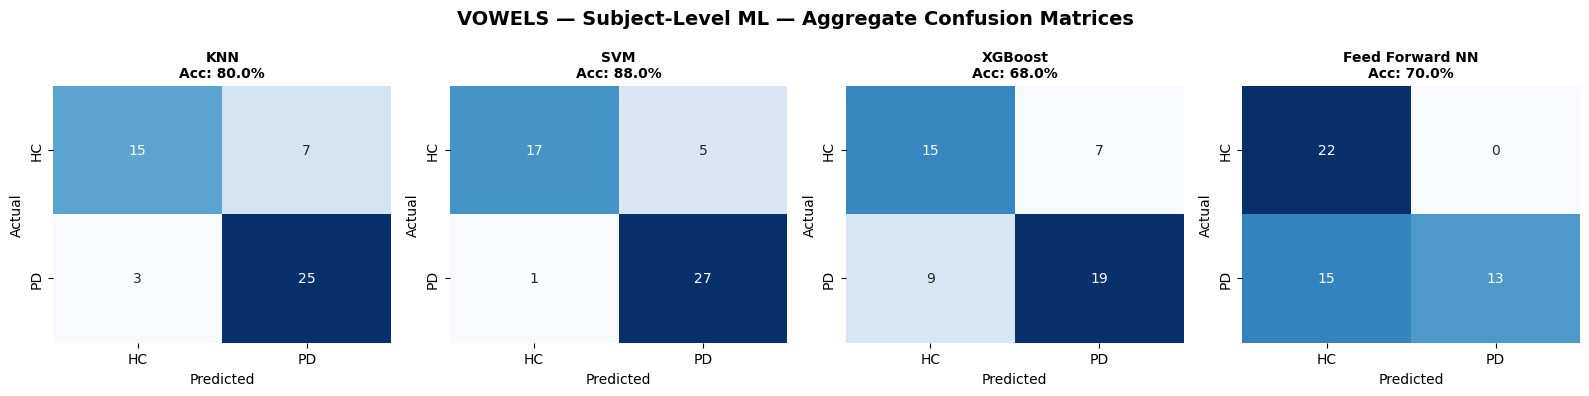

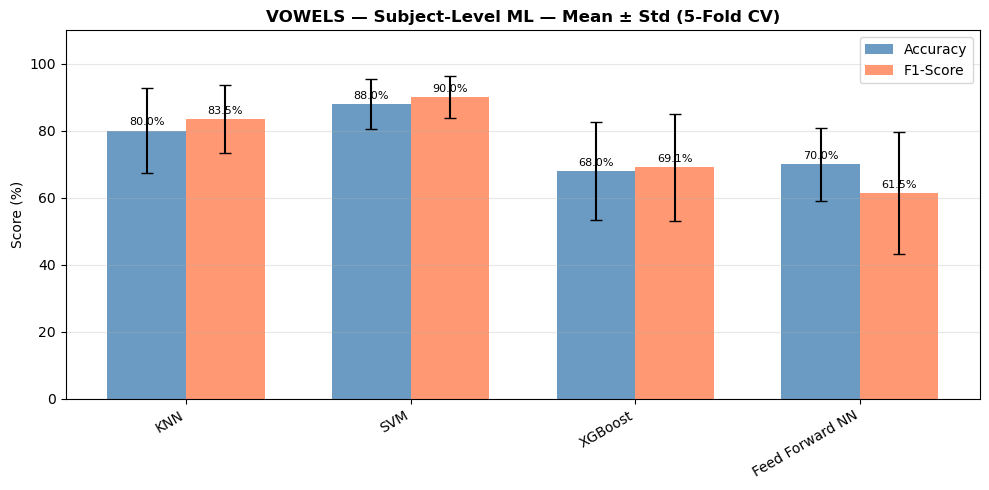


#################################################################
# EXPERIMENT: PA
# Target sounds: {'pa'}
#################################################################

Loaded 50 subjects for pa
  HC: 22  |  PD: 28  |  Features: 22
                          AGNESE P  label=0  n_files= 1  sounds=['pa']
                          ANGELA C  label=0  n_files= 1  sounds=['pa']
                          ANGELA G  label=0  n_files= 1  sounds=['pa']
                      ANTONIETTA P  label=0  n_files= 1  sounds=['pa']
                         ANTONIO C  label=0  n_files= 1  sounds=['pa']
                         BRIGIDA C  label=0  n_files= 1  sounds=['pa']
                           GILDA C  label=0  n_files= 1  sounds=['pa']
                        GIOVANNA G  label=0  n_files= 1  sounds=['pa']
                        GIOVANNI B  label=0  n_files= 1  sounds=['pa']
                          GRAZIA G  label=0  n_files= 1  sounds=['pa']
                        LEONARDA F  label=0  n_files

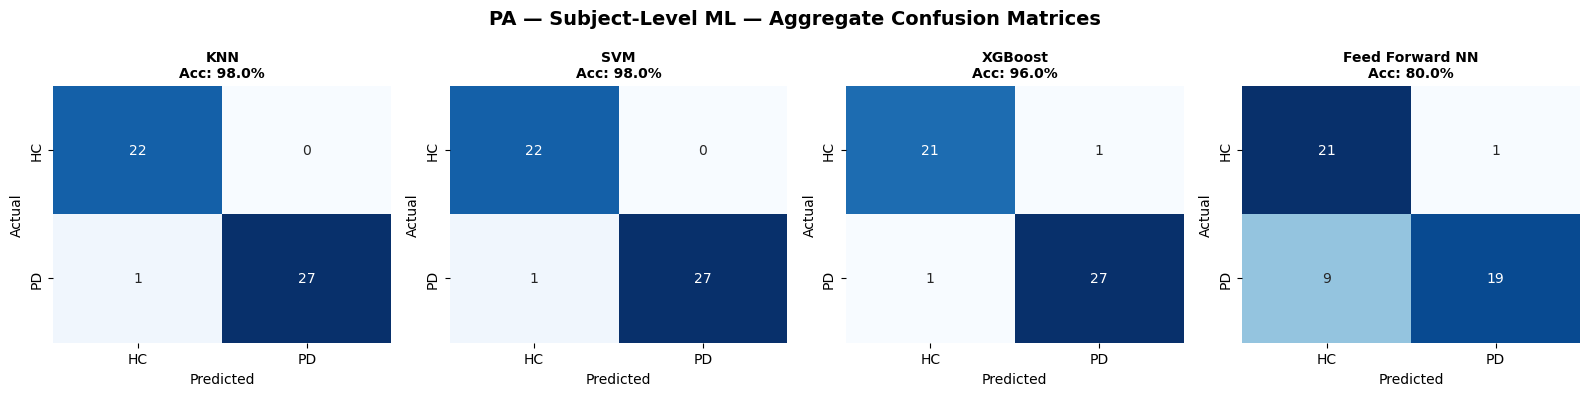

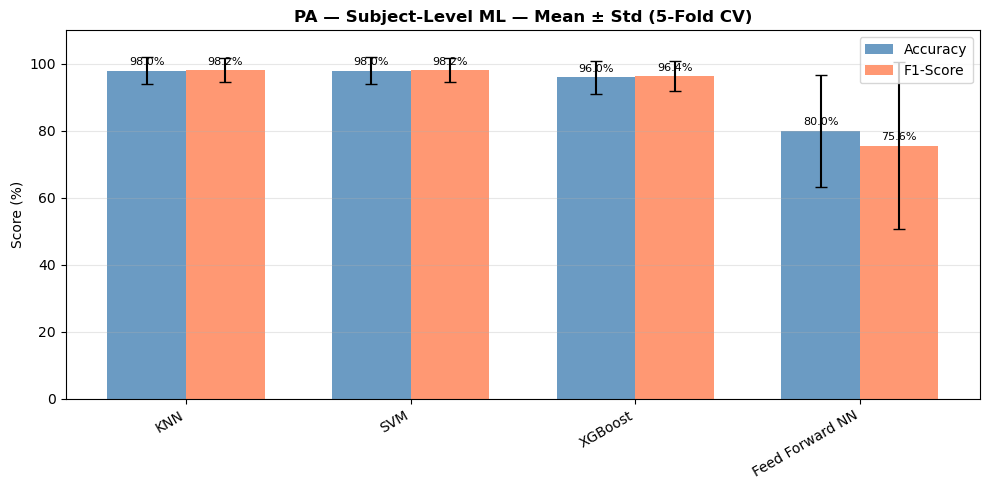


#################################################################
# EXPERIMENT: TA
# Target sounds: {'ta'}
#################################################################

Loaded 50 subjects for ta
  HC: 22  |  PD: 28  |  Features: 22
                          AGNESE P  label=0  n_files= 1  sounds=['ta']
                          ANGELA C  label=0  n_files= 1  sounds=['ta']
                          ANGELA G  label=0  n_files= 1  sounds=['ta']
                      ANTONIETTA P  label=0  n_files= 1  sounds=['ta']
                         ANTONIO C  label=0  n_files= 1  sounds=['ta']
                         BRIGIDA C  label=0  n_files= 1  sounds=['ta']
                           GILDA C  label=0  n_files= 1  sounds=['ta']
                        GIOVANNA G  label=0  n_files= 1  sounds=['ta']
                        GIOVANNI B  label=0  n_files= 1  sounds=['ta']
                          GRAZIA G  label=0  n_files= 1  sounds=['ta']
                        LEONARDA F  label=0  n_files

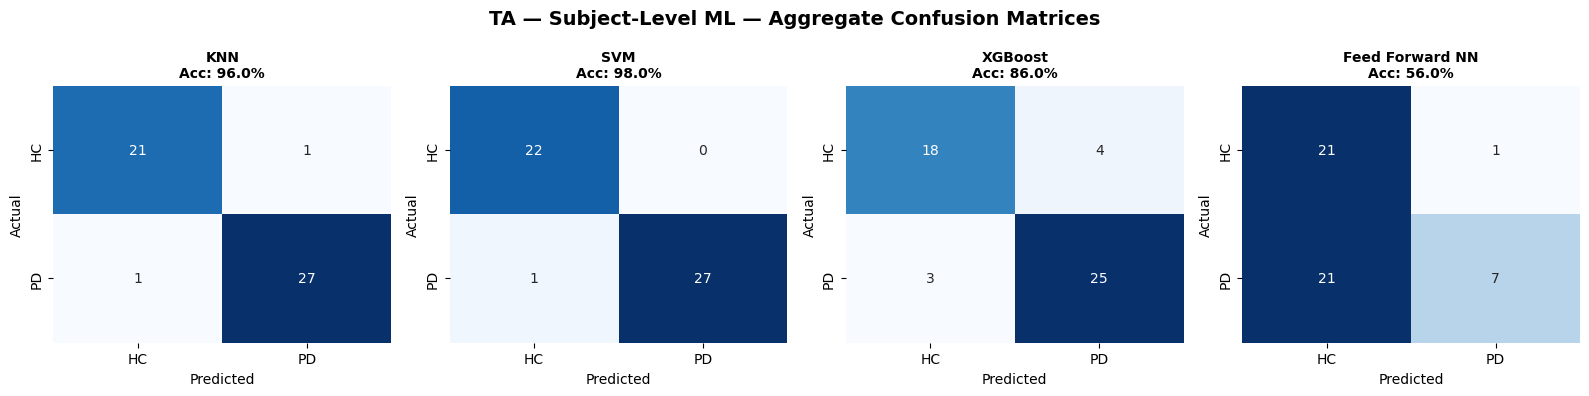

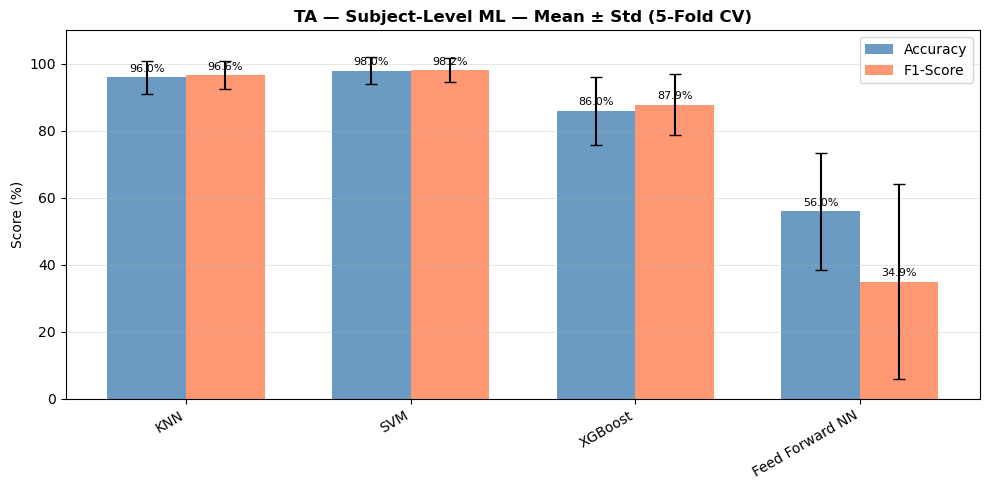



GRAND COMPARISON — Subject-Level ML Classification
  Sound      Model                  Mean Acc    Std Acc    Mean F1     Std F1
  ----------------------------------------------------------------------
  vowels     KNN                       80.0%      12.6%      83.5%      10.1%
  vowels     SVM                       88.0%       7.5%      90.0%       6.2%
  vowels     XGBoost                   68.0%      14.7%      69.1%      15.9%
  vowels     Feed Forward NN           70.0%      11.0%      61.5%      18.2%
  pa         KNN                       98.0%       4.0%      98.2%       3.6%
  pa         SVM                       98.0%       4.0%      98.2%       3.6%
  pa         XGBoost                   96.0%       4.9%      96.4%       4.5%
  pa         Feed Forward NN           80.0%      16.7%      75.6%      24.9%
  ta         KNN                       96.0%       4.9%      96.6%       4.1%
  ta         SVM                       98.0%       4.0%      98.2%       3.6%
  ta         XGB

In [2]:
# ============================================================
# Speech PD Detection — SUBJECT-LEVEL Feature-Based ML
# THREE SEPARATE EXPERIMENTS: vowels (10), pa (1), ta (1)
# Features extracted per WAV → aggregated per subject (mean)
# Models: KNN, SVM, XGBoost, Feed Forward NN
# 5-Fold CV over subjects
# ============================================================

import numpy as np
import pandas as pd
import librosa
from pathlib import Path
from collections import defaultdict
from scipy.signal import find_peaks
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
ITALIAN_PATH = r"Italian Parkinson's Voice and speech"
SAVE_DIR = Path("speech_subject_ml_models")
SAVE_DIR.mkdir(exist_ok=True)

SR = 16000
N_FOLDS = 5

SOUND_GROUPS = {
    'vowels': {'a', 'e', 'i', 'o', 'u'},
    'pa':     {'pa'},
    'ta':     {'ta'},
}

np.random.seed(42)

# ============================================================
# FEATURE EXTRACTION (same as your original)
# ============================================================
def extract_pitch(y, sr):
    f0 = librosa.yin(y, fmin=75, fmax=300, sr=sr)
    f0_voiced = f0[f0 > 0]
    if len(f0_voiced) == 0:
        return None
    return {'pitch_mean': float(np.mean(f0_voiced)), 'pitch_std': float(np.std(f0_voiced))}


def extract_jitter(y, sr):
    f0 = librosa.yin(y, fmin=75, fmax=300, sr=sr)
    f0_voiced = f0[f0 > 0]
    if len(f0_voiced) < 2:
        return None
    periods = 1.0 / f0_voiced
    period_diffs = np.abs(np.diff(periods))
    jitter = np.mean(period_diffs) / np.mean(periods) if np.mean(periods) > 0 else 0
    return {'jitter': float(jitter)}


def extract_shimmer(y, sr):
    S = np.abs(librosa.stft(y))
    amplitude = np.mean(S, axis=0)
    if len(amplitude) < 2:
        return None
    amp_diffs = np.abs(np.diff(amplitude))
    shimmer = np.mean(amp_diffs) / np.mean(amplitude) if np.mean(amplitude) > 0 else 0
    return {'shimmer': float(shimmer)}


def extract_hnr(y, sr):
    autocorr = librosa.autocorrelate(y)
    if len(autocorr) < 2:
        return None
    peaks, _ = find_peaks(autocorr[1:])
    if len(peaks) == 0:
        return {'hnr': 0.0}
    first_peak = peaks[0] + 1
    harmonic = autocorr[first_peak]
    noise = autocorr[0] - harmonic
    if noise <= 0:
        hnr = 20.0
    else:
        hnr = 10 * np.log10(harmonic / noise) if harmonic > 0 else -20.0
    return {'hnr': float(hnr)}


def extract_intensity(y, sr):
    rms = librosa.feature.rms(y=y)[0]
    if len(rms) == 0:
        return None
    intensity_db = 20 * np.log10(np.mean(rms) + 1e-10)
    return {'intensity': float(intensity_db)}


def extract_formants_lpc(y, sr, n_formants=3):
    y_emphasized = librosa.effects.preemphasis(y)
    if not np.isfinite(y_emphasized).all():
        return None
    if np.abs(y_emphasized).max() < 1e-6:
        return None
    lpc_order = int(sr / 1000) + 2
    a = librosa.lpc(y_emphasized, order=lpc_order)
    if not np.isfinite(a).all():
        return None
    roots = np.roots(a)
    roots = roots[np.abs(roots) < 1]
    angles = np.arctan2(np.imag(roots), np.real(roots))
    freqs = angles * (sr / (2 * np.pi))
    freqs = freqs[freqs > 0]
    freqs = np.sort(freqs)
    formants = {}
    for i in range(n_formants):
        formants[f'formant_{i+1}'] = float(freqs[i]) if i < len(freqs) else 0.0
    return formants


def extract_mfcc(y, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] == 0:
        return None
    mfcc_mean = np.mean(mfcc, axis=1)
    return {f'mfcc_{i+1}': float(mfcc_mean[i]) for i in range(n_mfcc)}


def extract_all_features(wav_path):
    """Extract all acoustic features from a single WAV file."""
    y, sr = librosa.load(wav_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < 1600 or not np.isfinite(y).all():
        return None

    features = {}
    extractors = [
        extract_pitch, extract_jitter, extract_shimmer,
        extract_hnr, extract_intensity, extract_formants_lpc, extract_mfcc,
    ]
    for ext in extractors:
        result = ext(y, sr)
        if result is None:
            return None
        features.update(result)

    # Reject if >30% zeros
    vals = list(features.values())
    if sum(1 for v in vals if abs(v) < 1e-10) / len(vals) > 0.3:
        return None

    return features


# ============================================================
# DATA LOADING — SUBJECT-LEVEL
# ============================================================
def get_sound_type(filename):
    f = filename.upper()
    if f.startswith('VA1') or f.startswith('VA2'): return 'a'
    if f.startswith('VE1') or f.startswith('VE2'): return 'e'
    if f.startswith('VI1') or f.startswith('VI2'): return 'i'
    if f.startswith('VO1') or f.startswith('VO2'): return 'o'
    if f.startswith('VU1') or f.startswith('VU2'): return 'u'
    if f.startswith('D1'): return 'pa'
    if f.startswith('D2'): return 'ta'
    return None


def find_subject_folders(folder_path):
    subjects = []
    for item in folder_path.iterdir():
        if not item.is_dir():
            continue
        if list(item.glob('*.wav')) + list(item.glob('*.WAV')):
            subjects.append(item)
        else:
            for sub in item.iterdir():
                if sub.is_dir() and (list(sub.glob('*.wav')) + list(sub.glob('*.WAV'))):
                    subjects.append(sub)
    return subjects


def load_subject_features(base_path, target_sounds):
    """
    Load features grouped by SUBJECT.
    For each subject, extract features from each matching WAV,
    then AVERAGE across all recordings → 1 feature vector per subject.

    Returns
    -------
    X : pd.DataFrame  — (n_subjects, n_features)
    y : np.ndarray     — (n_subjects,)
    subject_info : list[dict] — metadata per subject
    """
    base_path = Path(base_path)
    folders = {
        '15 Young Healthy Control':           0,
        '22 Elderly Healthy Control':         0,
        "28 People with Parkinson's disease": 1,
    }

    subject_data = []   # list of (name, label, group, list_of_feature_dicts, sound_tags)
    seen_dirs = set()

    for folder_name, label in folders.items():
        folder_path = base_path / folder_name
        if not folder_path.exists():
            print(f"  [WARN] Missing: {folder_path}")
            continue

        subj_dirs = find_subject_folders(folder_path)
        for subj_dir in subj_dirs:
            key = str(subj_dir.resolve())
            if key in seen_dirs:
                continue
            seen_dirs.add(key)

            wavs = list(subj_dir.glob('*.wav')) + list(subj_dir.glob('*.WAV'))

            feat_list = []
            tags = []
            processed_files = set()

            for wav in wavs:
                wav_key = str(wav.resolve())
                if wav_key in processed_files:
                    continue
                processed_files.add(wav_key)

                sound = get_sound_type(wav.name)
                if sound not in target_sounds:
                    continue

                feats = extract_all_features(str(wav))
                if feats is not None:
                    feat_list.append(feats)
                    tags.append(sound)

            if len(feat_list) == 0:
                continue

            subject_data.append({
                'name':       subj_dir.name,
                'label':      label,
                'group':      folder_name,
                'feat_list':  feat_list,
                'sound_tags': tags,
                'n_files':    len(feat_list),
            })

    # Aggregate: mean across all recordings per subject
    all_rows = []
    all_labels = []
    all_info = []

    for subj in subject_data:
        df_temp = pd.DataFrame(subj['feat_list'])
        mean_features = df_temp.mean().to_dict()

        all_rows.append(mean_features)
        all_labels.append(subj['label'])
        all_info.append({
            'name':       subj['name'],
            'label':      subj['label'],
            'group':      subj['group'],
            'n_files':    subj['n_files'],
            'sound_tags': subj['sound_tags'],
        })

    X = pd.DataFrame(all_rows)
    y = np.array(all_labels)

    return X, y, all_info


# ============================================================
# 5-FOLD CV — SUBJECT-LEVEL ML
# ============================================================
def run_subject_cv(X, y, subject_info, sound_group):
    """
    5-Fold Stratified CV over subjects for 4 ML models.
    """
    print(f"\n{'='*65}")
    print(f"Subject-Level ML — {sound_group.upper()} — 5-Fold CV")
    print(f"  Subjects: {len(y)} (HC={sum(y==0)}, PD={sum(y==1)})")
    print(f"  Features: {X.shape[1]}")
    print(f"{'='*65}")

    # Clean data
    X_clean = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(X.median())

    models_cfg = {
        'KNN':             lambda: KNeighborsClassifier(n_neighbors=5),
        'SVM':             lambda: SVC(kernel='rbf', C=1.0, random_state=42),
        'XGBoost':         lambda: XGBClassifier(n_estimators=100, max_depth=5,
                                                  learning_rate=0.1, random_state=42,
                                                  eval_metric='logloss'),
        'Feed Forward NN': lambda: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                                  random_state=42, early_stopping=True),
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    # Store results: model_name → list of fold dicts
    model_results = {name: [] for name in models_cfg}
    # Store predictions for confusion matrices
    model_all_preds  = {name: [] for name in models_cfg}
    model_all_labels = {name: [] for name in models_cfg}

    X_np = X_clean.values

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y)):
        print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        n_tr_hc = sum(y_train == 0)
        n_tr_pd = sum(y_train == 1)
        n_va_hc = sum(y_val == 0)
        n_va_pd = sum(y_val == 1)
        print(f"  Train: {len(y_train)} (HC={n_tr_hc}, PD={n_tr_pd})")
        print(f"  Val:   {len(y_val)} (HC={n_va_hc}, PD={n_va_pd})")

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc   = scaler.transform(X_val)

        for name, make_model in models_cfg.items():
            model = make_model()
            model.fit(X_train_sc, y_train)
            y_pred = model.predict(X_val_sc)

            acc  = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, zero_division=0)
            rec  = recall_score(y_val, y_pred, zero_division=0)
            f1   = f1_score(y_val, y_pred, zero_division=0)

            model_results[name].append({
                'fold': fold + 1, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1
            })
            model_all_preds[name].extend(y_pred)
            model_all_labels[name].extend(y_val)

        # Print fold summary
        print(f"\n  {'Model':<20} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
        print(f"  {'-'*52}")
        for name in models_cfg:
            m = model_results[name][-1]
            print(f"  {name:<20} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
                  f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")

    return model_results, model_all_preds, model_all_labels


# ============================================================
# VISUALIZATION
# ============================================================
def print_model_summary(model_results, sound_group):
    print(f"\n{'='*65}")
    print(f"SUMMARY — {sound_group.upper()} — Subject-Level ML")
    print(f"{'='*65}")

    for name, fold_results in model_results.items():
        accs = [r['acc'] for r in fold_results]
        f1s  = [r['f1']  for r in fold_results]
        precs = [r['prec'] for r in fold_results]
        recs  = [r['rec'] for r in fold_results]

        print(f"\n  {name}")
        print(f"    {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
        print(f"    {'-'*44}")
        for r in fold_results:
            print(f"    {r['fold']:<6} {r['acc']*100:>7.1f}% {r['prec']*100:>7.1f}% "
                  f"{r['rec']*100:>7.1f}% {r['f1']*100:>7.1f}%")
        print(f"    {'-'*44}")
        print(f"    {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(precs)*100:>7.1f}% "
              f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
        print(f"    {'Std':<6} {np.std(accs)*100:>7.1f}% {np.std(precs)*100:>7.1f}% "
              f"{np.std(recs)*100:>7.1f}% {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(model_all_preds, model_all_labels, sound_group):
    """Plot aggregate confusion matrices for all models."""
    model_names = list(model_all_preds.keys())
    n_models = len(model_names)

    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    if n_models == 1:
        axes = [axes]
    fig.suptitle(f'{sound_group.upper()} — Subject-Level ML — Aggregate Confusion Matrices',
                 fontsize=14, fontweight='bold')

    for ax, name in zip(axes, model_names):
        preds  = np.array(model_all_preds[name])
        labels = np.array(model_all_labels[name])
        cm = confusion_matrix(labels, preds)
        acc = accuracy_score(labels, preds)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        ax.set_title(f'{name}\nAcc: {acc*100:.1f}%', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{sound_group}_ml_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_comparison_bars(model_results, sound_group):
    """Bar chart comparing models on mean Acc and F1."""
    names = list(model_results.keys())
    mean_accs = [np.mean([r['acc'] for r in model_results[n]]) * 100 for n in names]
    std_accs  = [np.std([r['acc'] for r in model_results[n]]) * 100 for n in names]
    mean_f1s  = [np.mean([r['f1'] for r in model_results[n]]) * 100 for n in names]
    std_f1s   = [np.std([r['f1'] for r in model_results[n]]) * 100 for n in names]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, mean_accs, width, yerr=std_accs,
                   label='Accuracy', color='steelblue', alpha=0.8, capsize=4)
    bars2 = ax.bar(x + width/2, mean_f1s, width, yerr=std_f1s,
                   label='F1-Score', color='coral', alpha=0.8, capsize=4)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_title(f'{sound_group.upper()} — Subject-Level ML — Mean ± Std (5-Fold CV)',
                 fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{sound_group}_ml_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# MAIN — 3 EXPERIMENTS × 4 ML MODELS
# ============================================================
if __name__ == '__main__':

    grand_table = []

    for sg_name, sg_sounds in SOUND_GROUPS.items():
        print(f"\n{'#'*65}")
        print(f"# EXPERIMENT: {sg_name.upper()}")
        print(f"# Target sounds: {sg_sounds}")
        print(f"{'#'*65}")

        X, y, info = load_subject_features(ITALIAN_PATH, sg_sounds)

        print(f"\nLoaded {len(y)} subjects for {sg_name}")
        print(f"  HC: {sum(y==0)}  |  PD: {sum(y==1)}  |  Features: {X.shape[1]}")
        for s in info:
            print(f"    {s['name']:>30s}  label={s['label']}  "
                  f"n_files={s['n_files']:2d}  sounds={s['sound_tags']}")

        model_results, model_preds, model_labels = run_subject_cv(X, y, info, sg_name)

        print_model_summary(model_results, sg_name)
        plot_confusion_matrices(model_preds, model_labels, sg_name)
        plot_comparison_bars(model_results, sg_name)

        # Collect for grand table
        for name, fold_results in model_results.items():
            accs = [r['acc'] for r in fold_results]
            f1s  = [r['f1']  for r in fold_results]
            grand_table.append({
                'Sound':    sg_name,
                'Model':    name,
                'Mean Acc':  np.mean(accs) * 100,
                'Std Acc':   np.std(accs) * 100,
                'Mean F1':   np.mean(f1s) * 100,
                'Std F1':    np.std(f1s) * 100,
            })

    # ============================================================
    # GRAND COMPARISON
    # ============================================================
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON — Subject-Level ML Classification")
    print(f"{'='*75}")
    print(f"  {'Sound':<10} {'Model':<20} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*70}")

    for row in grand_table:
        print(f"  {row['Sound']:<10} {row['Model']:<20} "
              f"{row['Mean Acc']:>9.1f}% {row['Std Acc']:>9.1f}% "
              f"{row['Mean F1']:>9.1f}% {row['Std F1']:>9.1f}%")

    # Save grand table
    gt_df = pd.DataFrame(grand_table)
    gt_df.to_csv(SAVE_DIR / 'grand_comparison_ml.csv', index=False)
    print(f"\nSaved grand comparison to {SAVE_DIR / 'grand_comparison_ml.csv'}")


#################################################################
# EXPERIMENT: VOWELS
# Target sounds: {'u', 'e', 'i', 'o', 'a'}
#################################################################

Loaded 50 subjects for vowels
  HC: 22  |  PD: 28  |  Features: 22
                          AGNESE P  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                          ANGELA C  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                          ANGELA G  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                      ANTONIETTA P  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                         ANTONIO C  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                         BRIGIDA C  label=0  n_files=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                           GILDA C  label=0  

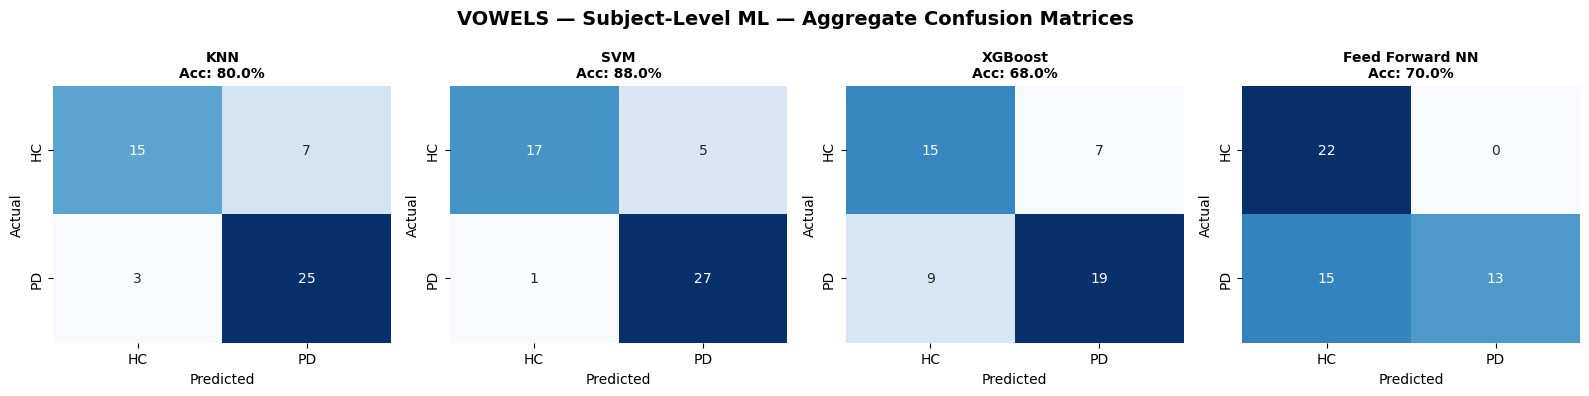

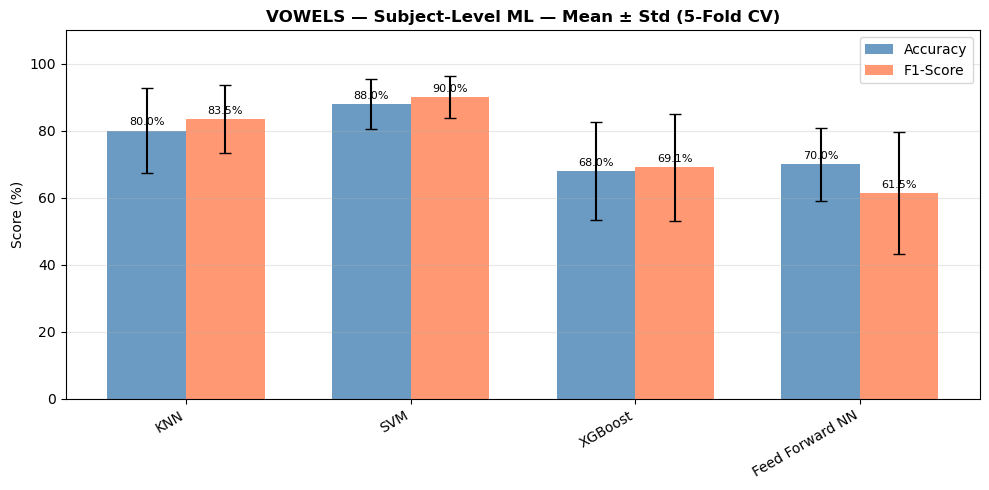


#################################################################
# EXPERIMENT: PA
# Target sounds: {'pa'}
#################################################################

Loaded 50 subjects for pa
  HC: 22  |  PD: 28  |  Features: 22
                          AGNESE P  label=0  n_files= 1  sounds=['pa']
                          ANGELA C  label=0  n_files= 1  sounds=['pa']
                          ANGELA G  label=0  n_files= 1  sounds=['pa']
                      ANTONIETTA P  label=0  n_files= 1  sounds=['pa']
                         ANTONIO C  label=0  n_files= 1  sounds=['pa']
                         BRIGIDA C  label=0  n_files= 1  sounds=['pa']
                           GILDA C  label=0  n_files= 1  sounds=['pa']
                        GIOVANNA G  label=0  n_files= 1  sounds=['pa']
                        GIOVANNI B  label=0  n_files= 1  sounds=['pa']
                          GRAZIA G  label=0  n_files= 1  sounds=['pa']
                        LEONARDA F  label=0  n_files

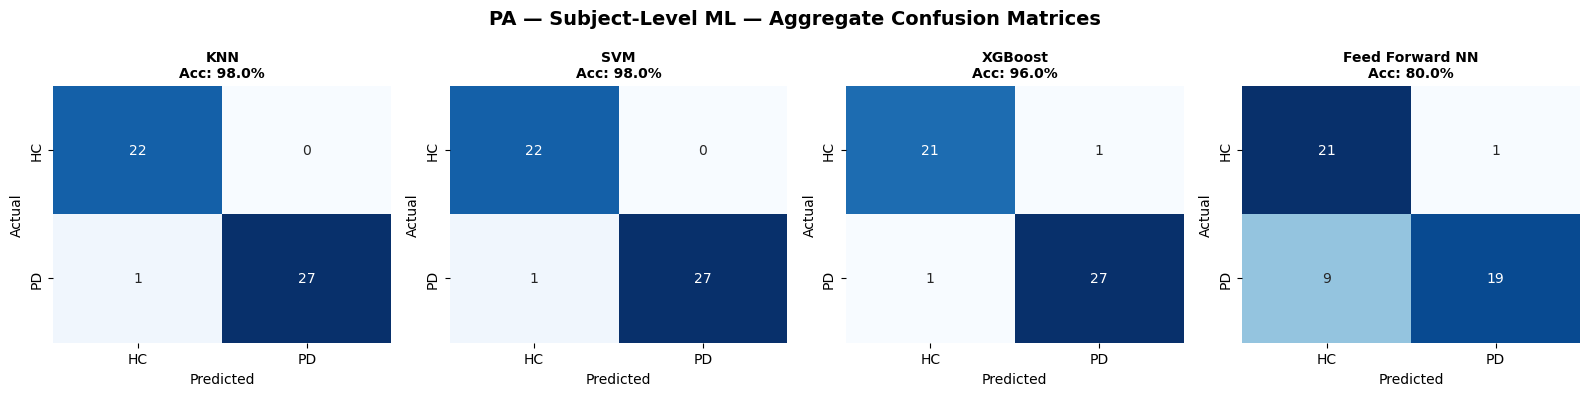

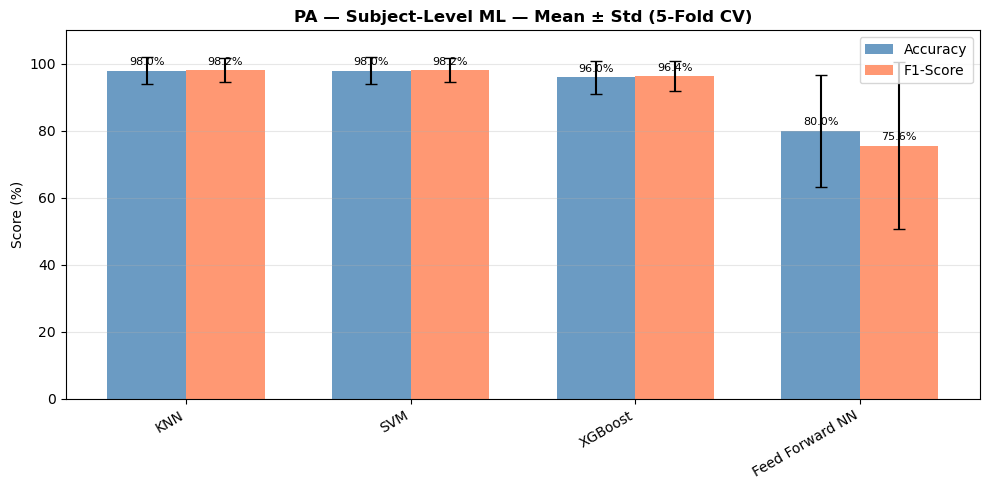


#################################################################
# EXPERIMENT: TA
# Target sounds: {'ta'}
#################################################################

Loaded 50 subjects for ta
  HC: 22  |  PD: 28  |  Features: 22
                          AGNESE P  label=0  n_files= 1  sounds=['ta']
                          ANGELA C  label=0  n_files= 1  sounds=['ta']
                          ANGELA G  label=0  n_files= 1  sounds=['ta']
                      ANTONIETTA P  label=0  n_files= 1  sounds=['ta']
                         ANTONIO C  label=0  n_files= 1  sounds=['ta']
                         BRIGIDA C  label=0  n_files= 1  sounds=['ta']
                           GILDA C  label=0  n_files= 1  sounds=['ta']
                        GIOVANNA G  label=0  n_files= 1  sounds=['ta']
                        GIOVANNI B  label=0  n_files= 1  sounds=['ta']
                          GRAZIA G  label=0  n_files= 1  sounds=['ta']
                        LEONARDA F  label=0  n_files

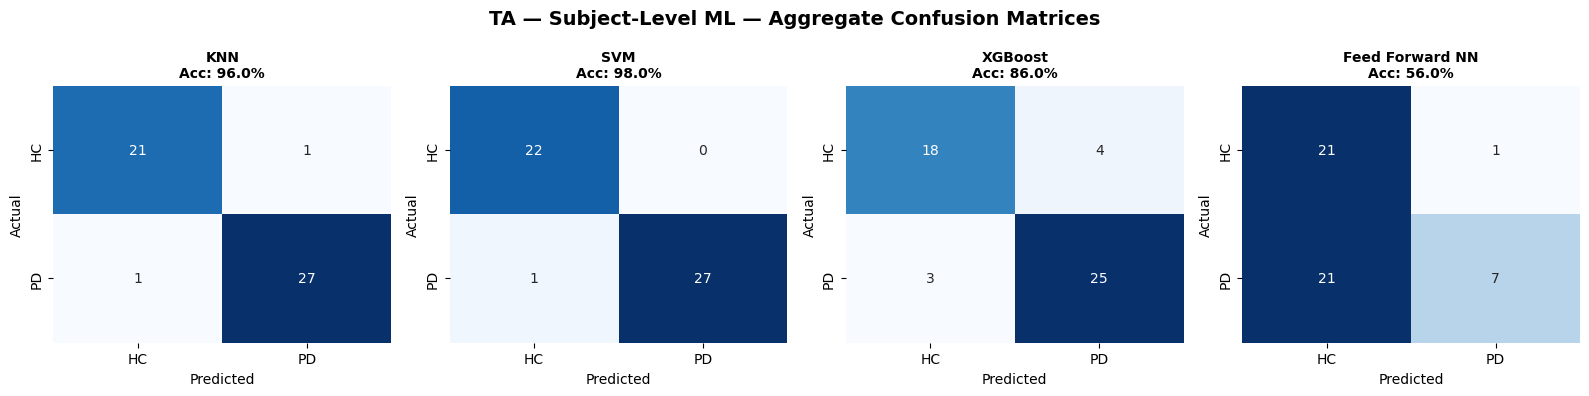

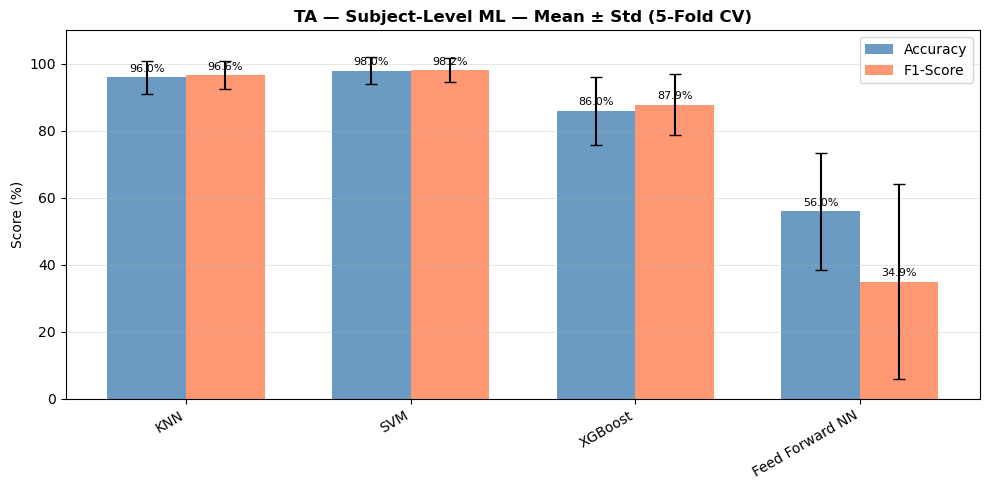



GRAND COMPARISON — Subject-Level ML Classification
  Sound      Model                  Mean Acc    Std Acc    Mean F1     Std F1
  ----------------------------------------------------------------------
  vowels     KNN                       80.0%      12.6%      83.5%      10.1%
  vowels     SVM                       88.0%       7.5%      90.0%       6.2%
  vowels     XGBoost                   68.0%      14.7%      69.1%      15.9%
  vowels     Feed Forward NN           70.0%      11.0%      61.5%      18.2%
  pa         KNN                       98.0%       4.0%      98.2%       3.6%
  pa         SVM                       98.0%       4.0%      98.2%       3.6%
  pa         XGBoost                   96.0%       4.9%      96.4%       4.5%
  pa         Feed Forward NN           80.0%      16.7%      75.6%      24.9%
  ta         KNN                       96.0%       4.9%      96.6%       4.1%
  ta         SVM                       98.0%       4.0%      98.2%       3.6%
  ta         XGB

In [1]:
# ============================================================
# Speech PD Detection — SUBJECT-LEVEL Feature-Based ML
# THREE SEPARATE EXPERIMENTS: vowels (10), pa (1), ta (1)
# Features extracted per WAV → aggregated per subject (mean)
# Models: KNN, SVM, XGBoost, Feed Forward NN
# 5-Fold CV over subjects
# ============================================================

import numpy as np
import pandas as pd
import librosa
from pathlib import Path
from collections import defaultdict
from scipy.signal import find_peaks
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
ITALIAN_PATH = r"Italian Parkinson's Voice and speech"
SAVE_DIR = Path("speech_subject_ml_models")
SAVE_DIR.mkdir(exist_ok=True)

SR = 16000
N_FOLDS = 5

SOUND_GROUPS = {
    'vowels': {'a', 'e', 'i', 'o', 'u'},
    'pa':     {'pa'},
    'ta':     {'ta'},
}

np.random.seed(42)

# ============================================================
# FEATURE EXTRACTION (same as your original)
# ============================================================
def extract_pitch(y, sr):
    f0 = librosa.yin(y, fmin=75, fmax=300, sr=sr)
    f0_voiced = f0[f0 > 0]
    if len(f0_voiced) == 0:
        return None
    return {'pitch_mean': float(np.mean(f0_voiced)), 'pitch_std': float(np.std(f0_voiced))}


def extract_jitter(y, sr):
    f0 = librosa.yin(y, fmin=75, fmax=300, sr=sr)
    f0_voiced = f0[f0 > 0]
    if len(f0_voiced) < 2:
        return None
    periods = 1.0 / f0_voiced
    period_diffs = np.abs(np.diff(periods))
    jitter = np.mean(period_diffs) / np.mean(periods) if np.mean(periods) > 0 else 0
    return {'jitter': float(jitter)}


def extract_shimmer(y, sr):
    S = np.abs(librosa.stft(y))
    amplitude = np.mean(S, axis=0)
    if len(amplitude) < 2:
        return None
    amp_diffs = np.abs(np.diff(amplitude))
    shimmer = np.mean(amp_diffs) / np.mean(amplitude) if np.mean(amplitude) > 0 else 0
    return {'shimmer': float(shimmer)}


def extract_hnr(y, sr):
    autocorr = librosa.autocorrelate(y)
    if len(autocorr) < 2:
        return None
    peaks, _ = find_peaks(autocorr[1:])
    if len(peaks) == 0:
        return {'hnr': 0.0}
    first_peak = peaks[0] + 1
    harmonic = autocorr[first_peak]
    noise = autocorr[0] - harmonic
    if noise <= 0:
        hnr = 20.0
    else:
        hnr = 10 * np.log10(harmonic / noise) if harmonic > 0 else -20.0
    return {'hnr': float(hnr)}


def extract_intensity(y, sr):
    rms = librosa.feature.rms(y=y)[0]
    if len(rms) == 0:
        return None
    intensity_db = 20 * np.log10(np.mean(rms) + 1e-10)
    return {'intensity': float(intensity_db)}


def extract_formants_lpc(y, sr, n_formants=3):
    y_emphasized = librosa.effects.preemphasis(y)
    if not np.isfinite(y_emphasized).all():
        return None
    if np.abs(y_emphasized).max() < 1e-6:
        return None
    lpc_order = int(sr / 1000) + 2
    a = librosa.lpc(y_emphasized, order=lpc_order)
    if not np.isfinite(a).all():
        return None
    roots = np.roots(a)
    roots = roots[np.abs(roots) < 1]
    angles = np.arctan2(np.imag(roots), np.real(roots))
    freqs = angles * (sr / (2 * np.pi))
    freqs = freqs[freqs > 0]
    freqs = np.sort(freqs)
    formants = {}
    for i in range(n_formants):
        formants[f'formant_{i+1}'] = float(freqs[i]) if i < len(freqs) else 0.0
    return formants


def extract_mfcc(y, sr, n_mfcc=13):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] == 0:
        return None
    mfcc_mean = np.mean(mfcc, axis=1)
    return {f'mfcc_{i+1}': float(mfcc_mean[i]) for i in range(n_mfcc)}


def extract_all_features(wav_path):
    """Extract all acoustic features from a single WAV file."""
    y, sr = librosa.load(wav_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=20)

    if len(y) < 1600 or not np.isfinite(y).all():
        return None

    features = {}
    extractors = [
        extract_pitch, extract_jitter, extract_shimmer,
        extract_hnr, extract_intensity, extract_formants_lpc, extract_mfcc,
    ]
    for ext in extractors:
        result = ext(y, sr)
        if result is None:
            return None
        features.update(result)

    # Reject if >30% zeros
    vals = list(features.values())
    if sum(1 for v in vals if abs(v) < 1e-10) / len(vals) > 0.3:
        return None

    return features


# ============================================================
# DATA LOADING — SUBJECT-LEVEL
# ============================================================
def get_sound_type(filename):
    f = filename.upper()
    if f.startswith('VA1') or f.startswith('VA2'): return 'a'
    if f.startswith('VE1') or f.startswith('VE2'): return 'e'
    if f.startswith('VI1') or f.startswith('VI2'): return 'i'
    if f.startswith('VO1') or f.startswith('VO2'): return 'o'
    if f.startswith('VU1') or f.startswith('VU2'): return 'u'
    if f.startswith('D1'): return 'pa'
    if f.startswith('D2'): return 'ta'
    return None


def find_subject_folders(folder_path):
    subjects = []
    for item in folder_path.iterdir():
        if not item.is_dir():
            continue
        if list(item.glob('*.wav')) + list(item.glob('*.WAV')):
            subjects.append(item)
        else:
            for sub in item.iterdir():
                if sub.is_dir() and (list(sub.glob('*.wav')) + list(sub.glob('*.WAV'))):
                    subjects.append(sub)
    return subjects


def load_subject_features(base_path, target_sounds):
    """
    Load features grouped by SUBJECT.
    For each subject, extract features from each matching WAV,
    then AVERAGE across all recordings → 1 feature vector per subject.

    Returns
    -------
    X : pd.DataFrame  — (n_subjects, n_features)
    y : np.ndarray     — (n_subjects,)
    subject_info : list[dict] — metadata per subject
    """
    base_path = Path(base_path)
    folders = {
        '15 Young Healthy Control':           0,
        '22 Elderly Healthy Control':         0,
        "28 People with Parkinson's disease": 1,
    }

    subject_data = []   # list of (name, label, group, list_of_feature_dicts, sound_tags)
    seen_dirs = set()

    for folder_name, label in folders.items():
        folder_path = base_path / folder_name
        if not folder_path.exists():
            print(f"  [WARN] Missing: {folder_path}")
            continue

        subj_dirs = find_subject_folders(folder_path)
        for subj_dir in subj_dirs:
            key = str(subj_dir.resolve())
            if key in seen_dirs:
                continue
            seen_dirs.add(key)

            wavs = list(subj_dir.glob('*.wav')) + list(subj_dir.glob('*.WAV'))

            feat_list = []
            tags = []
            processed_files = set()

            for wav in wavs:
                wav_key = str(wav.resolve())
                if wav_key in processed_files:
                    continue
                processed_files.add(wav_key)

                sound = get_sound_type(wav.name)
                if sound not in target_sounds:
                    continue

                feats = extract_all_features(str(wav))
                if feats is not None:
                    feat_list.append(feats)
                    tags.append(sound)

            if len(feat_list) == 0:
                continue

            subject_data.append({
                'name':       subj_dir.name,
                'label':      label,
                'group':      folder_name,
                'feat_list':  feat_list,
                'sound_tags': tags,
                'n_files':    len(feat_list),
            })

    # Aggregate: mean across all recordings per subject
    all_rows = []
    all_labels = []
    all_info = []

    for subj in subject_data:
        df_temp = pd.DataFrame(subj['feat_list'])
        mean_features = df_temp.mean().to_dict()

        all_rows.append(mean_features)
        all_labels.append(subj['label'])
        all_info.append({
            'name':       subj['name'],
            'label':      subj['label'],
            'group':      subj['group'],
            'n_files':    subj['n_files'],
            'sound_tags': subj['sound_tags'],
        })

    X = pd.DataFrame(all_rows)
    y = np.array(all_labels)

    return X, y, all_info


# ============================================================
# 5-FOLD CV — SUBJECT-LEVEL ML
# ============================================================
def run_subject_cv(X, y, subject_info, sound_group):
    """
    5-Fold Stratified CV over subjects for 4 ML models.
    """
    print(f"\n{'='*65}")
    print(f"Subject-Level ML — {sound_group.upper()} — 5-Fold CV")
    print(f"  Subjects: {len(y)} (HC={sum(y==0)}, PD={sum(y==1)})")
    print(f"  Features: {X.shape[1]}")
    print(f"{'='*65}")

    # Clean data
    X_clean = X.fillna(X.median()).replace([np.inf, -np.inf], np.nan).fillna(X.median())

    models_cfg = {
        'KNN':             lambda: KNeighborsClassifier(n_neighbors=5),
        'SVM':             lambda: SVC(kernel='rbf', C=1.0, random_state=42),
        'XGBoost':         lambda: XGBClassifier(n_estimators=100, max_depth=5,
                                                  learning_rate=0.1, random_state=42,
                                                  eval_metric='logloss'),
        'Feed Forward NN': lambda: MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                                  random_state=42, early_stopping=True),
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    # Store results: model_name → list of fold dicts
    model_results = {name: [] for name in models_cfg}
    # Store predictions for confusion matrices
    model_all_preds  = {name: [] for name in models_cfg}
    model_all_labels = {name: [] for name in models_cfg}

    X_np = X_clean.values

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y)):
        print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        n_tr_hc = sum(y_train == 0)
        n_tr_pd = sum(y_train == 1)
        n_va_hc = sum(y_val == 0)
        n_va_pd = sum(y_val == 1)
        print(f"  Train: {len(y_train)} (HC={n_tr_hc}, PD={n_tr_pd})")
        print(f"  Val:   {len(y_val)} (HC={n_va_hc}, PD={n_va_pd})")

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_val_sc   = scaler.transform(X_val)

        for name, make_model in models_cfg.items():
            model = make_model()
            model.fit(X_train_sc, y_train)
            y_pred = model.predict(X_val_sc)

            acc  = accuracy_score(y_val, y_pred)
            prec = precision_score(y_val, y_pred, zero_division=0)
            rec  = recall_score(y_val, y_pred, zero_division=0)
            f1   = f1_score(y_val, y_pred, zero_division=0)

            model_results[name].append({
                'fold': fold + 1, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1
            })
            model_all_preds[name].extend(y_pred)
            model_all_labels[name].extend(y_val)

        # Print fold summary
        print(f"\n  {'Model':<20} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
        print(f"  {'-'*52}")
        for name in models_cfg:
            m = model_results[name][-1]
            print(f"  {name:<20} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
                  f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")

    return model_results, model_all_preds, model_all_labels


# ============================================================
# VISUALIZATION
# ============================================================
def print_model_summary(model_results, sound_group):
    print(f"\n{'='*65}")
    print(f"SUMMARY — {sound_group.upper()} — Subject-Level ML")
    print(f"{'='*65}")

    for name, fold_results in model_results.items():
        accs = [r['acc'] for r in fold_results]
        f1s  = [r['f1']  for r in fold_results]
        precs = [r['prec'] for r in fold_results]
        recs  = [r['rec'] for r in fold_results]

        print(f"\n  {name}")
        print(f"    {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
        print(f"    {'-'*44}")
        for r in fold_results:
            print(f"    {r['fold']:<6} {r['acc']*100:>7.1f}% {r['prec']*100:>7.1f}% "
                  f"{r['rec']*100:>7.1f}% {r['f1']*100:>7.1f}%")
        print(f"    {'-'*44}")
        print(f"    {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(precs)*100:>7.1f}% "
              f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
        print(f"    {'Std':<6} {np.std(accs)*100:>7.1f}% {np.std(precs)*100:>7.1f}% "
              f"{np.std(recs)*100:>7.1f}% {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(model_all_preds, model_all_labels, sound_group):
    """Plot aggregate confusion matrices for all models."""
    model_names = list(model_all_preds.keys())
    n_models = len(model_names)

    fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
    if n_models == 1:
        axes = [axes]
    fig.suptitle(f'{sound_group.upper()} — Subject-Level ML — Aggregate Confusion Matrices',
                 fontsize=14, fontweight='bold')

    for ax, name in zip(axes, model_names):
        preds  = np.array(model_all_preds[name])
        labels = np.array(model_all_labels[name])
        cm = confusion_matrix(labels, preds)
        acc = accuracy_score(labels, preds)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        ax.set_title(f'{name}\nAcc: {acc*100:.1f}%', fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{sound_group}_ml_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_comparison_bars(model_results, sound_group):
    """Bar chart comparing models on mean Acc and F1."""
    names = list(model_results.keys())
    mean_accs = [np.mean([r['acc'] for r in model_results[n]]) * 100 for n in names]
    std_accs  = [np.std([r['acc'] for r in model_results[n]]) * 100 for n in names]
    mean_f1s  = [np.mean([r['f1'] for r in model_results[n]]) * 100 for n in names]
    std_f1s   = [np.std([r['f1'] for r in model_results[n]]) * 100 for n in names]

    x = np.arange(len(names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, mean_accs, width, yerr=std_accs,
                   label='Accuracy', color='steelblue', alpha=0.8, capsize=4)
    bars2 = ax.bar(x + width/2, mean_f1s, width, yerr=std_f1s,
                   label='F1-Score', color='coral', alpha=0.8, capsize=4)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=30, ha='right')
    ax.set_ylabel('Score (%)')
    ax.set_title(f'{sound_group.upper()} — Subject-Level ML — Mean ± Std (5-Fold CV)',
                 fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    for bars in [bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{sound_group}_ml_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# MAIN — 3 EXPERIMENTS × 4 ML MODELS
# ============================================================
if __name__ == '__main__':

    grand_table = []

    for sg_name, sg_sounds in SOUND_GROUPS.items():
        print(f"\n{'#'*65}")
        print(f"# EXPERIMENT: {sg_name.upper()}")
        print(f"# Target sounds: {sg_sounds}")
        print(f"{'#'*65}")

        X, y, info = load_subject_features(ITALIAN_PATH, sg_sounds)

        print(f"\nLoaded {len(y)} subjects for {sg_name}")
        print(f"  HC: {sum(y==0)}  |  PD: {sum(y==1)}  |  Features: {X.shape[1]}")
        for s in info:
            print(f"    {s['name']:>30s}  label={s['label']}  "
                  f"n_files={s['n_files']:2d}  sounds={s['sound_tags']}")

        model_results, model_preds, model_labels = run_subject_cv(X, y, info, sg_name)

        print_model_summary(model_results, sg_name)
        plot_confusion_matrices(model_preds, model_labels, sg_name)
        plot_comparison_bars(model_results, sg_name)

        # Collect for grand table
        for name, fold_results in model_results.items():
            accs = [r['acc'] for r in fold_results]
            f1s  = [r['f1']  for r in fold_results]
            grand_table.append({
                'Sound':    sg_name,
                'Model':    name,
                'Mean Acc':  np.mean(accs) * 100,
                'Std Acc':   np.std(accs) * 100,
                'Mean F1':   np.mean(f1s) * 100,
                'Std F1':    np.std(f1s) * 100,
            })

    # ============================================================
    # GRAND COMPARISON
    # ============================================================
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON — Subject-Level ML Classification")
    print(f"{'='*75}")
    print(f"  {'Sound':<10} {'Model':<20} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*70}")

    for row in grand_table:
        print(f"  {row['Sound']:<10} {row['Model']:<20} "
              f"{row['Mean Acc']:>9.1f}% {row['Std Acc']:>9.1f}% "
              f"{row['Mean F1']:>9.1f}% {row['Std F1']:>9.1f}%")

    # Save grand table
    gt_df = pd.DataFrame(grand_table)
    gt_df.to_csv(SAVE_DIR / 'grand_comparison_ml.csv', index=False)
    print(f"\nSaved grand comparison to {SAVE_DIR / 'grand_comparison_ml.csv'}")

### Subject Level Model

Device: cpu

#################################################################
# EXPERIMENT: VOWELS
# Target sounds: {'o', 'e', 'i', 'a', 'u'}
# Required specs per subject: 10
#################################################################

Included: 49 subjects (HC=22, PD=27)
                          AGNESE P  label=0  n_specs=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                          ANGELA C  label=0  n_specs=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                          ANGELA G  label=0  n_specs=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                      ANTONIETTA P  label=0  n_specs=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                         ANTONIO C  label=0  n_specs=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                         BRIGIDA C  label=0  n_specs=10  sounds=['a', 'a', 'e', 'e', 'i', 'i', 'o', 'o', 'u', 'u']
                           GIL

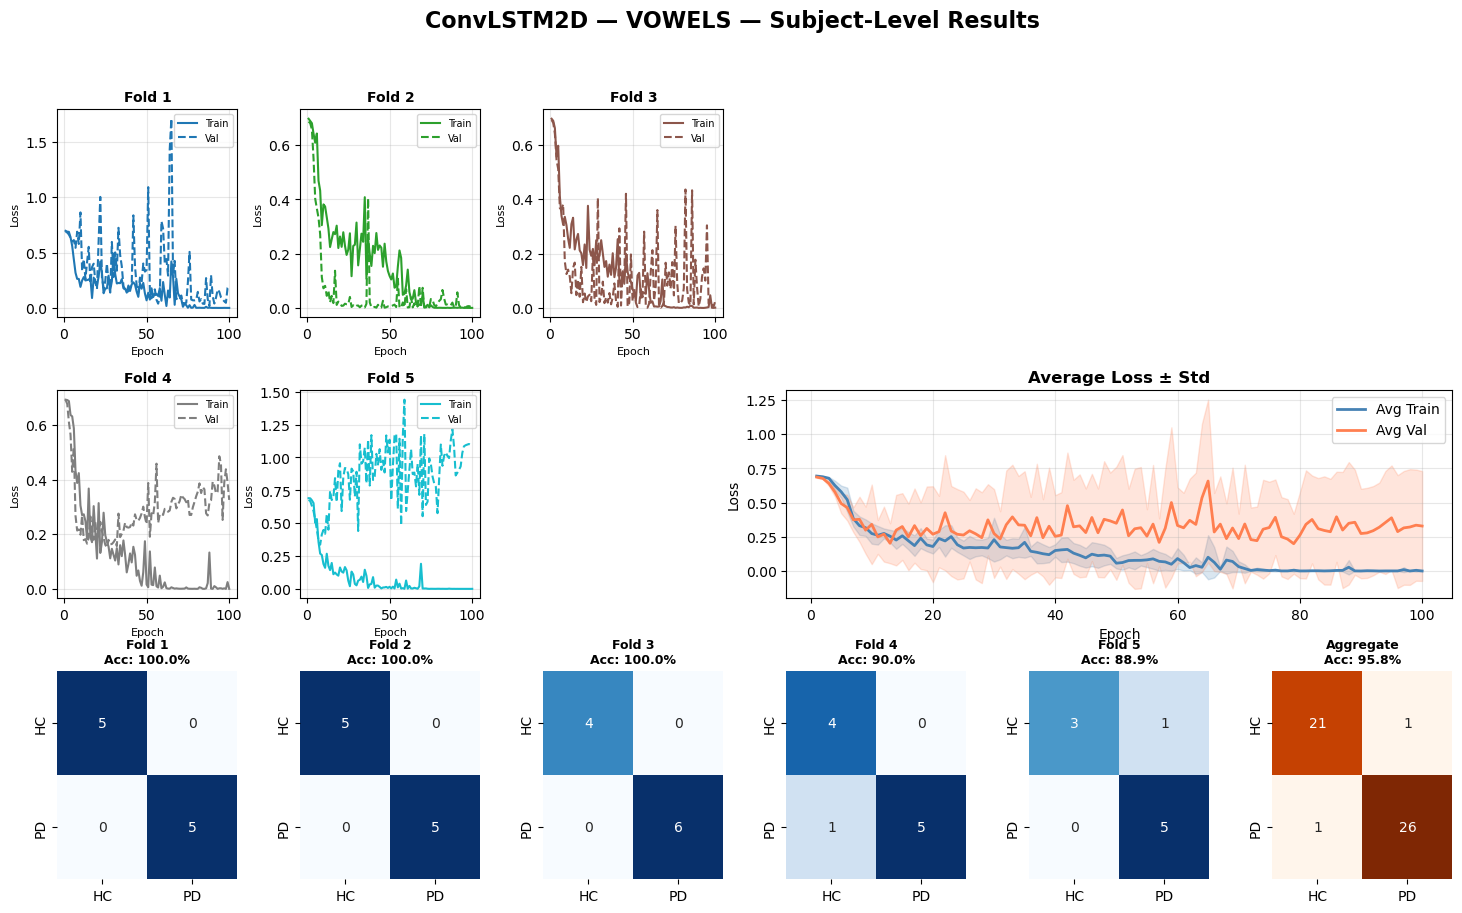


ViT — VOWELS — Subject-Level 5-Fold CV
  Subjects: 49 (HC=22, PD=27)
  Specs per subject: 10 (exact, no padding)

--- Fold 1/5 ---
  Train: 39 (HC=17, PD=22)
  Val:   10 (HC=5, PD=5)
  Epoch  10: Train Loss=0.3214 Acc=89.7% | Val Loss=0.4110 Acc=90.0%
  Epoch  20: Train Loss=0.0312 Acc=97.4% | Val Loss=1.0835 Acc=90.0%
  Epoch  30: Train Loss=0.0020 Acc=100.0% | Val Loss=0.4791 Acc=90.0%
  Epoch  40: Train Loss=0.0105 Acc=100.0% | Val Loss=0.2840 Acc=90.0%
  Epoch  50: Train Loss=0.0004 Acc=100.0% | Val Loss=0.4730 Acc=90.0%
  Epoch  60: Train Loss=0.0005 Acc=100.0% | Val Loss=0.8659 Acc=80.0%
  Epoch  70: Train Loss=0.0001 Acc=100.0% | Val Loss=0.8370 Acc=90.0%
  Epoch  80: Train Loss=0.0001 Acc=100.0% | Val Loss=0.6407 Acc=80.0%
  Epoch  90: Train Loss=0.0001 Acc=100.0% | Val Loss=0.5761 Acc=80.0%
  Epoch 100: Train Loss=0.0001 Acc=100.0% | Val Loss=0.6008 Acc=80.0%

  *** Best Val Acc: 100.0% ***
  Confusion Matrix:
             HC    PD
        HC     5     0
        PD     0     

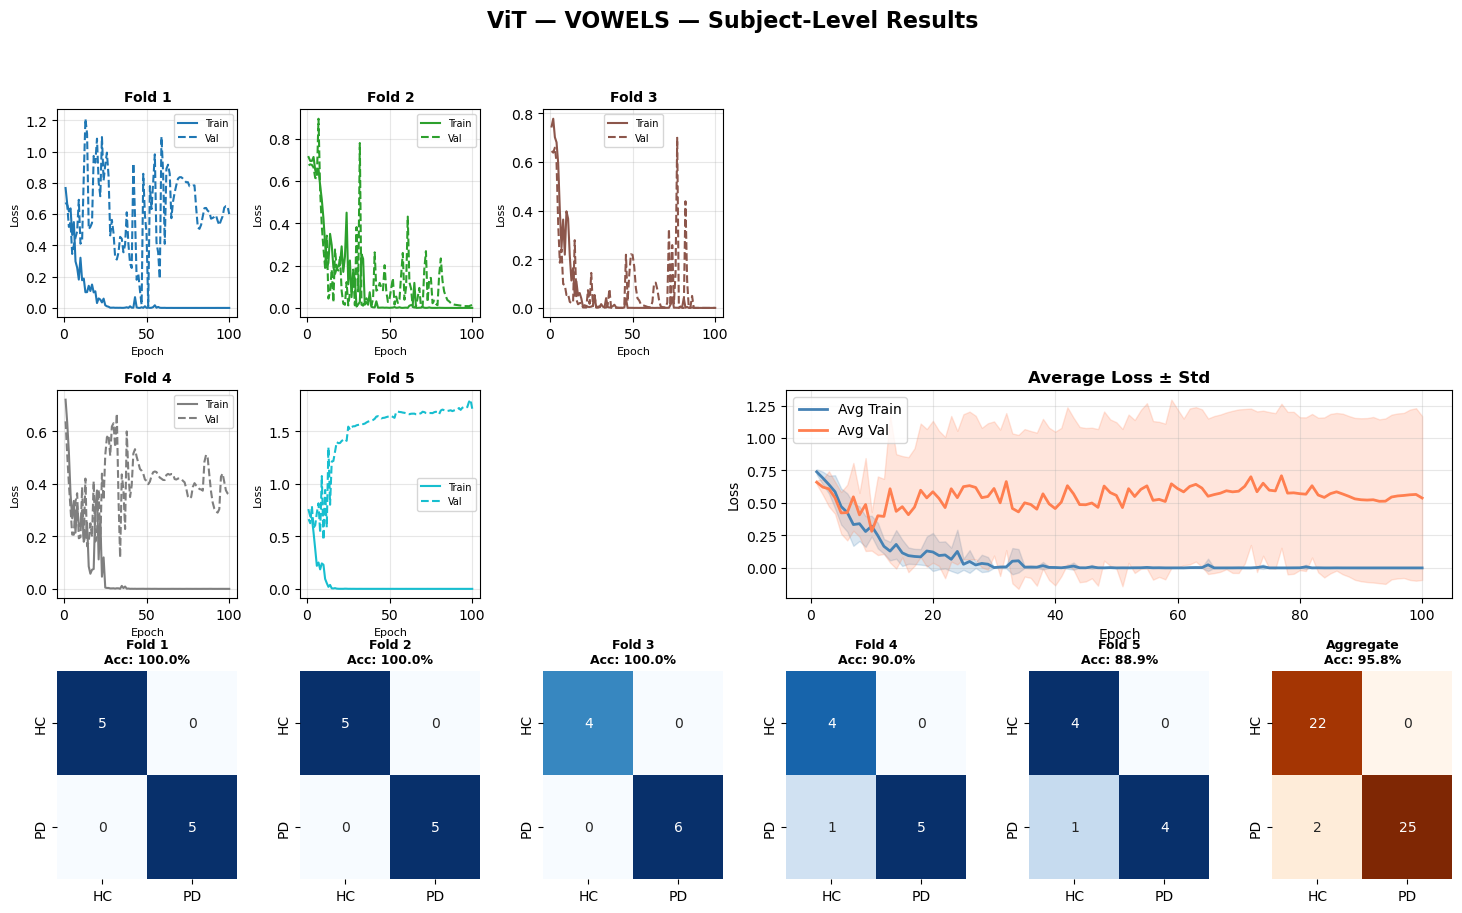


FlipFlop2D — VOWELS — Subject-Level 5-Fold CV
  Subjects: 49 (HC=22, PD=27)
  Specs per subject: 10 (exact, no padding)

--- Fold 1/5 ---
  Train: 39 (HC=17, PD=22)
  Val:   10 (HC=5, PD=5)
  Epoch  10: Train Loss=0.6952 Acc=56.4% | Val Loss=0.6815 Acc=50.0%
  Epoch  20: Train Loss=0.6507 Acc=56.4% | Val Loss=0.6536 Acc=50.0%
  Epoch  30: Train Loss=0.4671 Acc=79.5% | Val Loss=0.5371 Acc=80.0%
  Epoch  40: Train Loss=0.2455 Acc=94.9% | Val Loss=0.2980 Acc=80.0%
  Epoch  50: Train Loss=0.1883 Acc=94.9% | Val Loss=0.2332 Acc=90.0%
  Epoch  60: Train Loss=0.2371 Acc=94.9% | Val Loss=0.3530 Acc=80.0%
  Epoch  70: Train Loss=0.1757 Acc=97.4% | Val Loss=0.2312 Acc=90.0%
  Epoch  80: Train Loss=0.2345 Acc=94.9% | Val Loss=0.2333 Acc=90.0%
  Epoch  90: Train Loss=0.0659 Acc=97.4% | Val Loss=0.2228 Acc=90.0%
  Epoch 100: Train Loss=0.1389 Acc=97.4% | Val Loss=0.3126 Acc=90.0%

  *** Best Val Acc: 90.0% ***
  Confusion Matrix:
             HC    PD
        HC     4     1
        PD     0     5


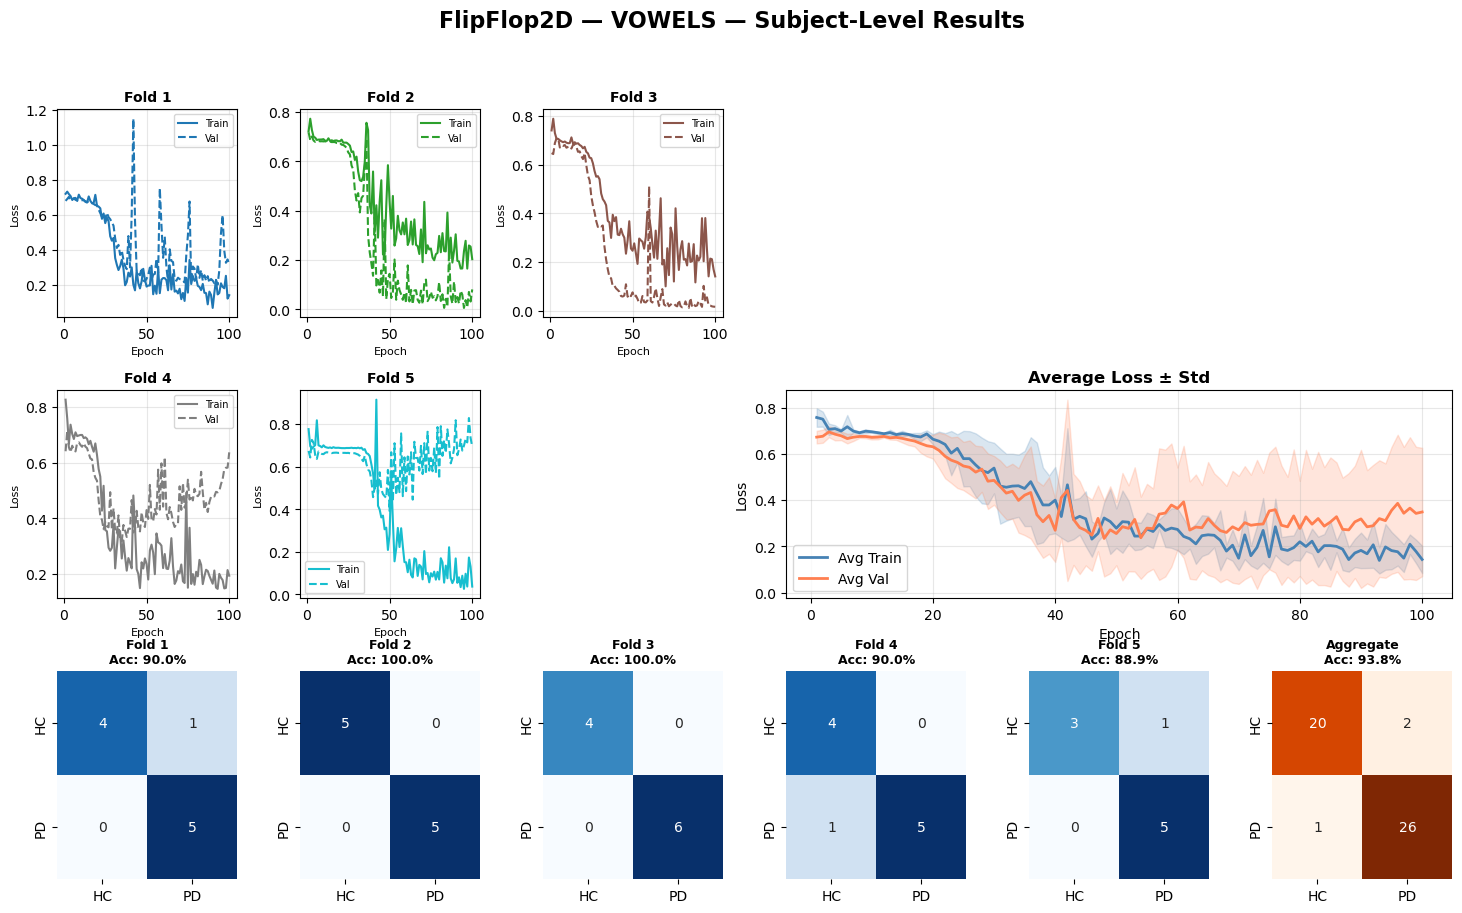


#################################################################
# EXPERIMENT: PA
# Target sounds: {'pa'}
# Required specs per subject: 1
#################################################################

Included: 50 subjects (HC=22, PD=28)
                          AGNESE P  label=0  n_specs= 1  sounds=['pa']
                          ANGELA C  label=0  n_specs= 1  sounds=['pa']
                          ANGELA G  label=0  n_specs= 1  sounds=['pa']
                      ANTONIETTA P  label=0  n_specs= 1  sounds=['pa']
                         ANTONIO C  label=0  n_specs= 1  sounds=['pa']
                         BRIGIDA C  label=0  n_specs= 1  sounds=['pa']
                           GILDA C  label=0  n_specs= 1  sounds=['pa']
                        GIOVANNA G  label=0  n_specs= 1  sounds=['pa']
                        GIOVANNI B  label=0  n_specs= 1  sounds=['pa']
                          GRAZIA G  label=0  n_specs= 1  sounds=['pa']
                        LEONARDA F  label=0  n

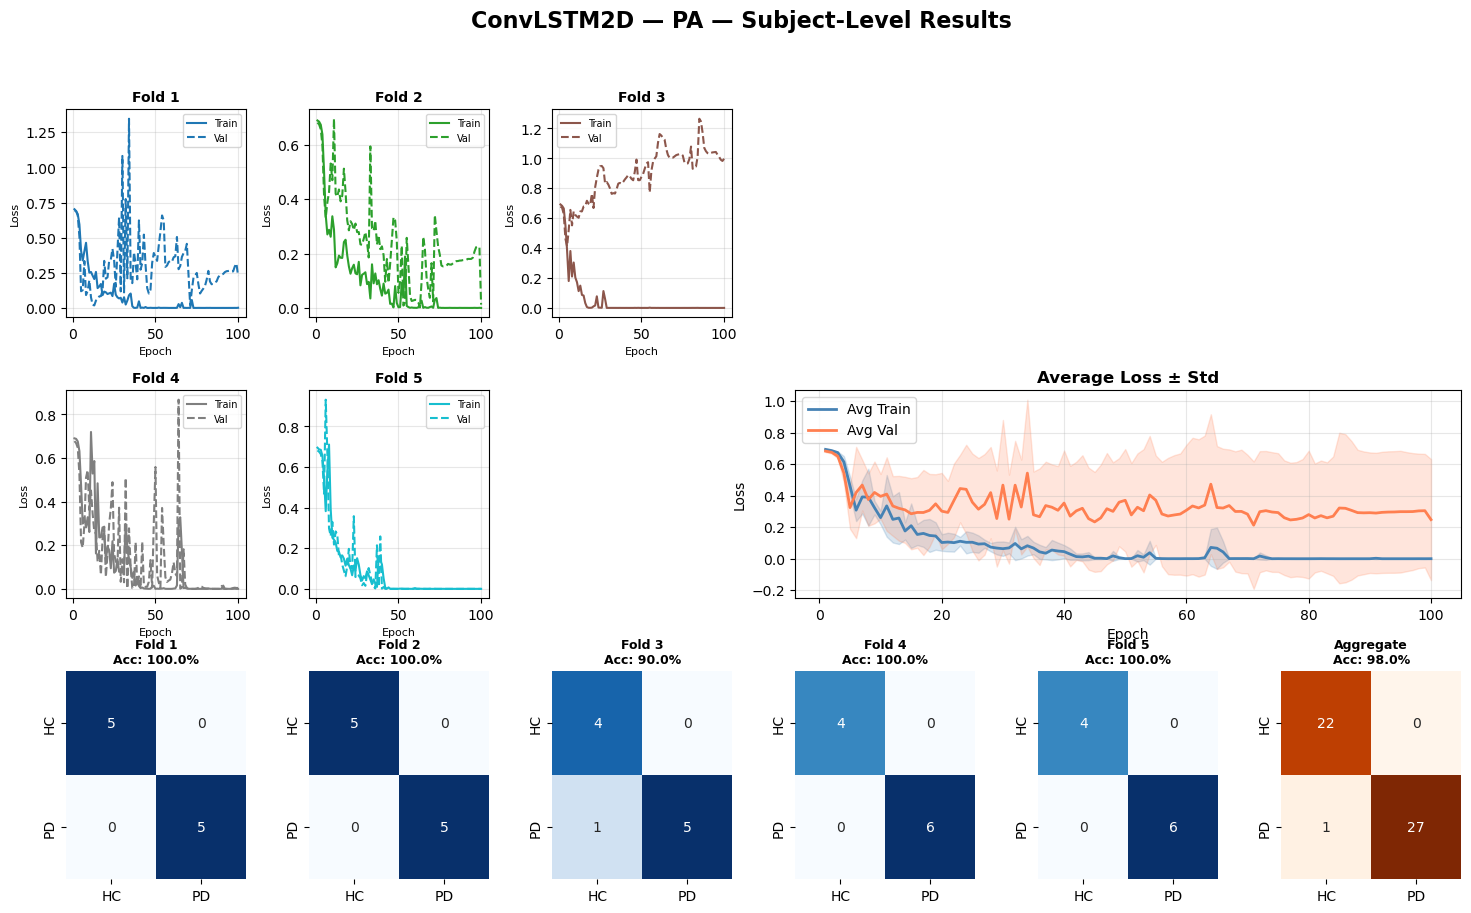


ViT — PA — Subject-Level 5-Fold CV
  Subjects: 50 (HC=22, PD=28)
  Specs per subject: 1 (exact, no padding)

--- Fold 1/5 ---
  Train: 40 (HC=17, PD=23)
  Val:   10 (HC=5, PD=5)
  Epoch  10: Train Loss=0.2365 Acc=95.0% | Val Loss=0.8311 Acc=90.0%
  Epoch  20: Train Loss=0.0028 Acc=100.0% | Val Loss=1.0265 Acc=90.0%
  Epoch  30: Train Loss=0.0006 Acc=100.0% | Val Loss=1.3069 Acc=90.0%
  Epoch  40: Train Loss=0.0003 Acc=100.0% | Val Loss=1.4061 Acc=90.0%
  Epoch  50: Train Loss=0.0003 Acc=100.0% | Val Loss=1.4468 Acc=90.0%
  Epoch  60: Train Loss=0.0002 Acc=100.0% | Val Loss=1.4821 Acc=90.0%
  Epoch  70: Train Loss=0.0002 Acc=100.0% | Val Loss=1.4963 Acc=90.0%
  Epoch  80: Train Loss=0.0001 Acc=100.0% | Val Loss=1.5800 Acc=90.0%
  Epoch  90: Train Loss=0.0849 Acc=97.5% | Val Loss=0.0330 Acc=100.0%
  Epoch 100: Train Loss=0.0004 Acc=100.0% | Val Loss=0.4272 Acc=90.0%

  *** Best Val Acc: 100.0% ***
  Confusion Matrix:
             HC    PD
        HC     5     0
        PD     0     5

-

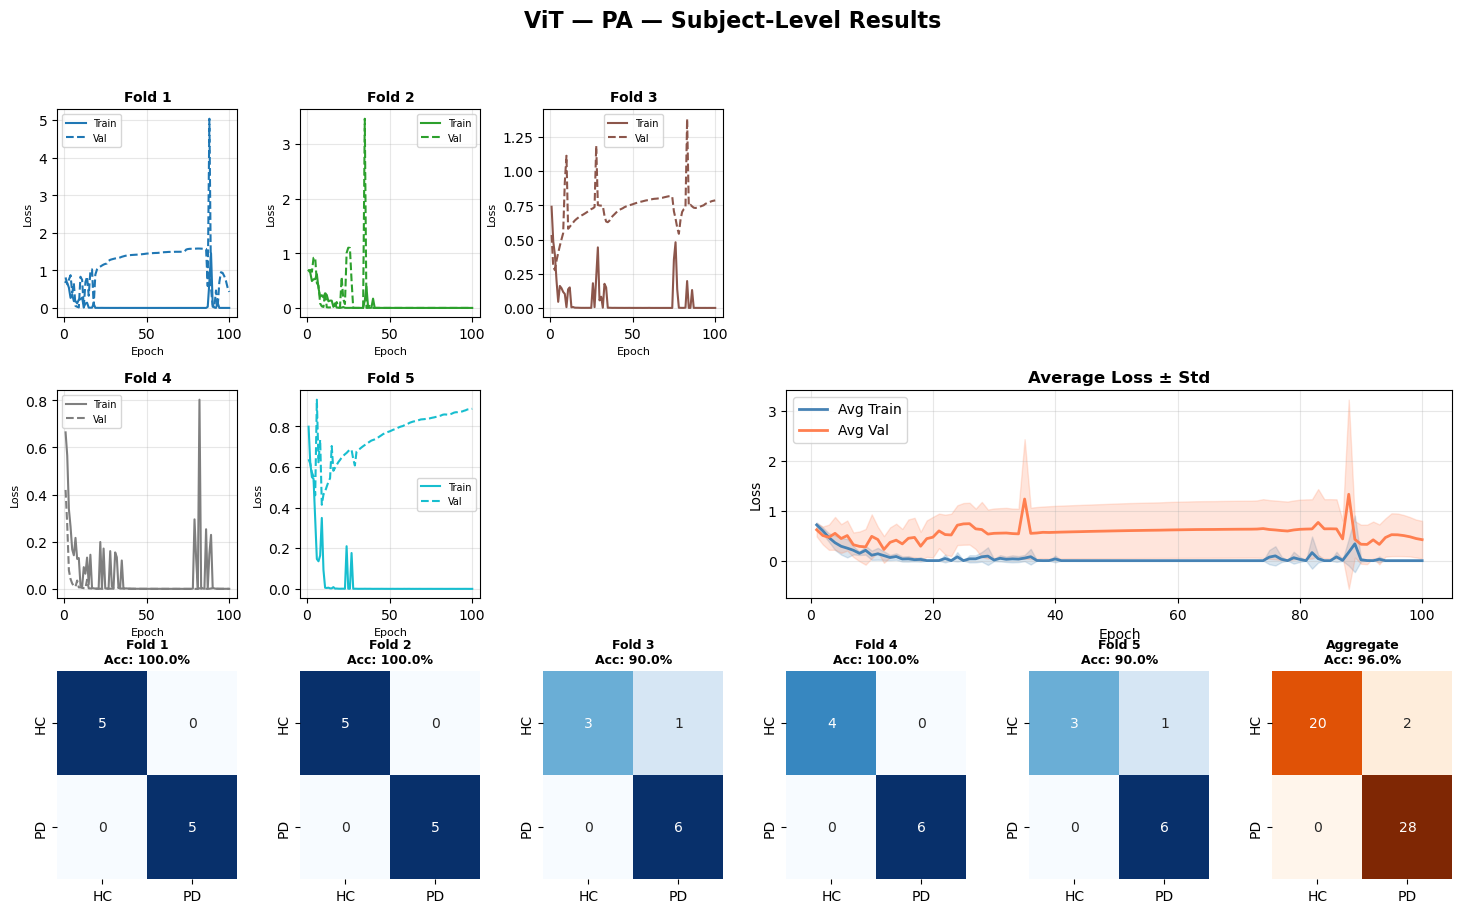


FlipFlop2D — PA — Subject-Level 5-Fold CV
  Subjects: 50 (HC=22, PD=28)
  Specs per subject: 1 (exact, no padding)

--- Fold 1/5 ---
  Train: 40 (HC=17, PD=23)
  Val:   10 (HC=5, PD=5)
  Epoch  10: Train Loss=0.6910 Acc=57.5% | Val Loss=0.6792 Acc=50.0%
  Epoch  20: Train Loss=0.6607 Acc=57.5% | Val Loss=0.6696 Acc=50.0%
  Epoch  30: Train Loss=0.5432 Acc=75.0% | Val Loss=0.5241 Acc=80.0%
  Epoch  40: Train Loss=0.3574 Acc=90.0% | Val Loss=0.4696 Acc=80.0%
  Epoch  50: Train Loss=0.3263 Acc=90.0% | Val Loss=0.1004 Acc=100.0%
  Epoch  60: Train Loss=0.2790 Acc=90.0% | Val Loss=0.1373 Acc=100.0%
  Epoch  70: Train Loss=0.0917 Acc=97.5% | Val Loss=0.1564 Acc=90.0%
  Epoch  80: Train Loss=0.0270 Acc=97.5% | Val Loss=0.5140 Acc=80.0%
  Epoch  90: Train Loss=0.1903 Acc=95.0% | Val Loss=0.2490 Acc=90.0%
  Epoch 100: Train Loss=0.0009 Acc=100.0% | Val Loss=0.3397 Acc=90.0%

  *** Best Val Acc: 100.0% ***
  Confusion Matrix:
             HC    PD
        HC     5     0
        PD     0     5



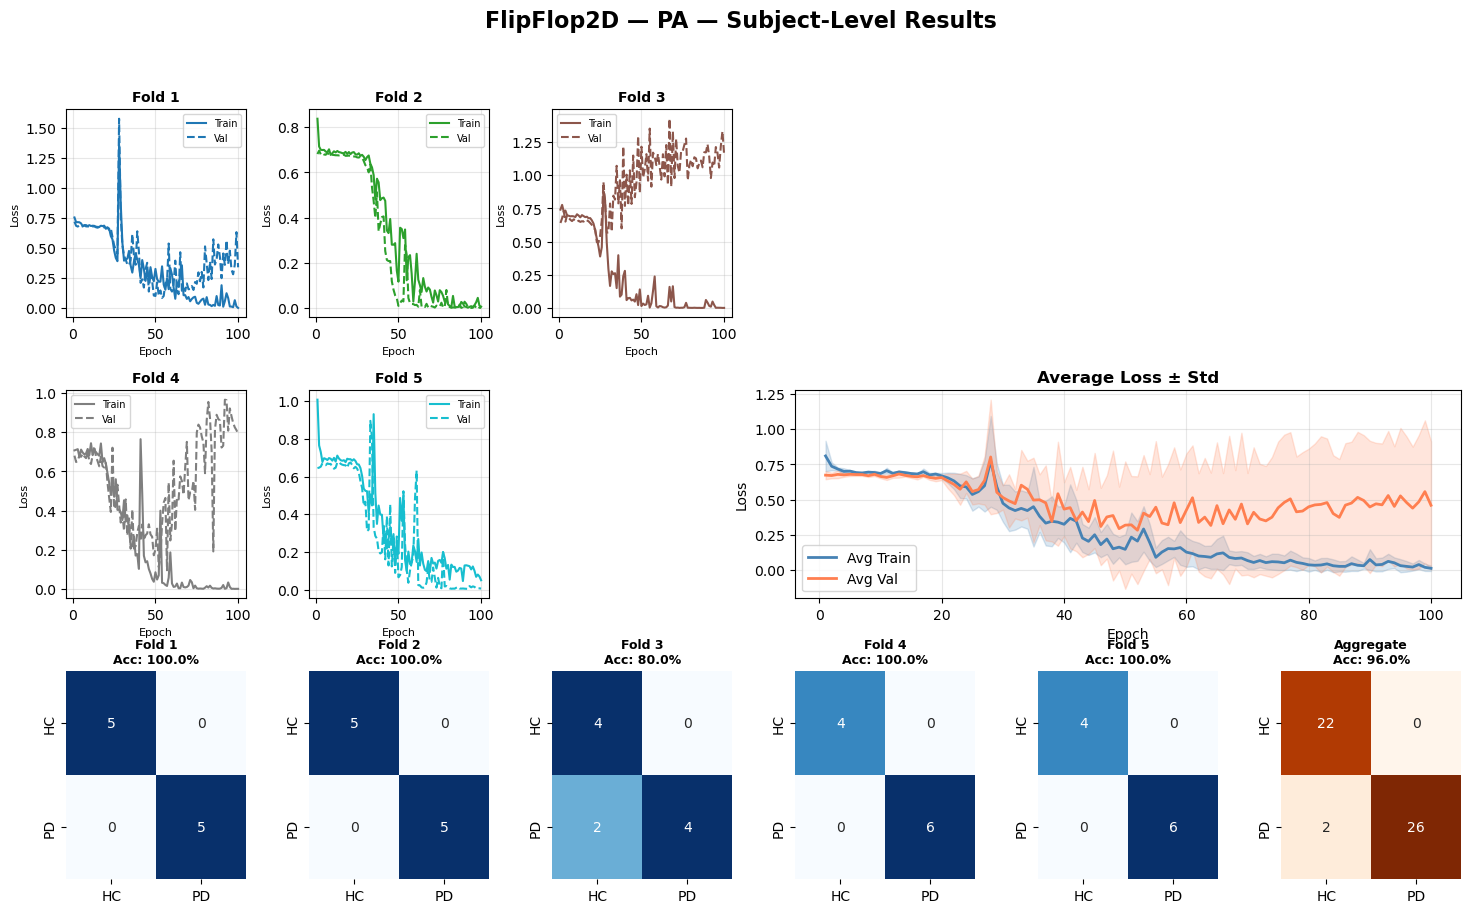


#################################################################
# EXPERIMENT: TA
# Target sounds: {'ta'}
# Required specs per subject: 1
#################################################################

Included: 50 subjects (HC=22, PD=28)
                          AGNESE P  label=0  n_specs= 1  sounds=['ta']
                          ANGELA C  label=0  n_specs= 1  sounds=['ta']
                          ANGELA G  label=0  n_specs= 1  sounds=['ta']
                      ANTONIETTA P  label=0  n_specs= 1  sounds=['ta']
                         ANTONIO C  label=0  n_specs= 1  sounds=['ta']
                         BRIGIDA C  label=0  n_specs= 1  sounds=['ta']
                           GILDA C  label=0  n_specs= 1  sounds=['ta']
                        GIOVANNA G  label=0  n_specs= 1  sounds=['ta']
                        GIOVANNI B  label=0  n_specs= 1  sounds=['ta']
                          GRAZIA G  label=0  n_specs= 1  sounds=['ta']
                        LEONARDA F  label=0  n

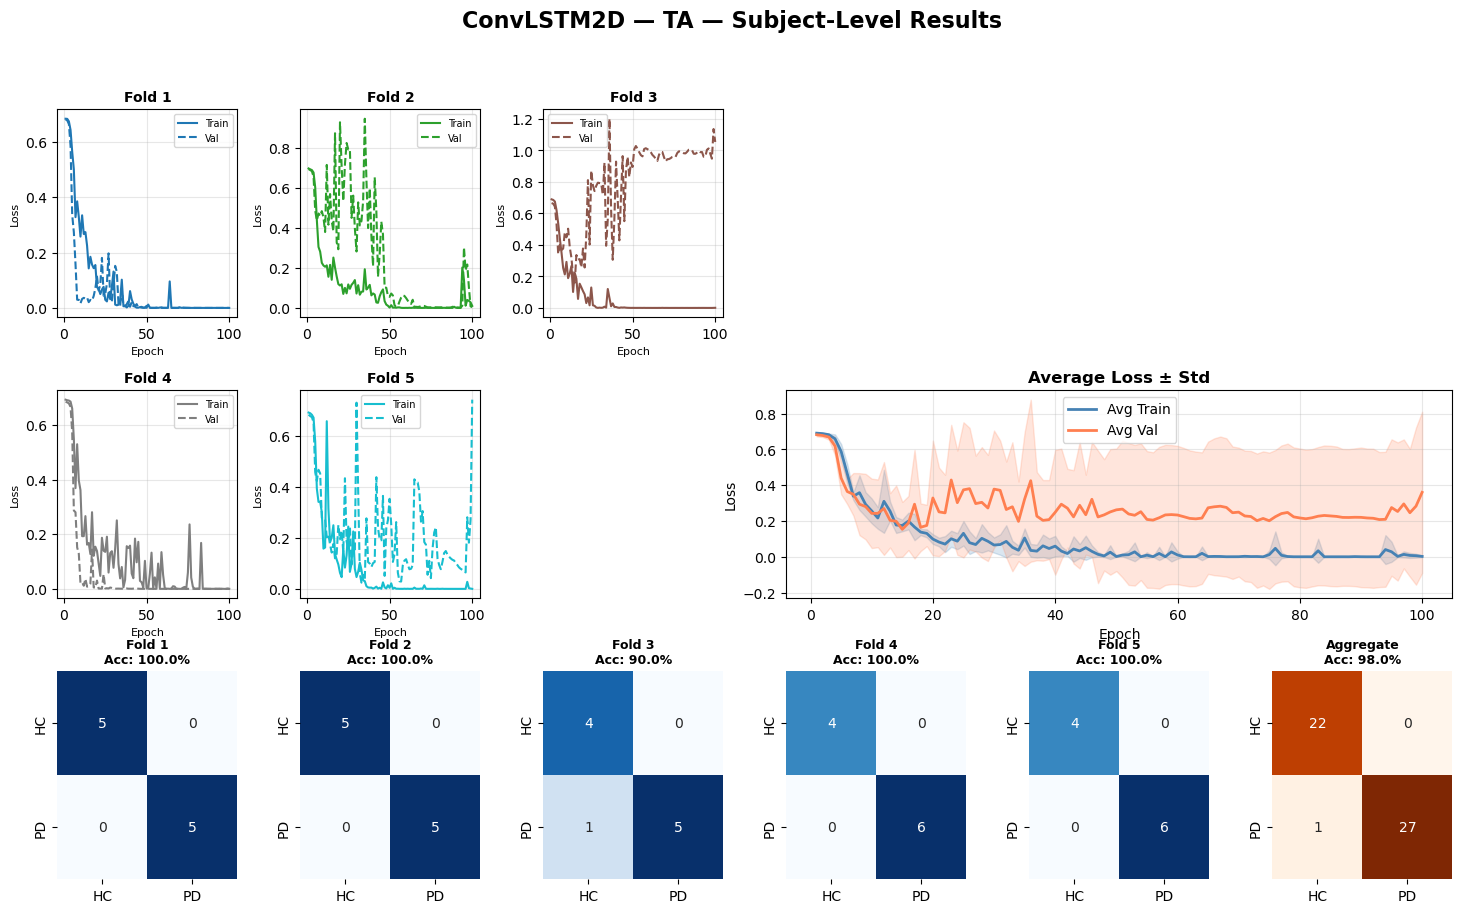


ViT — TA — Subject-Level 5-Fold CV
  Subjects: 50 (HC=22, PD=28)
  Specs per subject: 1 (exact, no padding)

--- Fold 1/5 ---
  Train: 40 (HC=17, PD=23)
  Val:   10 (HC=5, PD=5)
  Epoch  10: Train Loss=0.0067 Acc=100.0% | Val Loss=1.7266 Acc=70.0%
  Epoch  20: Train Loss=0.0007 Acc=100.0% | Val Loss=2.1782 Acc=60.0%
  Epoch  30: Train Loss=0.3613 Acc=95.0% | Val Loss=3.3473 Acc=60.0%
  Epoch  40: Train Loss=0.0004 Acc=100.0% | Val Loss=2.0840 Acc=70.0%
  Epoch  50: Train Loss=0.0004 Acc=100.0% | Val Loss=2.2112 Acc=70.0%
  Epoch  60: Train Loss=0.0002 Acc=100.0% | Val Loss=2.0684 Acc=80.0%
  Epoch  70: Train Loss=0.0001 Acc=100.0% | Val Loss=2.1471 Acc=80.0%
  Epoch  80: Train Loss=0.0001 Acc=100.0% | Val Loss=2.2386 Acc=80.0%
  Epoch  90: Train Loss=0.0002 Acc=100.0% | Val Loss=2.2501 Acc=80.0%
  Epoch 100: Train Loss=0.0001 Acc=100.0% | Val Loss=2.2950 Acc=80.0%

  *** Best Val Acc: 90.0% ***
  Confusion Matrix:
             HC    PD
        HC     4     1
        PD     0     5

--

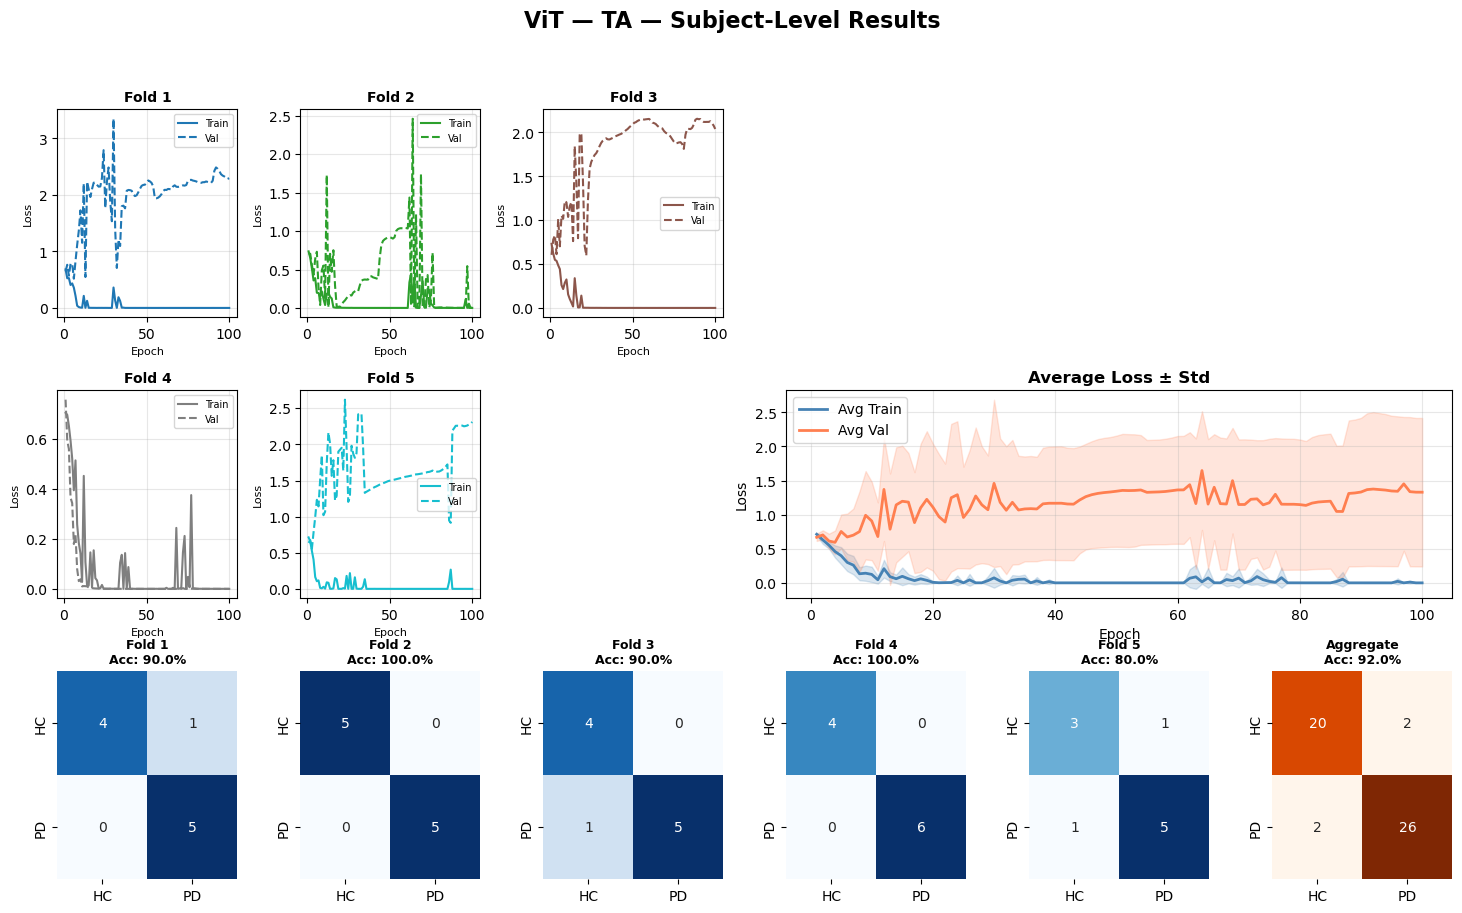


FlipFlop2D — TA — Subject-Level 5-Fold CV
  Subjects: 50 (HC=22, PD=28)
  Specs per subject: 1 (exact, no padding)

--- Fold 1/5 ---
  Train: 40 (HC=17, PD=23)
  Val:   10 (HC=5, PD=5)
  Epoch  10: Train Loss=0.6910 Acc=57.5% | Val Loss=0.6803 Acc=50.0%
  Epoch  20: Train Loss=0.6830 Acc=57.5% | Val Loss=0.6816 Acc=50.0%
  Epoch  30: Train Loss=0.6634 Acc=57.5% | Val Loss=0.7016 Acc=50.0%
  Epoch  40: Train Loss=0.5853 Acc=57.5% | Val Loss=0.8918 Acc=50.0%
  Epoch  50: Train Loss=0.4276 Acc=80.0% | Val Loss=1.3426 Acc=40.0%
  Epoch  60: Train Loss=0.2451 Acc=92.5% | Val Loss=2.1894 Acc=60.0%
  Epoch  70: Train Loss=0.1399 Acc=97.5% | Val Loss=2.5448 Acc=60.0%
  Epoch  80: Train Loss=0.1386 Acc=97.5% | Val Loss=2.5790 Acc=60.0%
  Epoch  90: Train Loss=0.1115 Acc=97.5% | Val Loss=2.6005 Acc=60.0%
  Epoch 100: Train Loss=0.0870 Acc=97.5% | Val Loss=2.6283 Acc=60.0%

  *** Best Val Acc: 70.0% ***
  Confusion Matrix:
             HC    PD
        HC     2     3
        PD     0     5

--- 

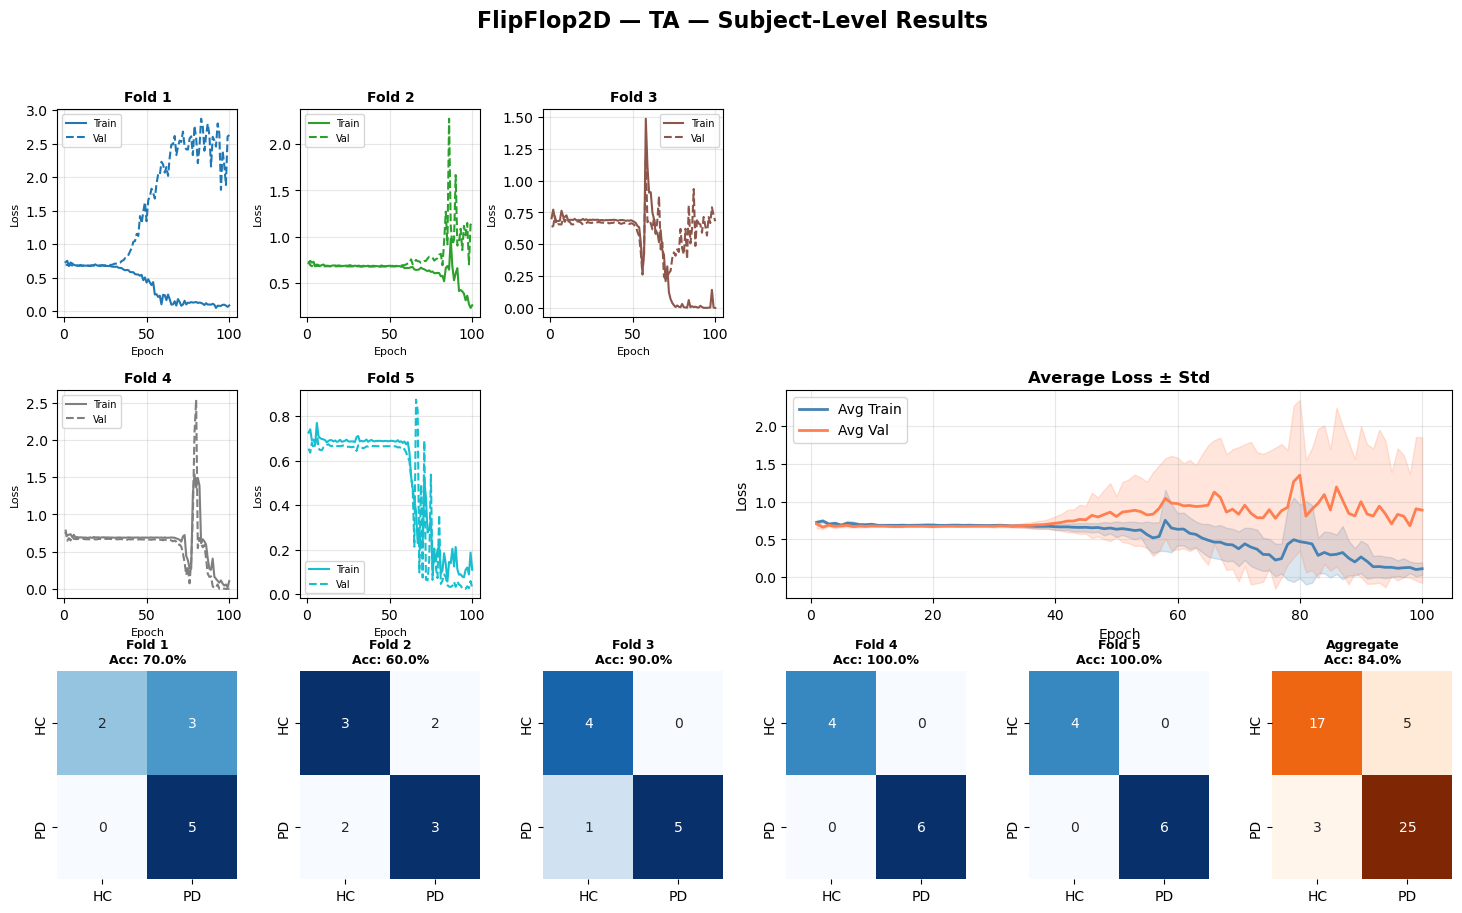



GRAND COMPARISON — Subject-Level Classification (No Padding)
  Sound      Model             Mean Acc    Std Acc    Mean F1     Std F1
  -----------------------------------------------------------------
  vowels     ConvLSTM2D           95.8%       5.2%      96.4%       4.5%
  vowels     ViT                  95.8%       5.2%      96.0%       5.0%
  vowels     FlipFlop2D           93.8%       5.1%      94.5%       4.5%
  -----------------------------------------------------------------
  pa         ConvLSTM2D           98.0%       4.0%      98.2%       3.6%
  pa         ViT                  96.0%       4.9%      96.9%       3.8%
  pa         FlipFlop2D           96.0%       8.0%      96.0%       8.0%
  -----------------------------------------------------------------
  ta         ConvLSTM2D           98.0%       4.0%      98.2%       3.6%
  ta         ViT                  92.0%       7.5%      93.0%       6.3%
  ta         FlipFlop2D           84.0%      16.2%      85.6%      15.3%
  -

In [ ]:
# ============================================================
# Speech PD Detection — SUBJECT-LEVEL Classification
# THREE SEPARATE EXPERIMENTS:
#   1. Vowels: a,e,i,o,u × 2 reps = 10 specs/subject
#   2. Pa (D1): 1 spec/subject
#   3. Ta (D2): 1 spec/subject
# NO PADDING — subjects with missing data are EXCLUDED
# Models: ConvLSTM2D | Vision Transformer | Flip-Flop 2D
# 5-Fold CV over subjects | Confusion matrices
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
import librosa
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION
# ============================================================
ITALIAN_PATH = r"Italian Parkinson's Voice and speech"
SAVE_DIR = Path("speech_subject_models")
SAVE_DIR.mkdir(exist_ok=True)

N_FOLDS    = 5
BATCH_SIZE = 4
EPOCHS     = 100
LR         = 0.001
SR         = 16000
N_TIME     = 32
N_FREQ     = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Sound group definitions with EXACT expected count
SOUND_GROUPS = {
    'vowels': {'sounds': {'a', 'e', 'i', 'o', 'u'}, 'expected_specs': 10},
    'pa':     {'sounds': {'pa'},                      'expected_specs': 1},
    'ta':     {'sounds': {'ta'},                      'expected_specs': 1},
}

print(f"Device: {DEVICE}")
torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# DATA LOADING — SUBJECT LEVEL (STRICT, NO PADDING)
# ============================================================
def get_sound_type(filename):
    f = filename.upper()
    if f.startswith('VA1') or f.startswith('VA2'): return 'a'
    if f.startswith('VE1') or f.startswith('VE2'): return 'e'
    if f.startswith('VI1') or f.startswith('VI2'): return 'i'
    if f.startswith('VO1') or f.startswith('VO2'): return 'o'
    if f.startswith('VU1') or f.startswith('VU2'): return 'u'
    if f.startswith('D1'): return 'pa'
    if f.startswith('D2'): return 'ta'
    return None


def find_subject_folders(folder_path):
    subjects = []
    for item in folder_path.iterdir():
        if not item.is_dir():
            continue
        if list(item.glob('*.wav')) + list(item.glob('*.WAV')):
            subjects.append(item)
        else:
            for sub in item.iterdir():
                if sub.is_dir() and (list(sub.glob('*.wav')) + list(sub.glob('*.WAV'))):
                    subjects.append(sub)
    return subjects


def extract_melspectrogram(wav_path, sr=SR, n_mels=128, max_sec=5):
    try:
        y, _ = librosa.load(wav_path, sr=sr)
        y, _ = librosa.effects.trim(y, top_db=20)

        if len(y) < sr * 0.1:
            return None
        if not np.isfinite(y).all():
            return None

        max_samples = sr * max_sec
        if len(y) < max_samples:
            y = np.pad(y, (0, max_samples - len(y)))
        else:
            y = y[:max_samples]

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=512, hop_length=256
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        mel_resized = cv2.resize(mel_db, (N_TIME, N_FREQ))
        return mel_resized.T.astype(np.float32)  # (N_TIME, N_FREQ)

    except Exception:
        return None


def load_subject_data(base_path, target_sounds, expected_specs):
    """
    Load data grouped by SUBJECT, keeping only the specified sounds.
    STRICT: subjects must have EXACTLY expected_specs valid spectrograms.
    Subjects with fewer are EXCLUDED (no padding).

    Parameters
    ----------
    base_path : str
    target_sounds : set of str
    expected_specs : int — required number of spectrograms per subject

    Returns
    -------
    subjects : list[dict]
    excluded : list[dict] — subjects that were dropped (for reporting)
    """
    base_path = Path(base_path)
    folders = {
        '15 Young Healthy Control':           0,
        '22 Elderly Healthy Control':         0,
        "28 People with Parkinson's disease": 1,
    }

    subjects = []
    excluded = []
    seen_dirs = set()

    for folder_name, label in folders.items():
        folder_path = base_path / folder_name
        if not folder_path.exists():
            print(f"  [WARN] Missing folder: {folder_path}")
            continue

        subj_dirs = find_subject_folders(folder_path)
        for subj_dir in subj_dirs:
            key = str(subj_dir.resolve())
            if key in seen_dirs:
                continue
            seen_dirs.add(key)

            wavs = list(subj_dir.glob('*.wav')) + list(subj_dir.glob('*.WAV'))

            specs = []
            tags  = []
            processed_files = set()

            for wav in wavs:
                wav_key = str(wav.resolve())
                if wav_key in processed_files:
                    continue
                processed_files.add(wav_key)

                sound = get_sound_type(wav.name)
                if sound not in target_sounds:
                    continue

                spec = extract_melspectrogram(str(wav))
                if spec is not None:
                    specs.append(spec)
                    tags.append(sound)

            # STRICT CHECK: must have exactly expected_specs
            if len(specs) != expected_specs:
                excluded.append({
                    'name':     subj_dir.name,
                    'label':    label,
                    'group':    folder_name,
                    'n_specs':  len(specs),
                    'expected': expected_specs,
                    'tags':     tags,
                })
                continue

            subjects.append({
                'name':       subj_dir.name,
                'label':      label,
                'specs':      np.stack(specs),   # (expected_specs, N_TIME, N_FREQ)
                'sound_tags': tags,
                'group':      folder_name,
            })

    return subjects, excluded


# ============================================================
# DATASET — NO PADDING, FIXED SIZE
# ============================================================
class SubjectBagDataset(Dataset):
    """
    Each item is a FIXED-SIZE bag of spectrograms for one subject.
    No padding, no mask — every subject has exactly n_specs spectrograms.
    """
    def __init__(self, subjects_list):
        self.subjects = subjects_list

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subj = self.subjects[idx]
        specs = subj['specs'].copy()                     # (n_specs, N_TIME, N_FREQ)
        label = subj['label']

        # Normalize per-spectrogram
        mean = specs.mean(axis=(1, 2), keepdims=True)
        std  = specs.std(axis=(1, 2), keepdims=True) + 1e-8
        specs = (specs - mean) / std

        return (
            torch.FloatTensor(specs),        # (n_specs, N_TIME, N_FREQ)
            torch.LongTensor([label]),       # (1,)
        )


# ============================================================
# MODEL 1: ConvLSTM2D
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2DEncoder(nn.Module):
    """Encode a SINGLE spectrogram (N_TIME, N_FREQ) → feature vector."""
    def __init__(self, hid1=32, hid2=16):
        super().__init__()
        self.hid1 = hid1
        self.hid2 = hid2
        self.cell1 = ConvLSTMCell(1, hid1)
        self.drop1 = nn.Dropout(0.3)
        self.cell2 = ConvLSTMCell(hid1, hid2)
        self.drop2 = nn.Dropout(0.3)

    def forward(self, x):
        """x : (B, N_TIME, N_FREQ) → (B, hid2*N_FREQ)"""
        B, T, F = x.shape
        h1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        c1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        h2 = torch.zeros(B, self.hid2, F, 1, device=x.device)
        c2 = torch.zeros(B, self.hid2, F, 1, device=x.device)

        for t in range(T):
            xt = x[:, t, :].unsqueeze(1).unsqueeze(-1)  # (B, 1, F, 1)
            h1, c1 = self.cell1(xt, h1, c1)
            h1_d = self.drop1(h1)
            h2, c2 = self.cell2(h1_d, h2, c2)

        return self.drop2(h2).view(B, -1)


class ConvLSTMSubjectModel(nn.Module):
    def __init__(self, n_specs):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = ConvLSTM2DEncoder(hid1=32, hid2=16)
        feat_dim = 16 * N_FREQ
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, 2),
        )

    def forward(self, bag):
        """bag : (B, n_specs, N_TIME, N_FREQ)"""
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))     # (B*S, feat_dim)
        feats = feats.view(B, S, -1)                    # (B, S, feat_dim)
        pooled = feats.mean(dim=1)                       # (B, feat_dim)
        return self.head(pooled)


# ============================================================
# MODEL 2: Vision Transformer
# ============================================================
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)

        self.proj      = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList(
            [TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)]
        )
        self.norm = nn.LayerNorm(dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        """x : (B, N_TIME, N_FREQ) → (B, dim)"""
        x = x.unsqueeze(1)
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x[:, 0])


class ViTSubjectModel(nn.Module):
    def __init__(self, n_specs, dim=64):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = ViTEncoder(dim=dim)
        self.head    = nn.Sequential(
            nn.Linear(dim, 32), nn.ReLU(),
            nn.Dropout(0.1), nn.Linear(32, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))      # (B*S, dim)
        feats = feats.view(B, S, -1)                     # (B, S, dim)
        pooled = feats.mean(dim=1)                        # (B, dim)
        return self.head(pooled)


# ============================================================
# MODEL 3: Flip-Flop 2D
# ============================================================
class FlipFlopCell2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.conv_xj = nn.Conv2d(in_ch, hid_ch, ks, padding=ks // 2)
        self.conv_hj = nn.Conv2d(hid_ch, hid_ch, ks, padding=ks // 2)
        self.conv_xk = nn.Conv2d(in_ch, hid_ch, ks, padding=ks // 2)
        self.conv_hk = nn.Conv2d(hid_ch, hid_ch, ks, padding=ks // 2)

    def forward(self, x, h):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h))
        return (1 - h) * j + (1 - k) * h


class FlipFlop2DEncoder(nn.Module):
    def __init__(self, hid1=64, hid2=32):
        super().__init__()
        self.hid1 = hid1
        self.hid2 = hid2
        self.cell1 = FlipFlopCell2D(1, hid1)
        self.drop1 = nn.Dropout(0.15)
        self.cell2 = FlipFlopCell2D(hid1, hid2)
        self.drop2 = nn.Dropout(0.15)

    def forward(self, x):
        B, T, F = x.shape
        h1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        h2 = torch.zeros(B, self.hid2, F, 1, device=x.device)

        for t in range(T):
            xt = x[:, t, :].unsqueeze(1).unsqueeze(-1)
            h1 = self.cell1(xt, h1)
            h1_d = self.drop1(h1)
            h2 = self.cell2(h1_d, h2)

        return self.drop2(h2).view(B, -1)


class FlipFlopSubjectModel(nn.Module):
    def __init__(self, n_specs):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = FlipFlop2DEncoder(hid1=64, hid2=32)
        feat_dim = 32 * N_FREQ
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(),
            nn.Dropout(0.15), nn.Linear(64, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


# ============================================================
# TRAINING FUNCTIONS (no mask)
# ============================================================
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for bag, label in loader:
        bag   = bag.to(DEVICE)
        label = label.squeeze(1).to(DEVICE)

        optimizer.zero_grad()
        out  = model(bag)
        loss = criterion(out, label)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == label).sum().item()
        total      += label.size(0)

    return total_loss / len(loader), 100.0 * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for bag, label in loader:
            bag   = bag.to(DEVICE)
            label = label.squeeze(1).to(DEVICE)

            out  = model(bag)
            loss = criterion(out, label)

            total_loss += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


# ============================================================
# 5-FOLD CV OVER SUBJECTS
# ============================================================
def train_5fold(subjects, sound_group, model_name, model_fn, n_specs):
    labels = np.array([s['label'] for s in subjects])
    n_hc = (labels == 0).sum()
    n_pd = (labels == 1).sum()

    print(f"\n{'='*65}")
    print(f"{model_name} — {sound_group.upper()} — Subject-Level 5-Fold CV")
    print(f"  Subjects: {len(subjects)} (HC={n_hc}, PD={n_pd})")
    print(f"  Specs per subject: {n_specs} (exact, no padding)")
    print(f"{'='*65}")

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    fold_train_losses = []
    fold_val_losses   = []
    fold_metrics      = []
    all_preds         = []
    all_labels_out    = []

    model_dir = SAVE_DIR / model_name / sound_group
    model_dir.mkdir(parents=True, exist_ok=True)

    for fold, (train_idx, val_idx) in enumerate(skf.split(labels, labels)):
        print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

        train_subjs = [subjects[i] for i in train_idx]
        val_subjs   = [subjects[i] for i in val_idx]

        n_tr_hc = sum(1 for s in train_subjs if s['label'] == 0)
        n_tr_pd = sum(1 for s in train_subjs if s['label'] == 1)
        n_va_hc = sum(1 for s in val_subjs   if s['label'] == 0)
        n_va_pd = sum(1 for s in val_subjs   if s['label'] == 1)

        print(f"  Train: {len(train_subjs)} (HC={n_tr_hc}, PD={n_tr_pd})")
        print(f"  Val:   {len(val_subjs)} (HC={n_va_hc}, PD={n_va_pd})")

        # Save val info for reproducibility
        np.save(model_dir / f"fold{fold+1}_val_indices.npy", val_idx)
        with open(model_dir / f"fold{fold+1}_val_subjects.txt", 'w') as f:
            for s in val_subjs:
                f.write(f"{s['name']} label={s['label']} n_specs={s['specs'].shape[0]}\n")

        train_loader = DataLoader(
            SubjectBagDataset(train_subjs),
            batch_size=BATCH_SIZE, shuffle=True
        )
        val_loader = DataLoader(
            SubjectBagDataset(val_subjs),
            batch_size=BATCH_SIZE
        )

        model     = model_fn(n_specs).to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

        best_val_acc = 0.0
        best_preds   = None
        best_labels  = None
        train_losses = []
        val_losses   = []

        for epoch in range(EPOCHS):
            tr_loss, tr_acc           = train_epoch(model, train_loader, criterion, optimizer)
            val_loss, preds, labels_v = eval_epoch(model, val_loader, criterion)
            val_acc                   = accuracy_score(labels_v, preds)

            train_losses.append(tr_loss)
            val_losses.append(val_loss)

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_preds   = preds.copy()
                best_labels  = labels_v.copy()
                torch.save(model.state_dict(), model_dir / f"fold{fold+1}_best.pth")

            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch+1:3d}: Train Loss={tr_loss:.4f} Acc={tr_acc:.1f}% | "
                      f"Val Loss={val_loss:.4f} Acc={val_acc*100:.1f}%")

        torch.save(model.state_dict(), model_dir / f"fold{fold+1}_last.pth")

        print(f"\n  *** Best Val Acc: {best_val_acc*100:.1f}% ***")
        cm = confusion_matrix(best_labels, best_preds)
        print(f"  Confusion Matrix:")
        print(f"             HC    PD")
        print(f"        HC  {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"        PD  {cm[1,0]:4d}  {cm[1,1]:4d}")

        fold_train_losses.append(train_losses)
        fold_val_losses.append(val_losses)
        fold_metrics.append({
            'acc':  best_val_acc,
            'prec': precision_score(best_labels, best_preds, zero_division=0),
            'rec':  recall_score(best_labels, best_preds, zero_division=0),
            'f1':   f1_score(best_labels, best_preds, zero_division=0),
        })
        all_preds.extend(best_preds)
        all_labels_out.extend(best_labels)

    return {
        'train_losses': fold_train_losses,
        'val_losses':   fold_val_losses,
        'metrics':      fold_metrics,
        'all_preds':    np.array(all_preds),
        'all_labels':   np.array(all_labels_out),
    }


# ============================================================
# VISUALIZATION
# ============================================================
def plot_results(results, model_name, sound_group, labels_for_splits):
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 6, hspace=0.35, wspace=0.35)
    fig.suptitle(f'{model_name} — {sound_group.upper()} — Subject-Level Results',
                 fontsize=16, fontweight='bold')

    train_losses = results['train_losses']
    val_losses   = results['val_losses']
    colors = plt.cm.tab10(np.linspace(0, 1, N_FOLDS))

    for fold in range(N_FOLDS):
        ax = fig.add_subplot(gs[fold // 3, fold % 3])
        epochs = range(1, EPOCHS + 1)
        ax.plot(epochs, train_losses[fold], label='Train', color=colors[fold])
        ax.plot(epochs, val_losses[fold], label='Val', color=colors[fold], linestyle='--')
        ax.set_title(f'Fold {fold+1}', fontweight='bold', fontsize=10)
        ax.set_xlabel('Epoch', fontsize=8)
        ax.set_ylabel('Loss', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 3:])
    avg_train = np.mean(train_losses, axis=0)
    avg_val   = np.mean(val_losses, axis=0)
    std_train = np.std(train_losses, axis=0)
    std_val   = np.std(val_losses, axis=0)
    epochs    = range(1, EPOCHS + 1)

    ax.plot(epochs, avg_train, label='Avg Train', color='steelblue', linewidth=2)
    ax.plot(epochs, avg_val,   label='Avg Val',   color='coral',      linewidth=2)
    ax.fill_between(epochs, avg_train - std_train, avg_train + std_train,
                    alpha=0.2, color='steelblue')
    ax.fill_between(epochs, avg_val - std_val, avg_val + std_val,
                    alpha=0.2, color='coral')
    ax.set_title('Average Loss ± Std', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    start = 0
    for fold, (_, val_idx) in enumerate(skf.split(labels_for_splits, labels_for_splits)):
        ax = fig.add_subplot(gs[2, fold])
        end = start + len(val_idx)
        cm = confusion_matrix(
            results['all_labels'][start:end],
            results['all_preds'][start:end]
        )
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        ax.set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                     fontsize=9, fontweight='bold')
        start = end

    ax = fig.add_subplot(gs[2, 5])
    cm_all = confusion_matrix(results['all_labels'], results['all_preds'])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=ax, cbar=False,
                xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    ax.set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%", fontsize=9, fontweight='bold')

    plt.savefig(SAVE_DIR / f'{model_name}_{sound_group}_subject_results.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def print_summary(results, model_name, sound_group):
    print(f"\n{'='*55}")
    print(f"{model_name} — {sound_group.upper()} — Subject-Level Summary")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")

    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")

    print(f"  {'-'*44}")
    accs = [m['acc'] for m in results['metrics']]
    f1s  = [m['f1']  for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% "
          f"{np.mean([m['prec'] for m in results['metrics']])*100:>7.1f}% "
          f"{np.mean([m['rec'] for m in results['metrics']])*100:>7.1f}% "
          f"{np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}% "
          f"{np.std([m['prec'] for m in results['metrics']])*100:>7.1f}% "
          f"{np.std([m['rec'] for m in results['metrics']])*100:>7.1f}% "
          f"{np.std(f1s)*100:>7.1f}%")


# ============================================================
# MAIN — 3 EXPERIMENTS × 3 MODELS = 9 RUNS
# ============================================================
if __name__ == '__main__':

    MODEL_REGISTRY = {
        'ConvLSTM2D': ConvLSTMSubjectModel,
        'ViT':        ViTSubjectModel,
        'FlipFlop2D': FlipFlopSubjectModel,
    }

    grand_results = {}

    for sg_name, sg_cfg in SOUND_GROUPS.items():
        expected = sg_cfg['expected_specs']

        print(f"\n{'#'*65}")
        print(f"# EXPERIMENT: {sg_name.upper()}")
        print(f"# Target sounds: {sg_cfg['sounds']}")
        print(f"# Required specs per subject: {expected}")
        print(f"{'#'*65}")

        subjects, excluded = load_subject_data(
            ITALIAN_PATH, sg_cfg['sounds'], expected
        )
        labels = np.array([s['label'] for s in subjects])

        print(f"\nIncluded: {len(subjects)} subjects (HC={sum(labels==0)}, PD={sum(labels==1)})")
        for subj in subjects:
            print(f"    {subj['name']:>30s}  label={subj['label']}  "
                  f"n_specs={subj['specs'].shape[0]:2d}  sounds={subj['sound_tags']}")

        if excluded:
            print(f"\nExcluded: {len(excluded)} subjects (incomplete data)")
            for ex in excluded:
                print(f"    {ex['name']:>30s}  label={ex['label']}  "
                      f"n_specs={ex['n_specs']}/{ex['expected']}  tags={ex['tags']}")

        if len(subjects) < N_FOLDS * 2:
            print(f"\n  [SKIP] Too few subjects ({len(subjects)}) for {N_FOLDS}-fold CV")
            continue

        for model_name, model_cls in MODEL_REGISTRY.items():
            results = train_5fold(
                subjects, sg_name, model_name,
                lambda ns, cls=model_cls: cls(ns),
                expected
            )
            grand_results[(sg_name, model_name)] = results
            print_summary(results, model_name, sg_name)
            plot_results(results, model_name, sg_name, labels)

    # ============================================================
    # GRAND COMPARISON TABLE
    # ============================================================
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON — Subject-Level Classification (No Padding)")
    print(f"{'='*75}")
    print(f"  {'Sound':<10} {'Model':<15} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*65}")

    for sg_name in SOUND_GROUPS:
        for model_name in MODEL_REGISTRY:
            key = (sg_name, model_name)
            if key not in grand_results:
                continue
            res  = grand_results[key]
            accs = [m['acc'] for m in res['metrics']]
            f1s  = [m['f1']  for m in res['metrics']]
            print(f"  {sg_name:<10} {model_name:<15} "
                  f"{np.mean(accs)*100:>9.1f}% {np.std(accs)*100:>9.1f}% "
                  f"{np.mean(f1s)*100:>9.1f}% {np.std(f1s)*100:>9.1f}%")
        print(f"  {'-'*65}")

#### Waveform and Specto visualization

In [ ]:
"""
Speech Visualization for Parkinson's Disease Detection
- 4 subjects per class (Normal and PD)
- 7 sounds per subject (a, e, i, o, u, pa, ta)
- Total: 4 × 7 = 28 samples per class
- Save waveforms and spectrograms
"""

import os
import numpy as np
import pandas as pd
from pathlib import Path
import librosa
import librosa.display
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION
# =============================================================================
ITALIAN_BASE_PATH = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\Italian Parkinson's Voice and speech"
OUTPUT_DIR = r"C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\speech_visualizations_mel"

SOUNDS = ['a', 'e', 'i', 'o', 'u', 'pa', 'ta']
SUBJECTS_PER_CLASS = 4  # 4 subjects per class

# Create output directories
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR, 'Normal').mkdir(exist_ok=True)
Path(OUTPUT_DIR, 'PD').mkdir(exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")


# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

def get_sound_type_from_filename(filename):
    """Extract sound type from filename"""
    filename_upper = filename.upper()
    
    if filename_upper.startswith('VA1') or filename_upper.startswith('VA2'):
        return 'a'
    elif filename_upper.startswith('VE1') or filename_upper.startswith('VE2'):
        return 'e'
    elif filename_upper.startswith('VI1') or filename_upper.startswith('VI2'):
        return 'i'
    elif filename_upper.startswith('VO1') or filename_upper.startswith('VO2'):
        return 'o'
    elif filename_upper.startswith('VU1') or filename_upper.startswith('VU2'):
        return 'u'
    elif filename_upper.startswith('D1'):
        return 'pa'
    elif filename_upper.startswith('D2'):
        return 'ta'
    else:
        return None


def find_subject_folders(folder_path):
    """Recursively find all subject folders containing .wav files"""
    subject_folders = []
    
    for item in folder_path.iterdir():
        if item.is_dir():
            wav_files = list(item.glob('*.wav')) + list(item.glob('*.WAV'))
            if wav_files:
                subject_folders.append(item)
            else:
                for subitem in item.iterdir():
                    if subitem.is_dir():
                        sub_wav_files = list(subitem.glob('*.wav')) + list(subitem.glob('*.WAV'))
                        if sub_wav_files:
                            subject_folders.append(subitem)
    
    return subject_folders


# =============================================================================
# VISUALIZATION FUNCTION
# =============================================================================

def plot_waveform_and_spectrogram(wav_path, sound_type, class_label, subject_name, output_dir, use_mel=True):
    """
    Plot waveform and spectrogram side by side
    
    Args:
        wav_path: Path to WAV file
        sound_type: Sound type (a, e, i, o, u, pa, ta)
        class_label: 'Normal' or 'PD'
        subject_name: Subject identifier
        output_dir: Output directory
        use_mel: If True, use mel spectrogram; if False, use STFT
    """
    try:
        # Load audio
        y, sr = librosa.load(wav_path, sr=None)
        y, _ = librosa.effects.trim(y, top_db=20)
        
        # Get filename without extension
        wav_filename = Path(wav_path).stem
        
        # Create figure
        fig, axes = plt.subplots(2, 1, figsize=(12, 8))
        
        # Plot waveform
        times = np.arange(len(y)) / sr
        axes[0].plot(times, y, color='steelblue', linewidth=0.5)
        axes[0].set_xlabel('Time (s)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Amplitude', fontsize=12, fontweight='bold')
        axes[0].set_title(f'Waveform - Sound: {sound_type.upper()} | Class: {class_label} | Subject: {subject_name}', 
                         fontsize=13, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xlim([0, times[-1]])
        
        # Plot spectrogram
        if use_mel:
            # Mel spectrogram (matches your model input)
            mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=512, hop_length=256)
            D = librosa.power_to_db(mel, ref=np.max)
            img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='viridis')
            axes[1].set_ylabel('Mel Frequency', fontsize=12, fontweight='bold')
            spec_type = 'Mel Spectrogram'
        else:
            # STFT spectrogram (linear frequency)
            D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
            img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1], cmap='viridis')
            axes[1].set_ylabel('Frequency (Hz)', fontsize=12, fontweight='bold')
            axes[1].set_ylim([0, 5000])  # Limit to 5kHz for speech
            spec_type = 'STFT Spectrogram'
        
        axes[1].set_xlabel('Time (s)', fontsize=12, fontweight='bold')
        axes[1].set_title(f'{spec_type} - Sound: {sound_type.upper()} | Class: {class_label} | Subject: {subject_name}', 
                         fontsize=13, fontweight='bold')
        
        # Add colorbar
        cbar = fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
        cbar.set_label('Magnitude (dB)', fontsize=11, fontweight='bold')
        
        # Overall title with filename
        fig.suptitle(f'File: {wav_filename}', fontsize=15, fontweight='bold', y=0.98)
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        
        # Save figure with subject and sound in filename
        output_filename = f"{subject_name}_{sound_type}_{class_label}.png"
        output_path = Path(output_dir) / class_label / output_filename
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"    ✓ {sound_type}: {wav_filename}")
        return True
        
    except Exception as e:
        print(f"    ✗ {sound_type}: Error - {e}")
        return False


# =============================================================================
# MAIN PROCESSING
# =============================================================================

def collect_subject_data(subject_dir, required_sounds):
    """
    Collect all WAV files for a subject, organized by sound type
    
    Returns:
        dict: {sound_type: wav_path}
    """
    sound_files = {}
    wav_files = list(subject_dir.glob('*.wav')) + list(subject_dir.glob('*.WAV'))
    
    for wav_path in wav_files:
        sound_type = get_sound_type_from_filename(wav_path.name)
        
        if sound_type in required_sounds and sound_type not in sound_files:
            sound_files[sound_type] = wav_path
    
    return sound_files


def process_dataset(base_path, output_dir, subjects_per_class=4):
    """
    Process dataset: 4 subjects × 7 sounds = 28 samples per class
    """
    base_path = Path(base_path)
    
    folders = {
        '15 Young Healthy Control': 'Normal',
        '22 Elderly Healthy Control': 'Normal',
        "28 People with Parkinson's disease": 'PD'
    }
    
    # Track subjects processed per class
    subjects_processed = {
        'Normal': [],
        'PD': []
    }
    
    # Track statistics
    stats = {
        'Normal': {'subjects': 0, 'sounds': 0, 'missing': []},
        'PD': {'subjects': 0, 'sounds': 0, 'missing': []}
    }
    
    print(f"\n{'='*80}")
    print("PROCESSING SPEECH DATASET")
    print(f"{'='*80}")
    print(f"Target: {subjects_per_class} subjects per class × {len(SOUNDS)} sounds")
    print(f"Expected total: {subjects_per_class * len(SOUNDS)} samples per class")
    
    for folder_name, class_label in folders.items():
        # Stop if we've collected enough subjects for this class
        if stats[class_label]['subjects'] >= subjects_per_class:
            continue
        
        folder_path = base_path / folder_name
        if not folder_path.exists():
            print(f"\nFolder not found: {folder_path}")
            continue
        
        print(f"\n{'='*60}")
        print(f"Processing: {folder_name} → {class_label}")
        print(f"{'='*60}")
        
        subject_folders = find_subject_folders(folder_path)
        print(f"Found {len(subject_folders)} subject folders")
        
        for subject_dir in subject_folders:
            # Stop if we've collected enough subjects for this class
            if stats[class_label]['subjects'] >= subjects_per_class:
                break
            
            subject_name = subject_dir.name
            
            # Collect all sound files for this subject
            sound_files = collect_subject_data(subject_dir, SOUNDS)
            
            # Check if subject has all sounds
            if len(sound_files) < len(SOUNDS):
                missing_sounds = set(SOUNDS) - set(sound_files.keys())
                print(f"\n  Subject: {subject_name}")
                print(f"    Found {len(sound_files)}/{len(SOUNDS)} sounds")
                print(f"    Missing: {', '.join(missing_sounds)}")
                continue
            
            # Process this subject (has all 7 sounds)
            print(f"\n  Subject {stats[class_label]['subjects'] + 1}/{subjects_per_class}: {subject_name}")
            print(f"    Found all {len(SOUNDS)} sounds ✓")
            
            sounds_saved = 0
            for sound_type in SOUNDS:
                wav_path = sound_files[sound_type]
                success = plot_waveform_and_spectrogram(
                    wav_path, 
                    sound_type, 
                    class_label, 
                    subject_name,
                    output_dir,
                    use_mel=True  # Use mel spectrogram to match model input
                )
                if success:
                    sounds_saved += 1
            
            # Update statistics
            stats[class_label]['subjects'] += 1
            stats[class_label]['sounds'] += sounds_saved
            subjects_processed[class_label].append(subject_name)
            
            print(f"    Saved: {sounds_saved}/{len(SOUNDS)} visualizations")
    
    # Summary
    print(f"\n{'='*80}")
    print("SUMMARY")
    print(f"{'='*80}")
    
    for class_label in ['Normal', 'PD']:
        print(f"\n{class_label} Class:")
        print(f"  Subjects: {stats[class_label]['subjects']}/{subjects_per_class}")
        print(f"  Sounds:   {stats[class_label]['sounds']}/{subjects_per_class * len(SOUNDS)}")
        if subjects_processed[class_label]:
            print(f"  Subjects processed:")
            for subj in subjects_processed[class_label]:
                print(f"    - {subj}")
    
    total_samples = stats['Normal']['sounds'] + stats['PD']['sounds']
    print(f"\nTotal visualizations: {total_samples}")
    print(f"\nImages saved in:")
    print(f"  Normal: {Path(output_dir) / 'Normal'}")
    print(f"  PD:     {Path(output_dir) / 'PD'}")


# =============================================================================
# RUN
# =============================================================================

if __name__ == "__main__":
    process_dataset(ITALIAN_BASE_PATH, OUTPUT_DIR, subjects_per_class=SUBJECTS_PER_CLASS)
    
    print("\n" + "="*80)
    print("✓ COMPLETE!")
    print("="*80)


Output directory: C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\speech_visualizations_mel

PROCESSING SPEECH DATASET
Target: 4 subjects per class × 7 sounds
Expected total: 28 samples per class

Processing: 15 Young Healthy Control → Normal
Found 15 subject folders

  Subject: Alberto R
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Alessandro M
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Alessandro P
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Arianna P
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Biagio P
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Daniele R
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Davide M
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Davide S
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Domenico T
    Found 0/7 sounds
    Missing: i, u, o, e, a, pa, ta

  Subject: Gen

Device       : cpu
Model folder : C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\speech_subject_models
Audio folder : C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\Italian Parkinson's Voice and speech

Reproducing ConvLSTM2D — VOWELS
  Loading subjects (target_sounds={'u', 'e', 'i', 'o', 'a'}, expected=10)...
  Found 49 subjects (HC=22, PD=27); excluded=16
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC    

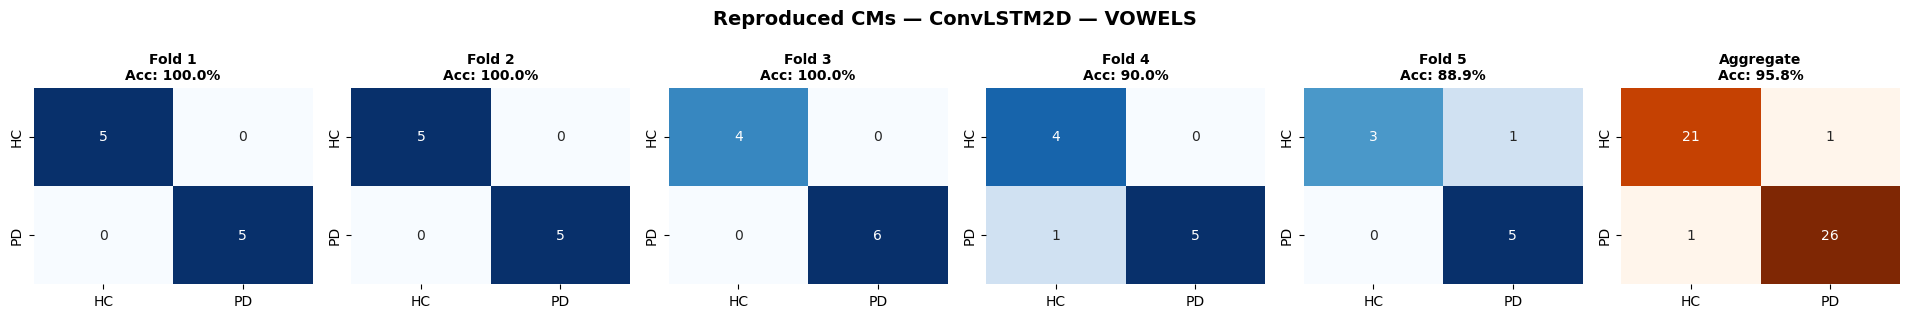


Reproducing ViT — VOWELS
  Loading subjects (target_sounds={'u', 'e', 'i', 'o', 'a'}, expected=10)...
  Found 49 subjects (HC=22, PD=27); excluded=16
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 |

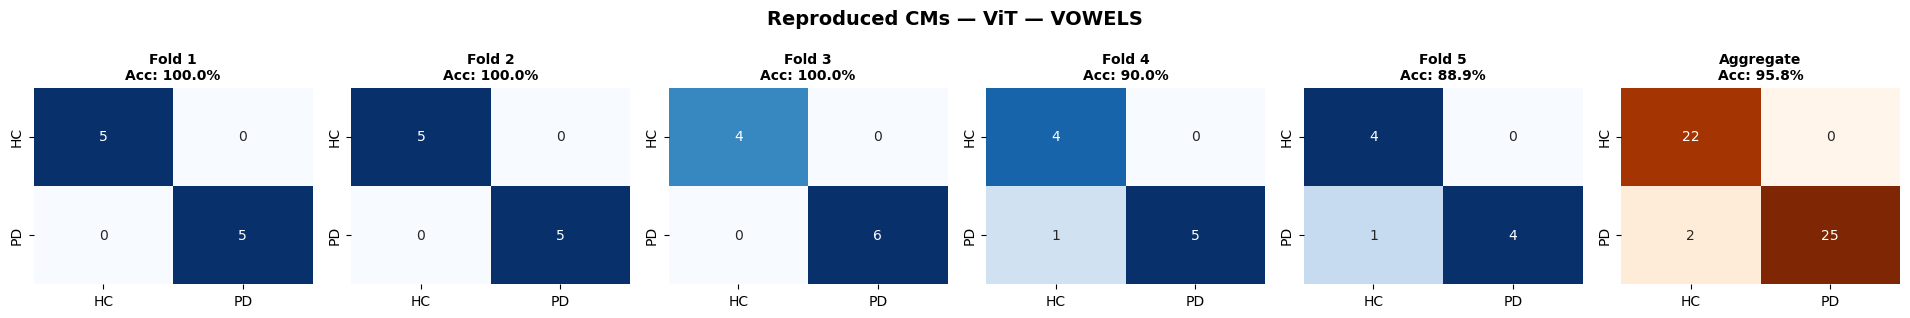


Reproducing FlipFlop2D — VOWELS
  Loading subjects (target_sounds={'u', 'e', 'i', 'o', 'a'}, expected=10)...
  Found 49 subjects (HC=22, PD=27); excluded=16
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=90.0%  Prec=83.3%  Rec=100.0%  F1=90.9%
  CM:           HC    PD
        HC      4     1
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=

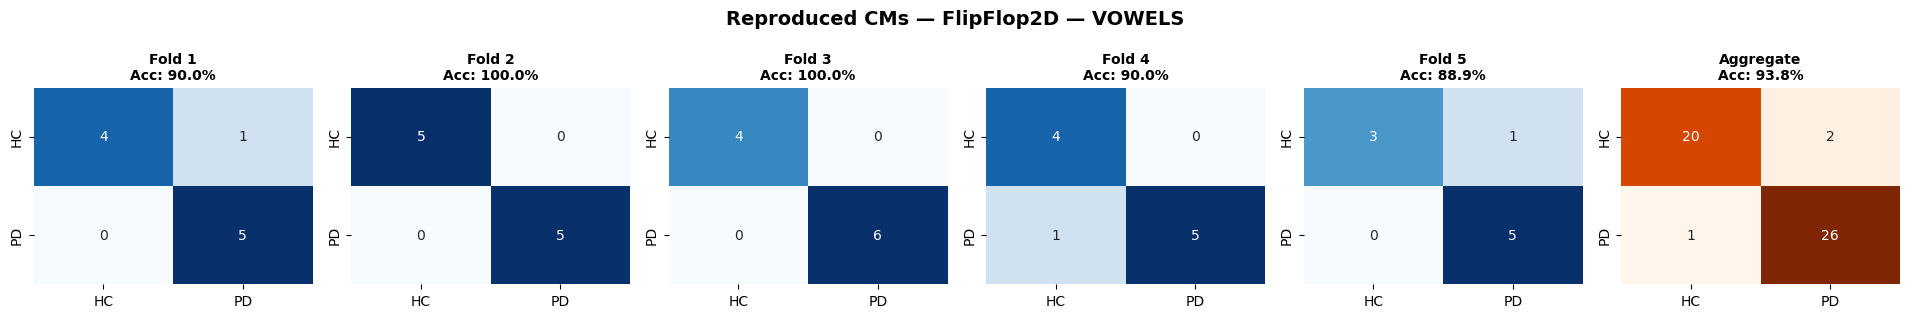


Reproducing ConvLSTM2D — PA
  Loading subjects (target_sounds={'pa'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=

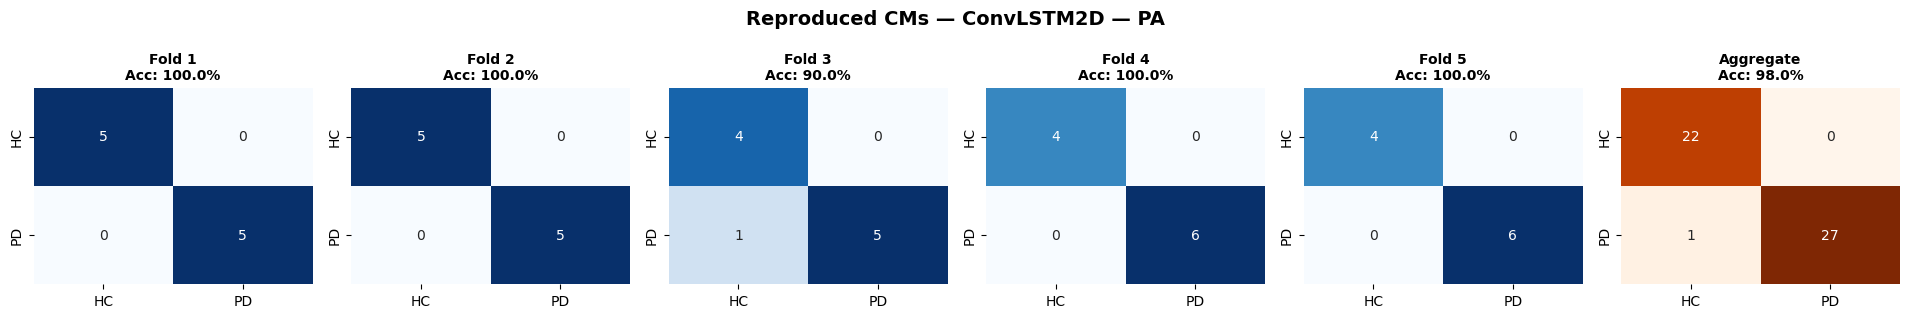


Reproducing ViT — PA
  Loading subjects (target_sounds={'pa'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=85.7%  

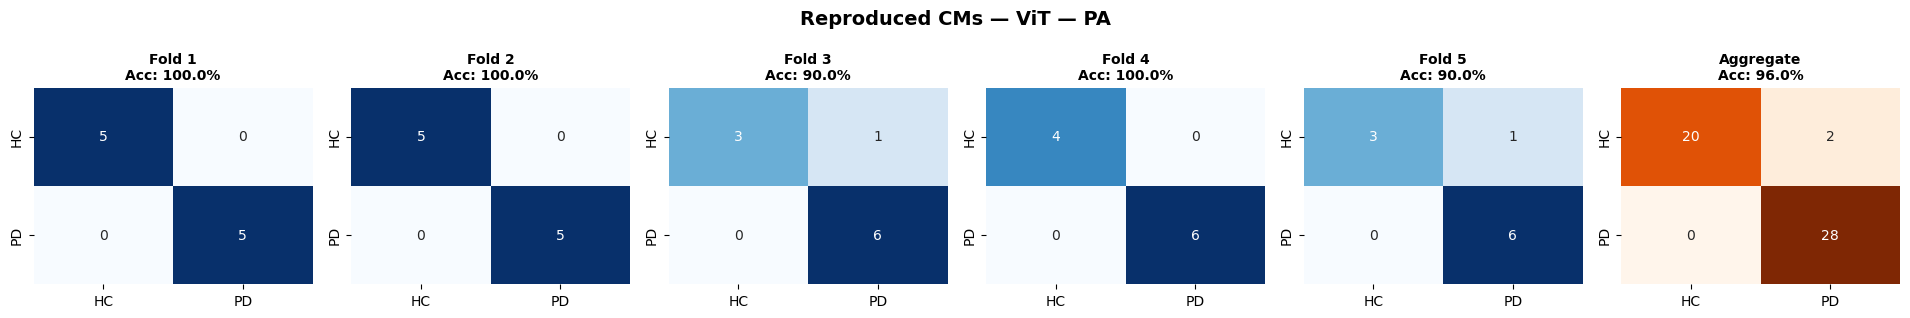


Reproducing FlipFlop2D — PA
  Loading subjects (target_sounds={'pa'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=80.0%  Prec=

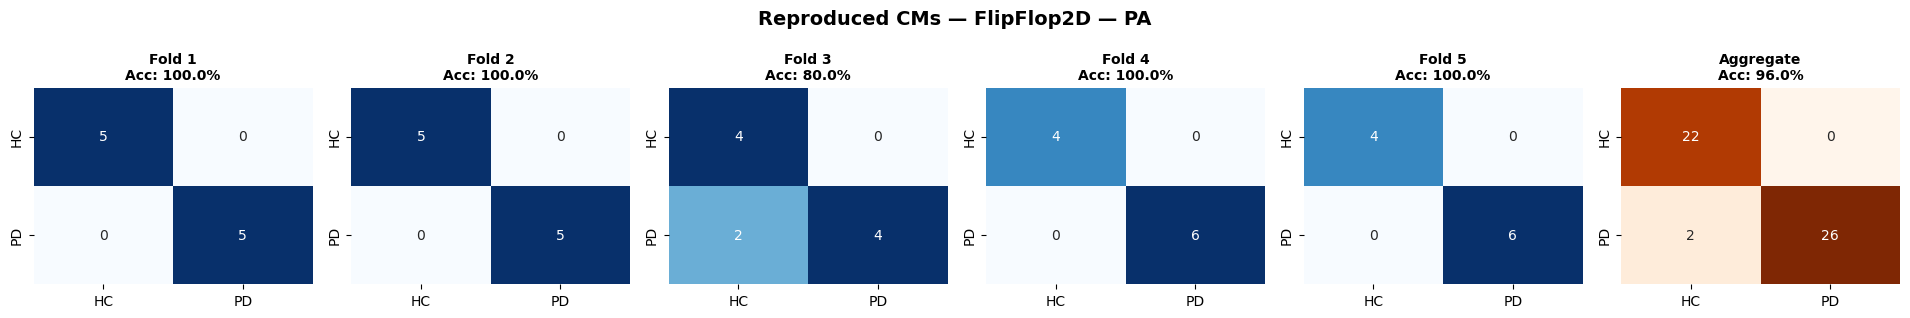


Reproducing ConvLSTM2D — TA
  Loading subjects (target_sounds={'ta'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=

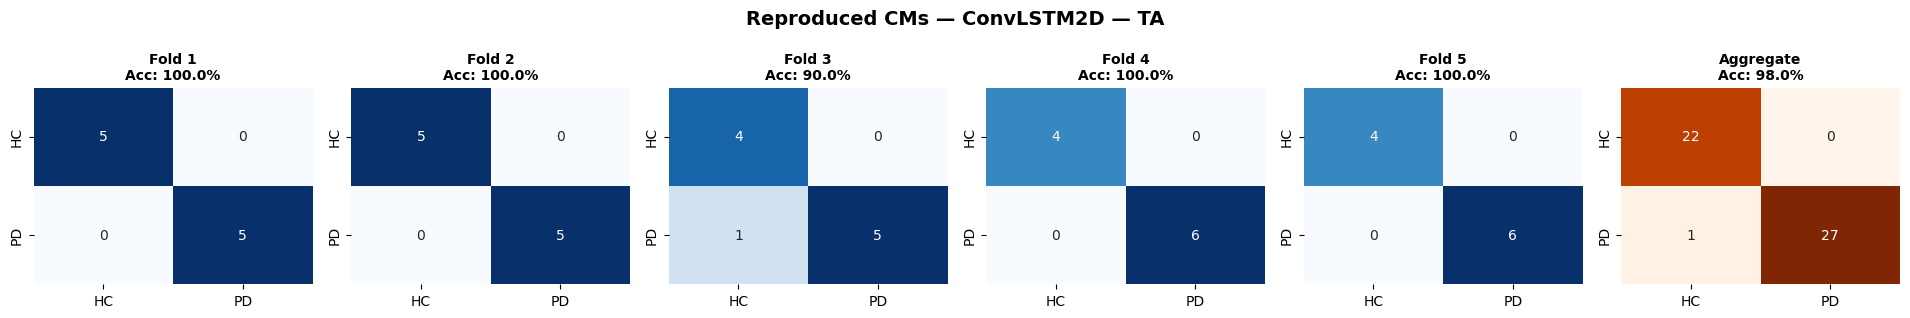


Reproducing ViT — TA
  Loading subjects (target_sounds={'ta'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=90.0%  Prec=83.3%  Rec=100.0%  F1=90.9%
  CM:           HC    PD
        HC      4     1
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=100.0%  Re

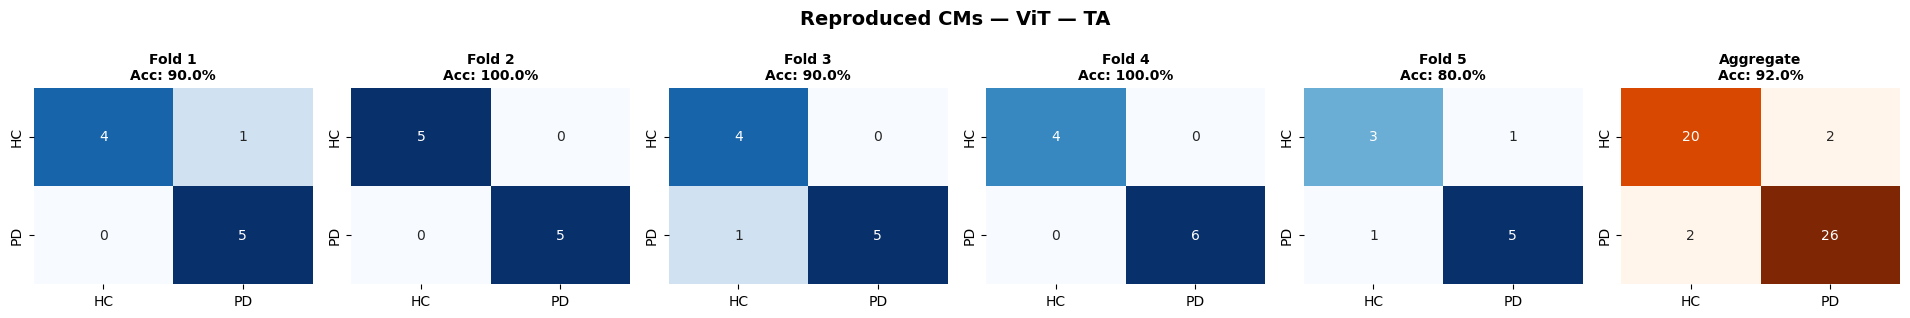


Reproducing FlipFlop2D — TA
  Loading subjects (target_sounds={'ta'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=70.0%  Prec=62.5%  Rec=100.0%  F1=76.9%
  CM:           HC    PD
        HC      2     3
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=60.0%  Prec=60.0%  Rec=60.0%  F1=60.0%
  CM:           HC    PD
        HC      3     2
        PD      2     3
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=100.0% 

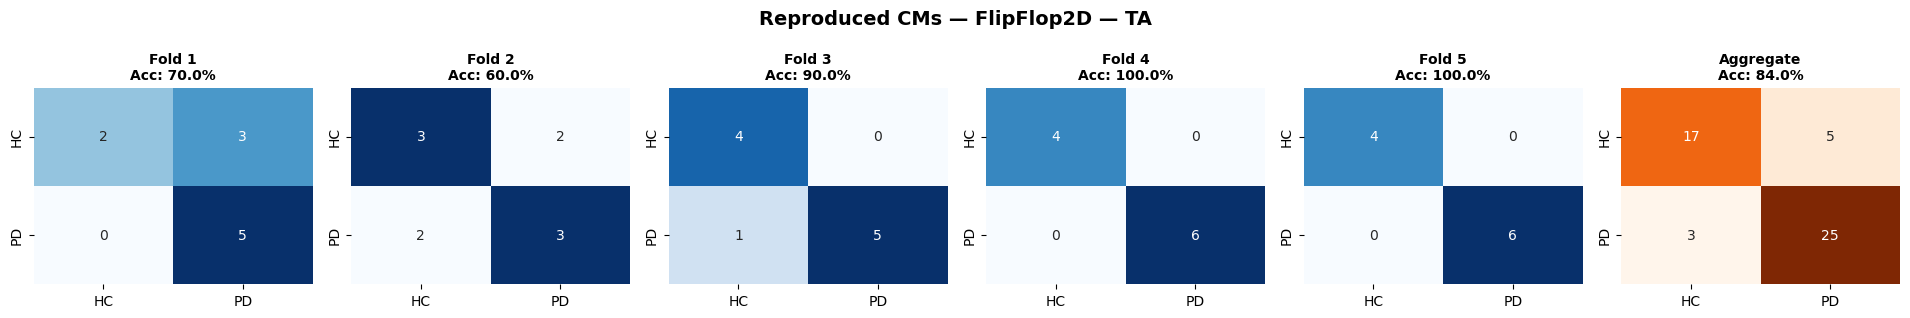



GRAND COMPARISON (Reproduced) — Subject-Level Classification
  Sound      Model             Mean Acc    Std Acc    Mean F1     Std F1
  -----------------------------------------------------------------
  vowels     ConvLSTM2D           95.8%       5.2%      96.4%       4.5%
  vowels     ViT                  95.8%       5.2%      96.0%       5.0%
  vowels     FlipFlop2D           93.8%       5.1%      94.5%       4.5%
  -----------------------------------------------------------------
  pa         ConvLSTM2D           98.0%       4.0%      98.2%       3.6%
  pa         ViT                  96.0%       4.9%      96.9%       3.8%
  pa         FlipFlop2D           96.0%       8.0%      96.0%       8.0%
  -----------------------------------------------------------------
  ta         ConvLSTM2D           98.0%       4.0%      98.2%       3.6%
  ta         ViT                  92.0%       7.5%      93.0%       6.3%
  ta         FlipFlop2D           84.0%      16.2%      85.6%      15.3%
  -

In [2]:
# ============================================================
# Reproduce Speech PD — SUBJECT-LEVEL Classification Results
# Reads a saved model folder and reproduces all 5-fold metrics
# + confusion matrices from saved checkpoints.
#
# Standalone — no dependency on the training script.
#
# Usage:
#   1. Set MODEL_FOLDER below to your saved drive path
#   2. Set ITALIAN_PATH to the same audio path used at training time
#      (we need to re-extract spectrograms for the val subjects)
#   3. Run.
#
# Folder structure expected (matches training script):
#   MODEL_FOLDER/
#     ConvLSTM2D/
#       vowels/
#         fold1_best.pth
#         fold1_val_indices.npy
#         fold1_val_subjects.txt
#         ... (folds 2–5)
#       pa/   ... ta/   ...
#     ViT/        ... (same)
#     FlipFlop2D/ ... (same)
# ============================================================

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import cv2
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — edit these
# ============================================================
MODEL_FOLDER = Path("speech_subject_models")              # ← your saved drive path
ITALIAN_PATH = r"Italian Parkinson's Voice and speech"    # ← same as training
MODEL_TYPES  = ['ConvLSTM2D', 'ViT', 'FlipFlop2D']
SOUND_GROUPS_TO_RUN = ['vowels', 'pa', 'ta']

N_FOLDS    = 5
BATCH_SIZE = 4
SR         = 16000
N_TIME     = 32
N_FREQ     = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SOUND_GROUPS = {
    'vowels': {'sounds': {'a', 'e', 'i', 'o', 'u'}, 'expected_specs': 10},
    'pa':     {'sounds': {'pa'},                     'expected_specs': 1},
    'ta':     {'sounds': {'ta'},                     'expected_specs': 1},
}

print(f"Device       : {DEVICE}")
print(f"Model folder : {MODEL_FOLDER.resolve()}")
print(f"Audio folder : {Path(ITALIAN_PATH).resolve()}")

# ============================================================
# DATA LOADING — must match training pipeline EXACTLY
# ============================================================
def get_sound_type(filename):
    f = filename.upper()
    if f.startswith('VA1') or f.startswith('VA2'): return 'a'
    if f.startswith('VE1') or f.startswith('VE2'): return 'e'
    if f.startswith('VI1') or f.startswith('VI2'): return 'i'
    if f.startswith('VO1') or f.startswith('VO2'): return 'o'
    if f.startswith('VU1') or f.startswith('VU2'): return 'u'
    if f.startswith('D1'): return 'pa'
    if f.startswith('D2'): return 'ta'
    return None


def find_subject_folders(folder_path):
    subjects = []
    for item in folder_path.iterdir():
        if not item.is_dir():
            continue
        if list(item.glob('*.wav')) + list(item.glob('*.WAV')):
            subjects.append(item)
        else:
            for sub in item.iterdir():
                if sub.is_dir() and (list(sub.glob('*.wav')) + list(sub.glob('*.WAV'))):
                    subjects.append(sub)
    return subjects


def extract_melspectrogram(wav_path, sr=SR, n_mels=128, max_sec=5):
    try:
        y, _ = librosa.load(wav_path, sr=sr)
        y, _ = librosa.effects.trim(y, top_db=20)

        if len(y) < sr * 0.1:
            return None
        if not np.isfinite(y).all():
            return None

        max_samples = sr * max_sec
        if len(y) < max_samples:
            y = np.pad(y, (0, max_samples - len(y)))
        else:
            y = y[:max_samples]

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=512, hop_length=256
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        mel_resized = cv2.resize(mel_db, (N_TIME, N_FREQ))
        return mel_resized.T.astype(np.float32)

    except Exception:
        return None


def load_subject_data(base_path, target_sounds, expected_specs):
    base_path = Path(base_path)
    folders = {
        '15 Young Healthy Control':           0,
        '22 Elderly Healthy Control':         0,
        "28 People with Parkinson's disease": 1,
    }

    subjects, excluded = [], []
    seen_dirs = set()

    for folder_name, label in folders.items():
        folder_path = base_path / folder_name
        if not folder_path.exists():
            print(f"  [WARN] Missing folder: {folder_path}")
            continue

        for subj_dir in find_subject_folders(folder_path):
            key = str(subj_dir.resolve())
            if key in seen_dirs:
                continue
            seen_dirs.add(key)

            wavs = list(subj_dir.glob('*.wav')) + list(subj_dir.glob('*.WAV'))
            specs, tags = [], []
            processed_files = set()

            for wav in wavs:
                wav_key = str(wav.resolve())
                if wav_key in processed_files:
                    continue
                processed_files.add(wav_key)

                sound = get_sound_type(wav.name)
                if sound not in target_sounds:
                    continue

                spec = extract_melspectrogram(str(wav))
                if spec is not None:
                    specs.append(spec)
                    tags.append(sound)

            if len(specs) != expected_specs:
                excluded.append({'name': subj_dir.name, 'label': label})
                continue

            subjects.append({
                'name':       subj_dir.name,
                'label':      label,
                'specs':      np.stack(specs),
                'sound_tags': tags,
                'group':      folder_name,
            })

    return subjects, excluded


# ============================================================
# DATASET
# ============================================================
class SubjectBagDataset(Dataset):
    def __init__(self, subjects_list):
        self.subjects = subjects_list

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subj = self.subjects[idx]
        specs = subj['specs'].copy()
        label = subj['label']

        mean = specs.mean(axis=(1, 2), keepdims=True)
        std  = specs.std(axis=(1, 2), keepdims=True) + 1e-8
        specs = (specs - mean) / std

        return torch.FloatTensor(specs), torch.LongTensor([label])


# ============================================================
# MODELS — must match training architecture exactly
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2DEncoder(nn.Module):
    def __init__(self, hid1=32, hid2=16):
        super().__init__()
        self.hid1 = hid1
        self.hid2 = hid2
        self.cell1 = ConvLSTMCell(1, hid1)
        self.drop1 = nn.Dropout(0.3)
        self.cell2 = ConvLSTMCell(hid1, hid2)
        self.drop2 = nn.Dropout(0.3)

    def forward(self, x):
        B, T, F = x.shape
        h1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        c1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        h2 = torch.zeros(B, self.hid2, F, 1, device=x.device)
        c2 = torch.zeros(B, self.hid2, F, 1, device=x.device)

        for t in range(T):
            xt = x[:, t, :].unsqueeze(1).unsqueeze(-1)
            h1, c1 = self.cell1(xt, h1, c1)
            h1_d = self.drop1(h1)
            h2, c2 = self.cell2(h1_d, h2, c2)

        return self.drop2(h2).view(B, -1)


class ConvLSTMSubjectModel(nn.Module):
    def __init__(self, n_specs):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = ConvLSTM2DEncoder(hid1=32, hid2=16)
        feat_dim = 16 * N_FREQ
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)
        self.proj      = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList(
            [TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)]
        )
        self.norm = nn.LayerNorm(dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x[:, 0])


class ViTSubjectModel(nn.Module):
    def __init__(self, n_specs, dim=64):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = ViTEncoder(dim=dim)
        self.head    = nn.Sequential(
            nn.Linear(dim, 32), nn.ReLU(),
            nn.Dropout(0.1), nn.Linear(32, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.conv_xj = nn.Conv2d(in_ch, hid_ch, ks, padding=ks // 2)
        self.conv_hj = nn.Conv2d(hid_ch, hid_ch, ks, padding=ks // 2)
        self.conv_xk = nn.Conv2d(in_ch, hid_ch, ks, padding=ks // 2)
        self.conv_hk = nn.Conv2d(hid_ch, hid_ch, ks, padding=ks // 2)

    def forward(self, x, h):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h))
        return (1 - h) * j + (1 - k) * h


class FlipFlop2DEncoder(nn.Module):
    def __init__(self, hid1=64, hid2=32):
        super().__init__()
        self.hid1 = hid1
        self.hid2 = hid2
        self.cell1 = FlipFlopCell2D(1, hid1)
        self.drop1 = nn.Dropout(0.15)
        self.cell2 = FlipFlopCell2D(hid1, hid2)
        self.drop2 = nn.Dropout(0.15)

    def forward(self, x):
        B, T, F = x.shape
        h1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        h2 = torch.zeros(B, self.hid2, F, 1, device=x.device)
        for t in range(T):
            xt = x[:, t, :].unsqueeze(1).unsqueeze(-1)
            h1 = self.cell1(xt, h1)
            h1_d = self.drop1(h1)
            h2 = self.cell2(h1_d, h2)
        return self.drop2(h2).view(B, -1)


class FlipFlopSubjectModel(nn.Module):
    def __init__(self, n_specs):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = FlipFlop2DEncoder(hid1=64, hid2=32)
        feat_dim = 32 * N_FREQ
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(),
            nn.Dropout(0.15), nn.Linear(64, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


MODEL_REGISTRY = {
    'ConvLSTM2D': ConvLSTMSubjectModel,
    'ViT':        ViTSubjectModel,
    'FlipFlop2D': FlipFlopSubjectModel,
}


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_fold(model_name, sound_group, fold_idx, subjects, expected_specs):
    """
    Reproduce one fold:
      - load val_indices.npy → slice the subjects list
      - load fold{k}_best.pth → run inference
    Returns (preds, labels)
    """
    model_dir = MODEL_FOLDER / model_name / sound_group
    fold_num  = fold_idx + 1

    idx_path  = model_dir / f"fold{fold_num}_val_indices.npy"
    ckpt_path = model_dir / f"fold{fold_num}_best.pth"

    if not idx_path.exists():
        raise FileNotFoundError(f"Missing {idx_path}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing {ckpt_path}")

    val_idx   = np.load(idx_path)
    val_subjs = [subjects[i] for i in val_idx]

    # Sanity: cross-check against fold{k}_val_subjects.txt names
    txt_path = model_dir / f"fold{fold_num}_val_subjects.txt"
    if txt_path.exists():
        saved_names = []
        with open(txt_path) as f:
            for line in f:
                saved_names.append(line.split()[0])
        loaded_names = [s['name'] for s in val_subjs]
        if saved_names != loaded_names:
            print(f"  [WARN] Fold {fold_num}: subject-name mismatch vs val_subjects.txt")
            print(f"         saved : {saved_names[:3]}...")
            print(f"         loaded: {loaded_names[:3]}...")

    loader = DataLoader(SubjectBagDataset(val_subjs), batch_size=BATCH_SIZE, shuffle=False)

    model_cls = MODEL_REGISTRY[model_name]
    model     = model_cls(expected_specs).to(DEVICE)
    state     = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for bag, label in loader:
            bag = bag.to(DEVICE)
            label = label.squeeze(1).to(DEVICE)
            out = model(bag)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)


def reproduce_experiment(model_name, sound_group):
    """Reproduce all 5 folds for a given (model, sound) combination."""
    print(f"\n{'='*65}")
    print(f"Reproducing {model_name} — {sound_group.upper()}")
    print(f"{'='*65}")

    cfg            = SOUND_GROUPS[sound_group]
    expected_specs = cfg['expected_specs']

    # Re-extract spectrograms (deterministic given librosa+cv2)
    print(f"  Loading subjects (target_sounds={cfg['sounds']}, expected={expected_specs})...")
    subjects, excluded = load_subject_data(ITALIAN_PATH, cfg['sounds'], expected_specs)
    labels = np.array([s['label'] for s in subjects])
    print(f"  Found {len(subjects)} subjects (HC={(labels==0).sum()}, "
          f"PD={(labels==1).sum()}); excluded={len(excluded)}")

    fold_metrics, all_preds, all_labels = [], [], []

    for fold in range(N_FOLDS):
        preds, lbls = reproduce_fold(model_name, sound_group, fold,
                                     subjects, expected_specs)

        acc  = accuracy_score(lbls, preds)
        prec = precision_score(lbls, preds, zero_division=0)
        rec  = recall_score(lbls, preds, zero_division=0)
        f1   = f1_score(lbls, preds, zero_division=0)
        fold_metrics.append({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
        all_preds.extend(preds)
        all_labels.extend(lbls)

        cm = confusion_matrix(lbls, preds)
        print(f"\n  --- Fold {fold+1} ---")
        print(f"  N_val={len(lbls)} | Acc={acc*100:.1f}%  "
              f"Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  F1={f1*100:.1f}%")
        print(f"  CM:           HC    PD")
        print(f"        HC   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"        PD   {cm[1,0]:4d}  {cm[1,1]:4d}")

    return {
        'metrics':    fold_metrics,
        'all_preds':  np.array(all_preds),
        'all_labels': np.array(all_labels),
        'subjects':   subjects,
    }


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(results, model_name, sound_group):
    print(f"\n{'='*55}")
    print(f"Reproduction Summary — {model_name} — {sound_group.upper()}")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")
    accs = [m['acc']  for m in results['metrics']]
    pres = [m['prec'] for m in results['metrics']]
    recs = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(pres)*100:>7.1f}% "
          f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(pres)*100:>7.1f}%  "
          f"{np.std(recs)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(results, model_name, sound_group, save_dir=None):
    fig, axes = plt.subplots(1, N_FOLDS + 1, figsize=(3.2 * (N_FOLDS + 1), 3.2))
    fig.suptitle(f'Reproduced CMs — {model_name} — {sound_group.upper()}',
                 fontsize=14, fontweight='bold')

    start = 0
    for fold in range(N_FOLDS):
        idx = np.load(MODEL_FOLDER / model_name / sound_group / f"fold{fold+1}_val_indices.npy")
        end = start + len(idx)
        cm = confusion_matrix(results['all_labels'][start:end],
                              results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[fold],
                    cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        axes[fold].set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                             fontsize=10, fontweight='bold')
        start = end

    cm_all  = confusion_matrix(results['all_labels'], results['all_preds'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=10, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"{model_name}_{sound_group}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    grand = {}

    for sg in SOUND_GROUPS_TO_RUN:
        for mt in MODEL_TYPES:
            try:
                results = reproduce_experiment(mt, sg)
                print_summary(results, mt, sg)
                plot_confusion_matrices(results, mt, sg, save_dir=MODEL_FOLDER)
                grand[(sg, mt)] = results
            except FileNotFoundError as e:
                print(f"\n[SKIP] {mt} / {sg}: {e}")

    # Grand comparison table
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON (Reproduced) — Subject-Level Classification")
    print(f"{'='*75}")
    print(f"  {'Sound':<10} {'Model':<15} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*65}")
    for sg in SOUND_GROUPS_TO_RUN:
        for mt in MODEL_TYPES:
            if (sg, mt) not in grand:
                continue
            res  = grand[(sg, mt)]
            accs = [m['acc'] for m in res['metrics']]
            f1s  = [m['f1']  for m in res['metrics']]
            print(f"  {sg:<10} {mt:<15} "
                  f"{np.mean(accs)*100:>9.1f}% {np.std(accs)*100:>9.1f}% "
                  f"{np.mean(f1s)*100:>9.1f}% {np.std(f1s)*100:>9.1f}%")
        print(f"  {'-'*65}")

Device       : cpu
Model folder : C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\speech_subject_models
Audio folder : C:\Users\nbsat\OneDrive\Documents\MS_Thesis\Speak_Analysis\Italian Parkinson's Voice and speech

Reproducing ConvLSTM2D — VOWELS
  Loading subjects (target_sounds={'u', 'e', 'i', 'o', 'a'}, expected=10)...
  Found 49 subjects (HC=22, PD=27); excluded=16
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC    

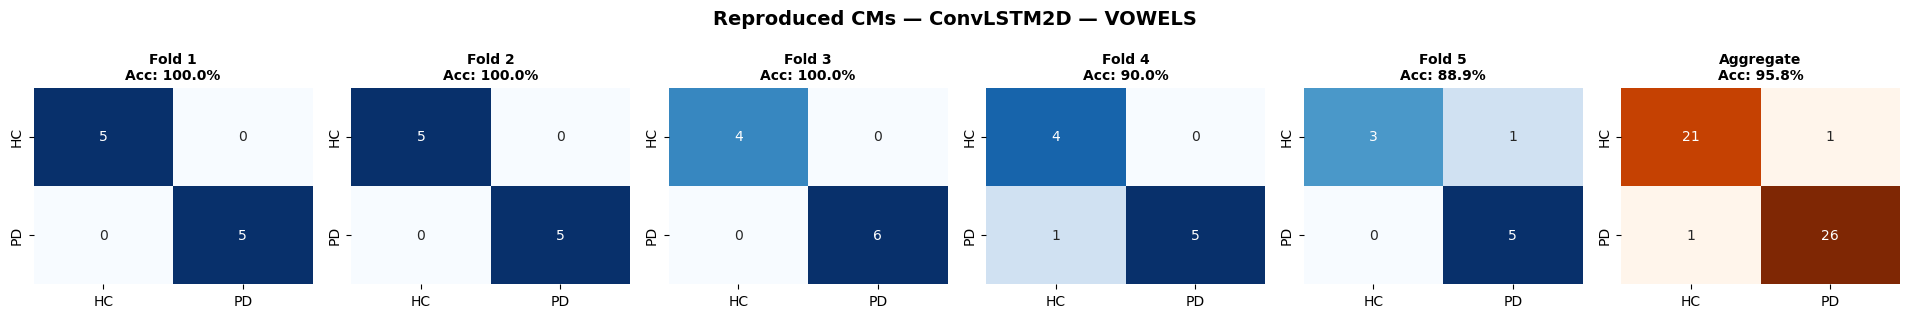


Reproducing ViT — VOWELS
  Loading subjects (target_sounds={'u', 'e', 'i', 'o', 'a'}, expected=10)...
  Found 49 subjects (HC=22, PD=27); excluded=16
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 |

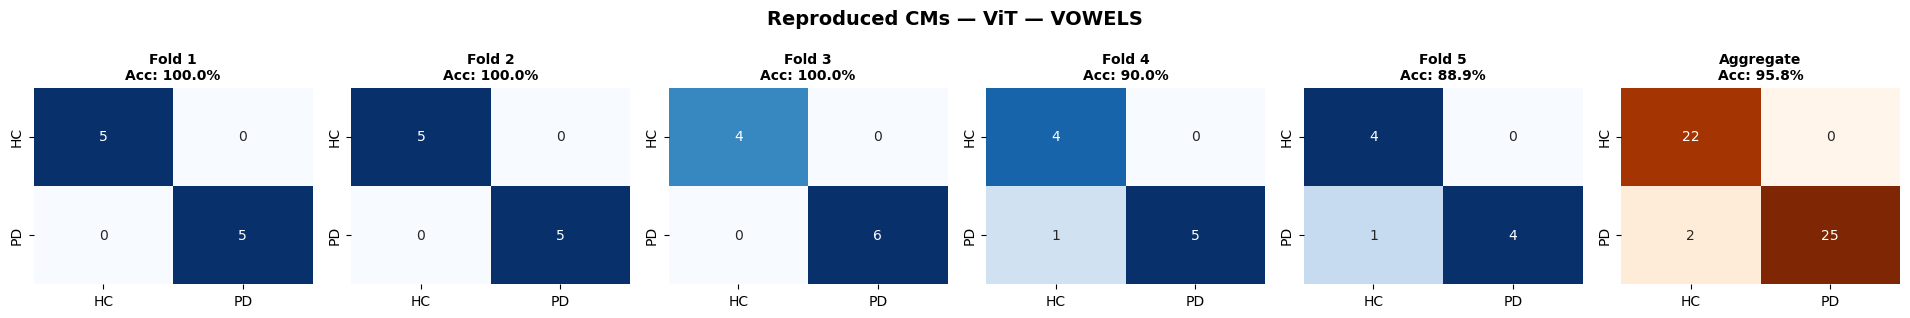


Reproducing FlipFlop2D — VOWELS
  Loading subjects (target_sounds={'u', 'e', 'i', 'o', 'a'}, expected=10)...
  Found 49 subjects (HC=22, PD=27); excluded=16
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=90.0%  Prec=83.3%  Rec=100.0%  F1=90.9%
  CM:           HC    PD
        HC      4     1
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=

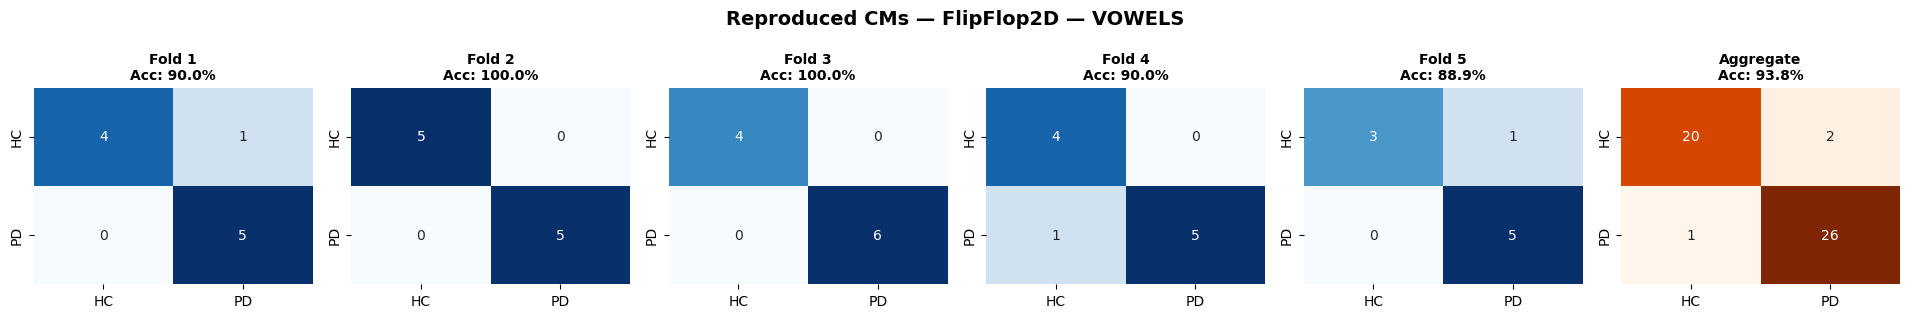


Reproducing ConvLSTM2D — PA
  Loading subjects (target_sounds={'pa'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=

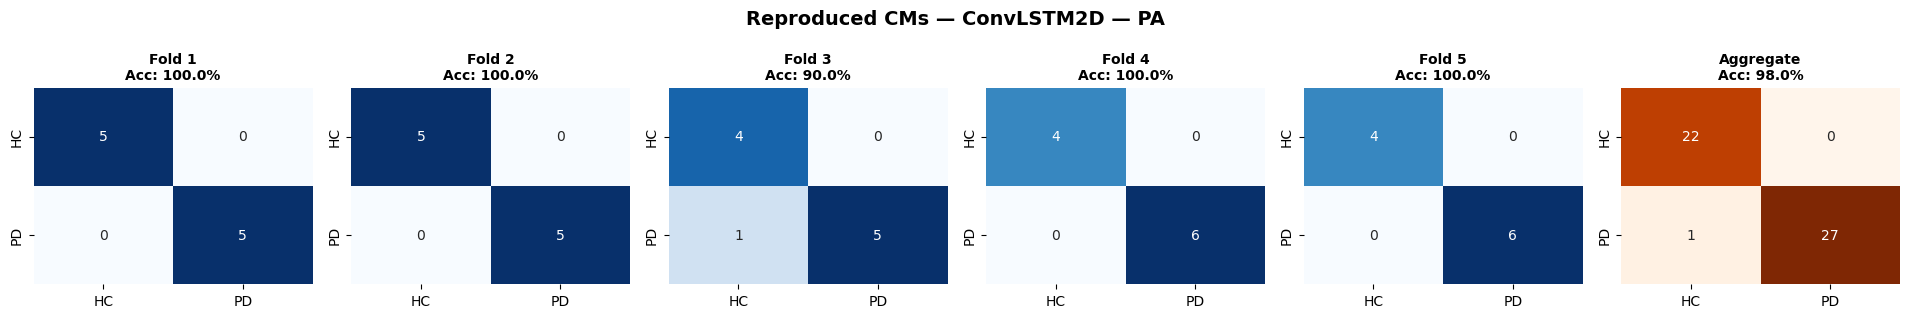


Reproducing ViT — PA
  Loading subjects (target_sounds={'pa'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=85.7%  

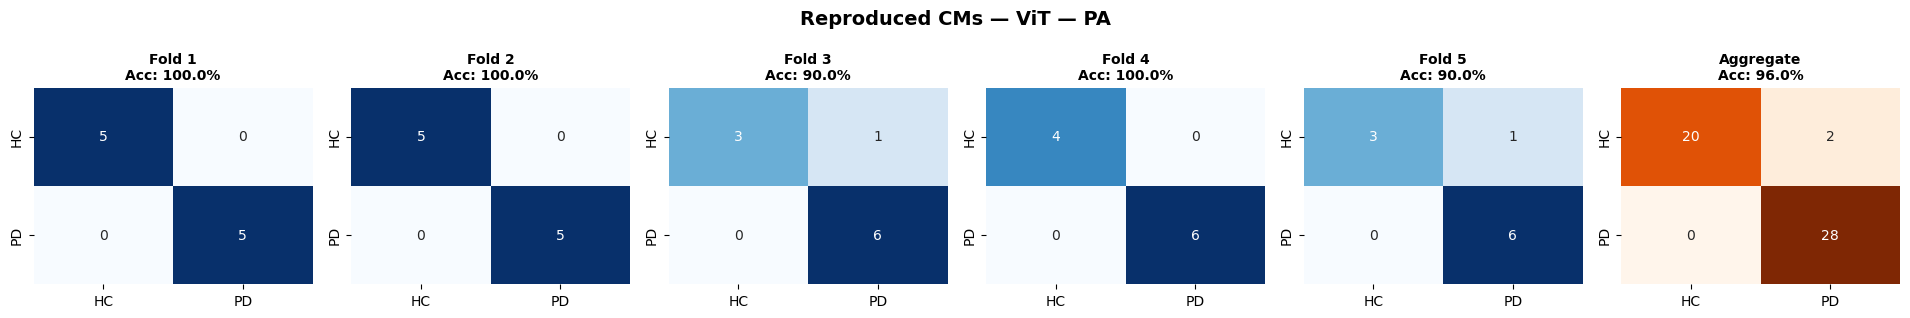


Reproducing FlipFlop2D — PA
  Loading subjects (target_sounds={'pa'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=80.0%  Prec=

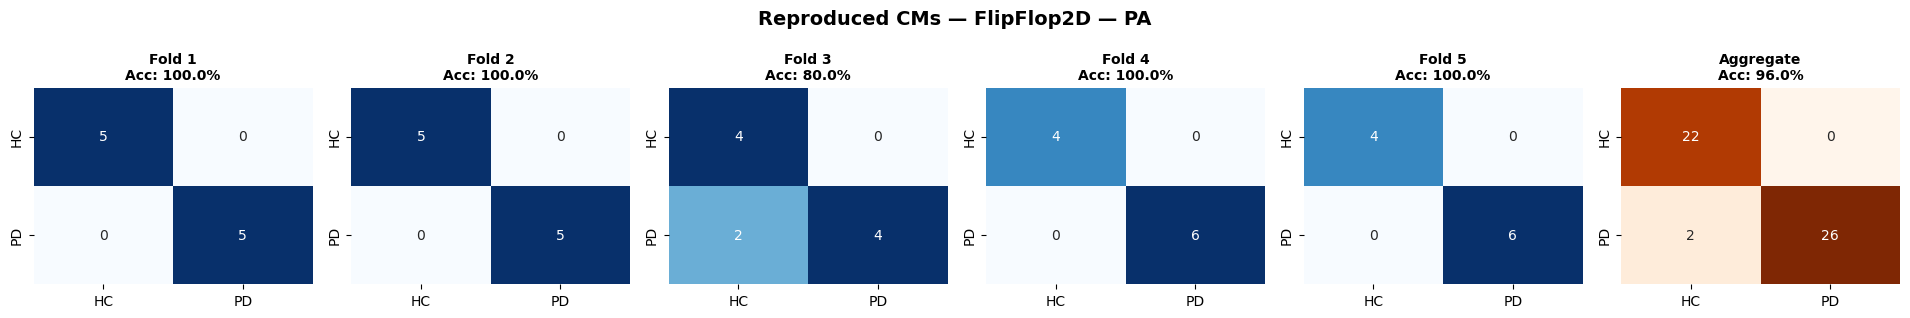


Reproducing ConvLSTM2D — TA
  Loading subjects (target_sounds={'ta'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=

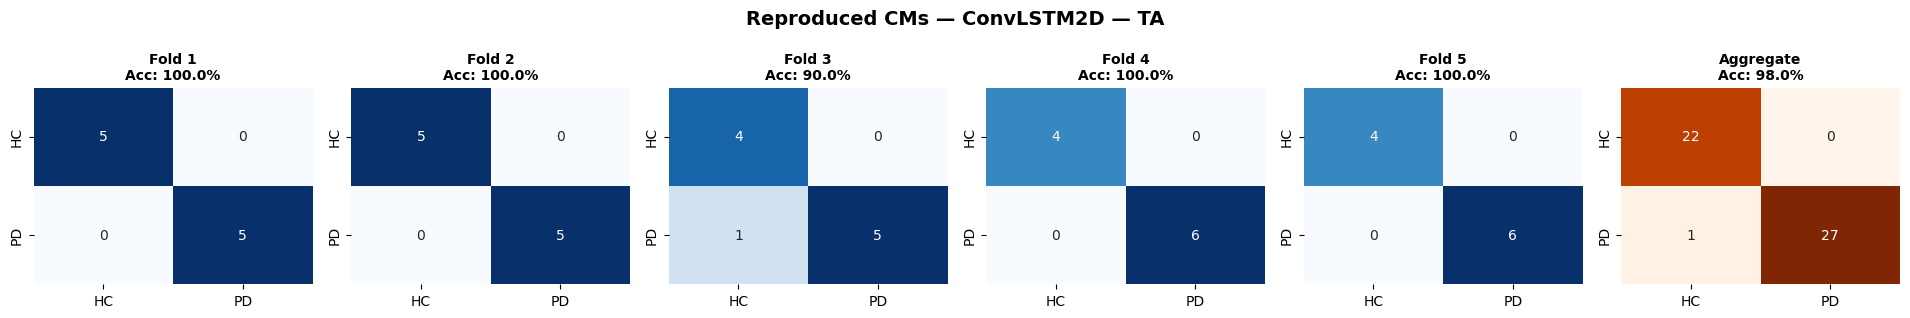


Reproducing ViT — TA
  Loading subjects (target_sounds={'ta'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=90.0%  Prec=83.3%  Rec=100.0%  F1=90.9%
  CM:           HC    PD
        HC      4     1
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     5
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=100.0%  Re

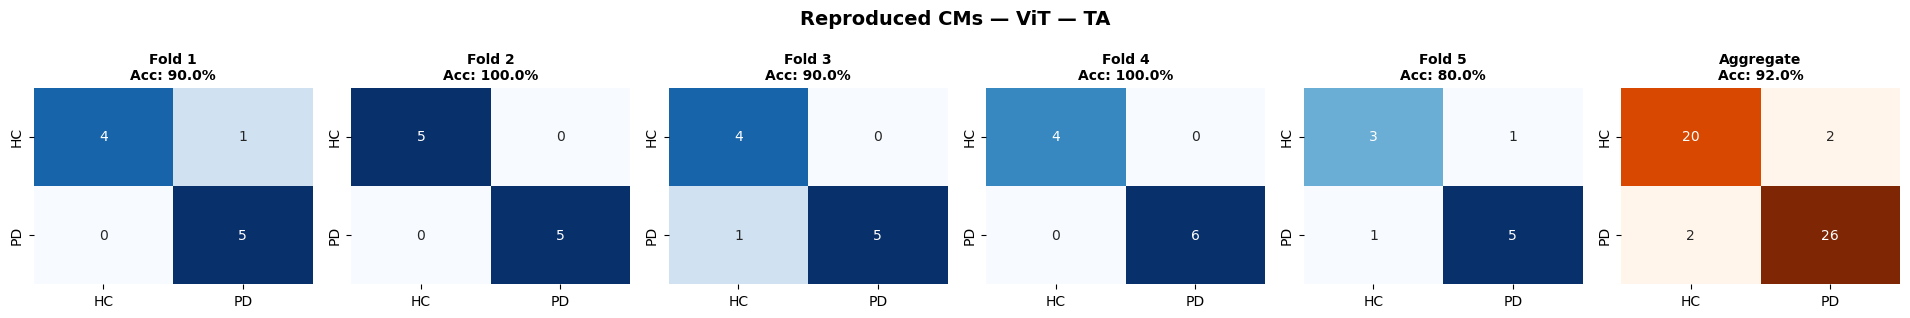


Reproducing FlipFlop2D — TA
  Loading subjects (target_sounds={'ta'}, expected=1)...
  Found 50 subjects (HC=22, PD=28); excluded=15
  [WARN] Fold 1: subject-name mismatch vs val_subjects.txt
         saved : ['AGNESE', 'ANTONIETTA', 'GIOVANNI']...
         loaded: ['AGNESE P', 'ANTONIETTA P', 'GIOVANNI B']...

  --- Fold 1 ---
  N_val=10 | Acc=70.0%  Prec=62.5%  Rec=100.0%  F1=76.9%
  CM:           HC    PD
        HC      2     3
        PD      0     5
  [WARN] Fold 2: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'BRIGIDA', 'NICOLA']...
         loaded: ['ANGELA G', 'BRIGIDA C', 'NICOLA P']...

  --- Fold 2 ---
  N_val=10 | Acc=60.0%  Prec=60.0%  Rec=60.0%  F1=60.0%
  CM:           HC    PD
        HC      3     2
        PD      2     3
  [WARN] Fold 3: subject-name mismatch vs val_subjects.txt
         saved : ['ANGELA', 'GIOVANNA', 'LISCO']...
         loaded: ['ANGELA C', 'GIOVANNA G', 'LISCO G']...

  --- Fold 3 ---
  N_val=10 | Acc=90.0%  Prec=100.0% 

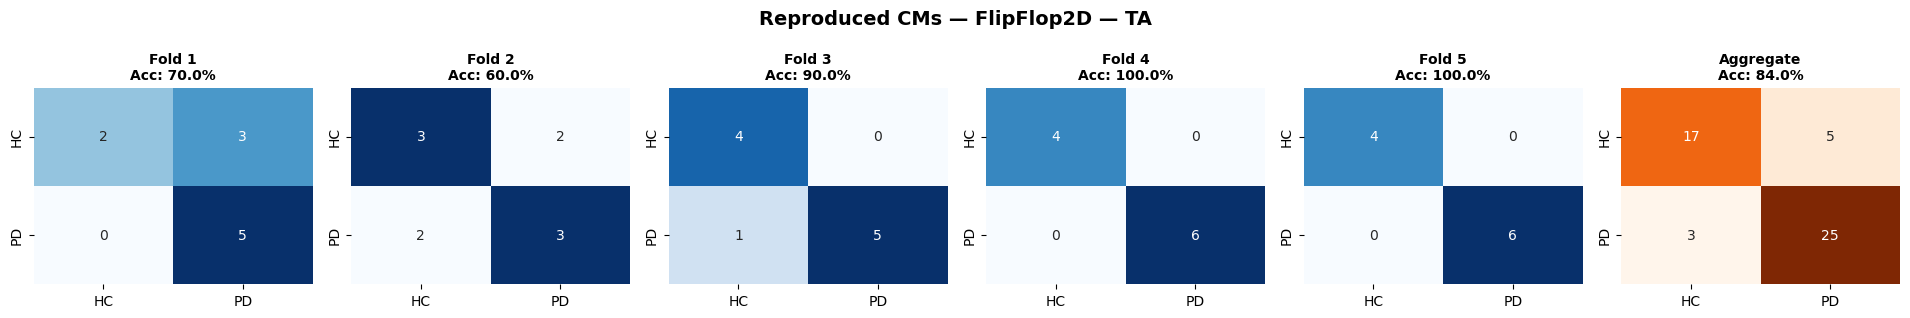



GRAND COMPARISON (Reproduced) — Subject-Level Classification
  Sound      Model             Mean Acc    Std Acc    Mean F1     Std F1
  -----------------------------------------------------------------
  vowels     ConvLSTM2D           95.8%       5.2%      96.4%       4.5%
  vowels     ViT                  95.8%       5.2%      96.0%       5.0%
  vowels     FlipFlop2D           93.8%       5.1%      94.5%       4.5%
  -----------------------------------------------------------------
  pa         ConvLSTM2D           98.0%       4.0%      98.2%       3.6%
  pa         ViT                  96.0%       4.9%      96.9%       3.8%
  pa         FlipFlop2D           96.0%       8.0%      96.0%       8.0%
  -----------------------------------------------------------------
  ta         ConvLSTM2D           98.0%       4.0%      98.2%       3.6%
  ta         ViT                  92.0%       7.5%      93.0%       6.3%
  ta         FlipFlop2D           84.0%      16.2%      85.6%      15.3%
  -

In [ ]:
# ============================================================
# Reproduce Speech PD — SUBJECT-LEVEL Classification Results
# Reads a saved model folder and reproduces all 5-fold metrics
# + confusion matrices from saved checkpoints.
#
# Standalone — no dependency on the training script.
#
# Usage:
#   1. Set MODEL_FOLDER below to your saved drive path
#   2. Set ITALIAN_PATH to the same audio path used at training time
#      (we need to re-extract spectrograms for the val subjects)
#   3. Run.
#
# Folder structure expected (matches training script):
#   MODEL_FOLDER/
#     ConvLSTM2D/
#       vowels/
#         fold1_best.pth
#         fold1_val_indices.npy
#         fold1_val_subjects.txt
#         ... (folds 2–5)
#       pa/   ... ta/   ...
#     ViT/        ... (same)
#     FlipFlop2D/ ... (same)
# ============================================================

import numpy as np
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import cv2
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — edit these
# ============================================================
MODEL_FOLDER = Path("speech_subject_models")              # ← your saved drive path
ITALIAN_PATH = r"Italian Parkinson's Voice and speech"    # ← same as training
MODEL_TYPES  = ['ConvLSTM2D', 'ViT', 'FlipFlop2D']
SOUND_GROUPS_TO_RUN = ['vowels', 'pa', 'ta']

N_FOLDS    = 5
BATCH_SIZE = 4
SR         = 16000
N_TIME     = 32
N_FREQ     = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SOUND_GROUPS = {
    'vowels': {'sounds': {'a', 'e', 'i', 'o', 'u'}, 'expected_specs': 10},
    'pa':     {'sounds': {'pa'},                     'expected_specs': 1},
    'ta':     {'sounds': {'ta'},                     'expected_specs': 1},
}

print(f"Device       : {DEVICE}")
print(f"Model folder : {MODEL_FOLDER.resolve()}")
print(f"Audio folder : {Path(ITALIAN_PATH).resolve()}")

# ============================================================
# DATA LOADING — must match training pipeline EXACTLY
# ============================================================
def get_sound_type(filename):
    f = filename.upper()
    if f.startswith('VA1') or f.startswith('VA2'): return 'a'
    if f.startswith('VE1') or f.startswith('VE2'): return 'e'
    if f.startswith('VI1') or f.startswith('VI2'): return 'i'
    if f.startswith('VO1') or f.startswith('VO2'): return 'o'
    if f.startswith('VU1') or f.startswith('VU2'): return 'u'
    if f.startswith('D1'): return 'pa'
    if f.startswith('D2'): return 'ta'
    return None


def find_subject_folders(folder_path):
    subjects = []
    for item in folder_path.iterdir():
        if not item.is_dir():
            continue
        if list(item.glob('*.wav')) + list(item.glob('*.WAV')):
            subjects.append(item)
        else:
            for sub in item.iterdir():
                if sub.is_dir() and (list(sub.glob('*.wav')) + list(sub.glob('*.WAV'))):
                    subjects.append(sub)
    return subjects


def extract_melspectrogram(wav_path, sr=SR, n_mels=128, max_sec=5):
    try:
        y, _ = librosa.load(wav_path, sr=sr)
        y, _ = librosa.effects.trim(y, top_db=20)

        if len(y) < sr * 0.1:
            return None
        if not np.isfinite(y).all():
            return None

        max_samples = sr * max_sec
        if len(y) < max_samples:
            y = np.pad(y, (0, max_samples - len(y)))
        else:
            y = y[:max_samples]

        mel = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels, n_fft=512, hop_length=256
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        mel_resized = cv2.resize(mel_db, (N_TIME, N_FREQ))
        return mel_resized.T.astype(np.float32)

    except Exception:
        return None


def load_subject_data(base_path, target_sounds, expected_specs):
    base_path = Path(base_path)
    folders = {
        '15 Young Healthy Control':           0,
        '22 Elderly Healthy Control':         0,
        "28 People with Parkinson's disease": 1,
    }

    subjects, excluded = [], []
    seen_dirs = set()

    for folder_name, label in folders.items():
        folder_path = base_path / folder_name
        if not folder_path.exists():
            print(f"  [WARN] Missing folder: {folder_path}")
            continue

        for subj_dir in find_subject_folders(folder_path):
            key = str(subj_dir.resolve())
            if key in seen_dirs:
                continue
            seen_dirs.add(key)

            wavs = list(subj_dir.glob('*.wav')) + list(subj_dir.glob('*.WAV'))
            specs, tags = [], []
            processed_files = set()

            for wav in wavs:
                wav_key = str(wav.resolve())
                if wav_key in processed_files:
                    continue
                processed_files.add(wav_key)

                sound = get_sound_type(wav.name)
                if sound not in target_sounds:
                    continue

                spec = extract_melspectrogram(str(wav))
                if spec is not None:
                    specs.append(spec)
                    tags.append(sound)

            if len(specs) != expected_specs:
                excluded.append({'name': subj_dir.name, 'label': label})
                continue

            subjects.append({
                'name':       subj_dir.name,
                'label':      label,
                'specs':      np.stack(specs),
                'sound_tags': tags,
                'group':      folder_name,
            })

    return subjects, excluded


# ============================================================
# DATASET
# ============================================================
class SubjectBagDataset(Dataset):
    def __init__(self, subjects_list):
        self.subjects = subjects_list

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        subj = self.subjects[idx]
        specs = subj['specs'].copy()
        label = subj['label']

        mean = specs.mean(axis=(1, 2), keepdims=True)
        std  = specs.std(axis=(1, 2), keepdims=True) + 1e-8
        specs = (specs - mean) / std

        return torch.FloatTensor(specs), torch.LongTensor([label])


# ============================================================
# MODELS — must match training architecture exactly
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2DEncoder(nn.Module):
    def __init__(self, hid1=32, hid2=16):
        super().__init__()
        self.hid1 = hid1
        self.hid2 = hid2
        self.cell1 = ConvLSTMCell(1, hid1)
        self.drop1 = nn.Dropout(0.3)
        self.cell2 = ConvLSTMCell(hid1, hid2)
        self.drop2 = nn.Dropout(0.3)

    def forward(self, x):
        B, T, F = x.shape
        h1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        c1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        h2 = torch.zeros(B, self.hid2, F, 1, device=x.device)
        c2 = torch.zeros(B, self.hid2, F, 1, device=x.device)

        for t in range(T):
            xt = x[:, t, :].unsqueeze(1).unsqueeze(-1)
            h1, c1 = self.cell1(xt, h1, c1)
            h1_d = self.drop1(h1)
            h2, c2 = self.cell2(h1_d, h2, c2)

        return self.drop2(h2).view(B, -1)


class ConvLSTMSubjectModel(nn.Module):
    def __init__(self, n_specs):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = ConvLSTM2DEncoder(hid1=32, hid2=16)
        feat_dim = 16 * N_FREQ
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ViTEncoder(nn.Module):
    def __init__(self, img_size=(N_TIME, N_FREQ), patch_size=4,
                 dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nt, nf = img_size
        n_patches = (nt // patch_size) * (nf // patch_size)
        self.proj      = nn.Conv2d(1, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList(
            [TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)]
        )
        self.norm = nn.LayerNorm(dim)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x[:, 0])


class ViTSubjectModel(nn.Module):
    def __init__(self, n_specs, dim=64):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = ViTEncoder(dim=dim)
        self.head    = nn.Sequential(
            nn.Linear(dim, 32), nn.ReLU(),
            nn.Dropout(0.1), nn.Linear(32, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.conv_xj = nn.Conv2d(in_ch, hid_ch, ks, padding=ks // 2)
        self.conv_hj = nn.Conv2d(hid_ch, hid_ch, ks, padding=ks // 2)
        self.conv_xk = nn.Conv2d(in_ch, hid_ch, ks, padding=ks // 2)
        self.conv_hk = nn.Conv2d(hid_ch, hid_ch, ks, padding=ks // 2)

    def forward(self, x, h):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h))
        return (1 - h) * j + (1 - k) * h


class FlipFlop2DEncoder(nn.Module):
    def __init__(self, hid1=64, hid2=32):
        super().__init__()
        self.hid1 = hid1
        self.hid2 = hid2
        self.cell1 = FlipFlopCell2D(1, hid1)
        self.drop1 = nn.Dropout(0.15)
        self.cell2 = FlipFlopCell2D(hid1, hid2)
        self.drop2 = nn.Dropout(0.15)

    def forward(self, x):
        B, T, F = x.shape
        h1 = torch.zeros(B, self.hid1, F, 1, device=x.device)
        h2 = torch.zeros(B, self.hid2, F, 1, device=x.device)
        for t in range(T):
            xt = x[:, t, :].unsqueeze(1).unsqueeze(-1)
            h1 = self.cell1(xt, h1)
            h1_d = self.drop1(h1)
            h2 = self.cell2(h1_d, h2)
        return self.drop2(h2).view(B, -1)


class FlipFlopSubjectModel(nn.Module):
    def __init__(self, n_specs):
        super().__init__()
        self.n_specs = n_specs
        self.encoder = FlipFlop2DEncoder(hid1=64, hid2=32)
        feat_dim = 32 * N_FREQ
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 64), nn.ReLU(),
            nn.Dropout(0.15), nn.Linear(64, 2),
        )

    def forward(self, bag):
        B, S, T, F = bag.shape
        feats = self.encoder(bag.view(B * S, T, F))
        feats = feats.view(B, S, -1)
        pooled = feats.mean(dim=1)
        return self.head(pooled)


MODEL_REGISTRY = {
    'ConvLSTM2D': ConvLSTMSubjectModel,
    'ViT':        ViTSubjectModel,
    'FlipFlop2D': FlipFlopSubjectModel,
}


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_fold(model_name, sound_group, fold_idx, subjects, expected_specs):
    """
    Reproduce one fold:
      - load val_indices.npy → slice the subjects list
      - load fold{k}_best.pth → run inference
    Returns (preds, labels)
    """
    model_dir = MODEL_FOLDER / model_name / sound_group
    fold_num  = fold_idx + 1

    idx_path  = model_dir / f"fold{fold_num}_val_indices.npy"
    ckpt_path = model_dir / f"fold{fold_num}_best.pth"

    if not idx_path.exists():
        raise FileNotFoundError(f"Missing {idx_path}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing {ckpt_path}")

    val_idx   = np.load(idx_path)
    val_subjs = [subjects[i] for i in val_idx]

    # Sanity: cross-check against fold{k}_val_subjects.txt names
    txt_path = model_dir / f"fold{fold_num}_val_subjects.txt"
    if txt_path.exists():
        saved_names = []
        with open(txt_path) as f:
            for line in f:
                saved_names.append(line.split()[0])
        loaded_names = [s['name'] for s in val_subjs]
        if saved_names != loaded_names:
            print(f"  [WARN] Fold {fold_num}: subject-name mismatch vs val_subjects.txt")
            print(f"         saved : {saved_names[:3]}...")
            print(f"         loaded: {loaded_names[:3]}...")

    loader = DataLoader(SubjectBagDataset(val_subjs), batch_size=BATCH_SIZE, shuffle=False)

    model_cls = MODEL_REGISTRY[model_name]
    model     = model_cls(expected_specs).to(DEVICE)
    state     = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for bag, label in loader:
            bag = bag.to(DEVICE)
            label = label.squeeze(1).to(DEVICE)
            out = model(bag)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)


def reproduce_experiment(model_name, sound_group):
    """Reproduce all 5 folds for a given (model, sound) combination."""
    print(f"\n{'='*65}")
    print(f"Reproducing {model_name} — {sound_group.upper()}")
    print(f"{'='*65}")

    cfg            = SOUND_GROUPS[sound_group]
    expected_specs = cfg['expected_specs']

    # Re-extract spectrograms (deterministic given librosa+cv2)
    print(f"  Loading subjects (target_sounds={cfg['sounds']}, expected={expected_specs})...")
    subjects, excluded = load_subject_data(ITALIAN_PATH, cfg['sounds'], expected_specs)
    labels = np.array([s['label'] for s in subjects])
    print(f"  Found {len(subjects)} subjects (HC={(labels==0).sum()}, "
          f"PD={(labels==1).sum()}); excluded={len(excluded)}")

    fold_metrics, all_preds, all_labels = [], [], []

    for fold in range(N_FOLDS):
        preds, lbls = reproduce_fold(model_name, sound_group, fold,
                                     subjects, expected_specs)

        acc  = accuracy_score(lbls, preds)
        prec = precision_score(lbls, preds, zero_division=0)
        rec  = recall_score(lbls, preds, zero_division=0)
        f1   = f1_score(lbls, preds, zero_division=0)
        fold_metrics.append({'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1})
        all_preds.extend(preds)
        all_labels.extend(lbls)

        cm = confusion_matrix(lbls, preds)
        print(f"\n  --- Fold {fold+1} ---")
        print(f"  N_val={len(lbls)} | Acc={acc*100:.1f}%  "
              f"Prec={prec*100:.1f}%  Rec={rec*100:.1f}%  F1={f1*100:.1f}%")
        print(f"  CM:           HC    PD")
        print(f"        HC   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"        PD   {cm[1,0]:4d}  {cm[1,1]:4d}")

    return {
        'metrics':    fold_metrics,
        'all_preds':  np.array(all_preds),
        'all_labels': np.array(all_labels),
        'subjects':   subjects,
    }


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(results, model_name, sound_group):
    print(f"\n{'='*55}")
    print(f"Reproduction Summary — {model_name} — {sound_group.upper()}")
    print(f"{'='*55}")
    print(f"  {'Fold':<6} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, m in enumerate(results['metrics']):
        print(f"  {i+1:<6} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")
    accs = [m['acc']  for m in results['metrics']]
    pres = [m['prec'] for m in results['metrics']]
    recs = [m['rec']  for m in results['metrics']]
    f1s  = [m['f1']   for m in results['metrics']]
    print(f"  {'Mean':<6} {np.mean(accs)*100:>7.1f}% {np.mean(pres)*100:>7.1f}% "
          f"{np.mean(recs)*100:>7.1f}% {np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<6} {np.std(accs)*100:>7.1f}%  {np.std(pres)*100:>7.1f}%  "
          f"{np.std(recs)*100:>7.1f}%  {np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(results, model_name, sound_group, save_dir=None):
    fig, axes = plt.subplots(1, N_FOLDS + 1, figsize=(3.2 * (N_FOLDS + 1), 3.2))
    fig.suptitle(f'Reproduced CMs — {model_name} — {sound_group.upper()}',
                 fontsize=14, fontweight='bold')

    start = 0
    for fold in range(N_FOLDS):
        idx = np.load(MODEL_FOLDER / model_name / sound_group / f"fold{fold+1}_val_indices.npy")
        end = start + len(idx)
        cm = confusion_matrix(results['all_labels'][start:end],
                              results['all_preds'][start:end])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[fold],
                    cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        axes[fold].set_title(f"Fold {fold+1}\nAcc: {results['metrics'][fold]['acc']*100:.1f}%",
                             fontsize=10, fontweight='bold')
        start = end

    cm_all  = confusion_matrix(results['all_labels'], results['all_preds'])
    avg_acc = np.mean([m['acc'] for m in results['metrics']])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=10, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"{model_name}_{sound_group}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    grand = {}

    for sg in SOUND_GROUPS_TO_RUN:
        for mt in MODEL_TYPES:
            try:
                results = reproduce_experiment(mt, sg)
                print_summary(results, mt, sg)
                plot_confusion_matrices(results, mt, sg, save_dir=MODEL_FOLDER)
                grand[(sg, mt)] = results
            except FileNotFoundError as e:
                print(f"\n[SKIP] {mt} / {sg}: {e}")

    # Grand comparison table
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON (Reproduced) — Subject-Level Classification")
    print(f"{'='*75}")
    print(f"  {'Sound':<10} {'Model':<15} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*65}")
    for sg in SOUND_GROUPS_TO_RUN:
        for mt in MODEL_TYPES:
            if (sg, mt) not in grand:
                continue
            res  = grand[(sg, mt)]
            accs = [m['acc'] for m in res['metrics']]
            f1s  = [m['f1']  for m in res['metrics']]
            print(f"  {sg:<10} {mt:<15} "
                  f"{np.mean(accs)*100:>9.1f}% {np.std(accs)*100:>9.1f}% "
                  f"{np.mean(f1s)*100:>9.1f}% {np.std(f1s)*100:>9.1f}%")
        print(f"  {'-'*65}")